## Imports

In [1]:
import os
os.environ["PYTENSOR_FLAGS"] = "optimizer_excluding=inplace"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from scipy import constants
import seaborn as sns
import exoplanet as xo
import astropy.units as u
from astropy.timeseries import LombScargle as ls
import lightkurve as lk
from astropy.io import fits
import pickle   

from uncertainties import ufloat
from uncertainties.umath import *
from scipy import constants as c
from scipy import stats

import pymc as pm
import arviz as az
from celerite2.pymc import GaussianProcess, terms
import pytensor.tensor as pt

%matplotlib inline

In [3]:
mpl.rcParams["figure.figsize"] = (6, 4)
mpl.rcParams["figure.dpi"] = 150
mpl.rcParams['axes.linewidth'] = 0.8
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['xtick.direction'] = 'inout'
mpl.rcParams['ytick.direction'] = 'inout'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True

SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

mpl.rcParams['font.size'] = SMALL_SIZE          # controls default text sizes
mpl.rcParams['axes.titlesize'] = SMALL_SIZE     # fontsize of the axes title
mpl.rcParams['axes.labelsize'] = MEDIUM_SIZE    # fontsize of the x and y labels
mpl.rcParams['xtick.labelsize'] = SMALL_SIZE    # fontsize of the tick labels
mpl.rcParams['ytick.labelsize'] = SMALL_SIZE    # fontsize of the tick labels
mpl.rcParams['legend.fontsize'] = SMALL_SIZE    # legend fontsize
mpl.rcParams['figure.titlesize'] = BIGGER_SIZE  # fontsize of the figure title

## System parameters

In [4]:
# from exoplanet.eu catalog: https://exoplanet.eu/catalog/lp_714_47_b--7534/#publication_21546
# Dreizler et al 2020: https://www.aanda.org/articles/aa/full_html/2020/12/aa38016-20/aa38016-20.html
# exofop: https://exofop.ipac.caltech.edu/tess/target.php?id=70899085
TIC_ID = 70899085

epoch_tess = ufloat(2459196.115341, 0.0005086)
period_tess = ufloat(4.0520368, 0.0000044)
duration_tess = 1.5605127851947
strad_tess = ufloat(0.607, 0.018)
stmass_tess = ufloat(0.594, 0.020)
stteff_tess = ufloat(3779, 157)

mass_pub = ufloat(0.0969, 0.0047)*u.M_jup.to(u.M_earth)
period_pub = ufloat(4.052037, 4e-06) # days
e_pub = ufloat(0.04, 0.02)
K_pub = ufloat(17.6, 0.8) # m/s
epoch_pub = ufloat(0.38421+58438, 0.00025)
radius_pub = ufloat(4.7, 0.3) # R_earth
stteff_pub = ufloat(3950, 51)
strad_pub = ufloat(0.584, 0.016)
stmass_pub = ufloat(0.59, 0.02)

stteff = ufloat(4123.30, 43.68)
strad = ufloat(0.536, 0.012)
stmass = ufloat(0.542, 0.001)

# our parameters from Spirou spectra analysis
par = pd.read_table('./data/stellar_params.dat', sep=None, engine='python', header=0, skiprows=1)
par

,star,teff,teff_err,logg,logg_err,M/H,M/H_err,alpha,alpha_err,vmic,vmic_err,L,L_err,R,R_err,M,M_err
0,TOI-442,4123.3,43.68,4.60,0.08,0.05,0.1,0.13,0.10,1.05,0.34,0.07500,0.00100,0.536,0.012,0.542,0.001
1,TOI-4438,3501.0,70.01,4.67,0.11,0.07,0.1,-0.08,0.08,2.35,0.42,0.01706,0.00007,0.355,0.014,0.350,0.018


## Read RVs

In [5]:
spirou_lbl2_old = pd.read_table('./data/toi442/old_spirou_rvs/lbl2_TOI442_GL846_april25.rdb', sep=None, engine='python', header=0)
spirou_lbl2 = pd.read_table('./data/toi442/carmona_spirou_rvs/lbl2_TOI442_GL846_bervzp.rdb', sep=None, engine='python', header=0)
spirou_lbl2_drift = pd.read_table('./data/toi442/carmona_spirou_rvs/lbl2_TOI442_GL846_drift.rdb', sep=None, engine='python', header=0)
spirou_lbl2_vtot = pd.read_table('./data/toi442/carmona_spirou_rvs/lbl2_TOI442_GL846_bervzp_Vtot10corr.rdb', sep='\s+')
spirou_lbl2_star = pd.read_table('./data/toi442/carmona_spirou_rvs/lbl2_TOI442_TOI442_bervzp.rdb', sep=None, engine='python', header=0)
spirou_lbl2_star_vtot = pd.read_table('./data/toi442/carmona_spirou_rvs/lbl2_TOI442_TOI442_bervzp_Vtot10corr.rdb', sep='\s+')
bl = pd.read_csv(
    "./data/toi442/magnetic_field/bl.rdb",
    sep=",",
    engine="python",
    header=0,
    dtype=np.float64
)
bl['rjd'] = bl['rjd'] - 2400000

others = pd.read_table('./data/toi442/other_instruments.rdb', sep='\s+', engine='python', header=0)

# substract 2400000 to the BJD time of the other instruments
others['BJD'] = others['BJD'] - 2400000
others.drop('id', axis=1, inplace=True)
# change the name of the column to match the SPIROU data
others = others.rename(columns={'RV': 'vrad', 'e': 'svrad', 'BJD': 'rjd', 'Inst': 'inst'})    
rv_inst_names = ['SPIROU', 'CARMENES-VIS', 'CARMENES-NIR', 
                 'ESPRESSO', 'HIRES', 'iSHELL', 'PFS']
star_name = 'TOI-442'
print(len(spirou_lbl2_old))
print(len(spirou_lbl2))
print(len(spirou_lbl2_vtot))
print(len(spirou_lbl2_star))
print(len(bl))
print(np.std(spirou_lbl2.vrad))
print(np.std(spirou_lbl2_drift.vrad))
print(np.std(spirou_lbl2_vtot.vrad))
print(np.std(spirou_lbl2_star.vrad))
print(np.std(spirou_lbl2_star_vtot.vrad))

39
39
30
39
40
23.361522066467817
23.848343438629627
12.477156165131374
21.071822434566585
13.556579873742173


In [6]:
spirou_lbl2_vtot = spirou_lbl2.merge(
    spirou_lbl2_vtot[['rjd']],
    on='rjd',
    how='inner'
)
spirou_lbl2_star_vtot = spirou_lbl2_star.merge(
    spirou_lbl2_star_vtot[['rjd']],
    on='rjd',
    how='inner'
)

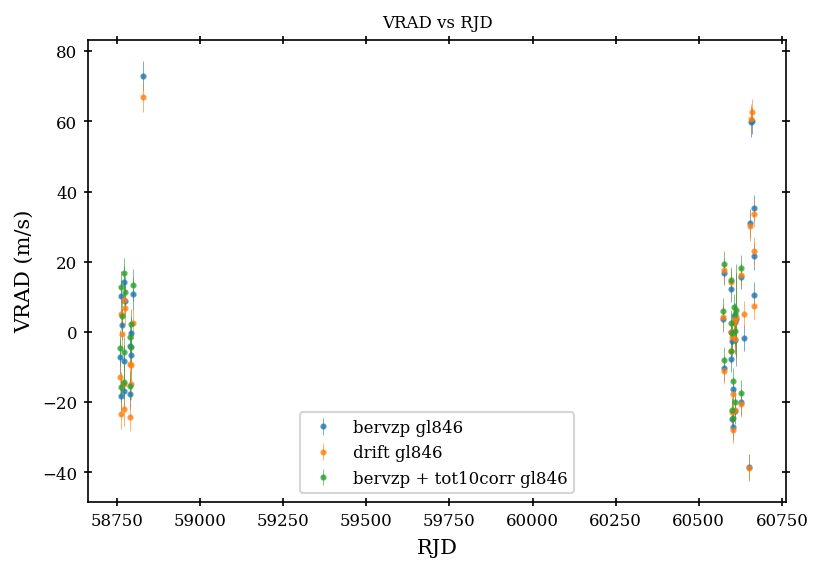

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.errorbar(spirou_lbl2.rjd, spirou_lbl2.vrad - np.median(spirou_lbl2.vrad), yerr=spirou_lbl2.svrad, 
            fmt='o', label='bervzp gl846', markersize=2, elinewidth=0.4, alpha=0.7)
ax.errorbar(spirou_lbl2_drift.rjd, spirou_lbl2_drift.vrad - np.median(spirou_lbl2_drift.vrad), yerr=spirou_lbl2_drift.svrad, 
            fmt='o', label='drift gl846', markersize=2, elinewidth=0.4, alpha=0.7)
ax.errorbar(spirou_lbl2_vtot.rjd, spirou_lbl2_vtot.vrad - np.median(spirou_lbl2_vtot.vrad), yerr=spirou_lbl2_vtot.svrad,
            fmt='o', label='bervzp + tot10corr gl846', markersize=2, elinewidth=0.4, alpha=0.7)
# ax.errorbar(spirou_lbl2_old.rjd, spirou_lbl2_old.vrad - np.median(spirou_lbl2_old.vrad), yerr=spirou_lbl2_old.svrad, 
#             fmt='o', label='old dataset gl846', markersize=2, elinewidth=0.4, alpha=0.7)
# ax.errorbar(spirou_lbl2_star.rjd, spirou_lbl2_star.vrad - np.median(spirou_lbl2_star.vrad), yerr=spirou_lbl2_star.svrad, 
#             fmt='o', label='new dataset star', markersize=2, elinewidth=0.4, alpha=0.7)

ax.set_xlabel('RJD')
ax.set_ylabel('VRAD (m/s)')
ax.set_title('VRAD vs RJD')
ax.legend()
plt.savefig('./plots/toi442/spirou_lbl2_old_vs_new.png', dpi=200, bbox_inches='tight')
plt.show()

In [8]:
def filter_df(df, var='vrad', method="iqr", sigmas=3, only_outliers=False):
    l = len(df)
    if not only_outliers:
        df = df[df['EXTSN035'] > (df['EXTSN035'].median() - 3*df['EXTSN035'].std())]
        df = df[df['svrad'] < (df.svrad.median() + 3*df.svrad.std())]
    if method == "iqr":
        quarts = np.percentile(df[var], [25, 75])
        iqr = stats.iqr(df[var])
        lower = quarts[0] - 1.5 * iqr
        upper = quarts[1] + 1.5 * iqr
    elif method == "sigma":
        mean = np.mean(df[var])
        std = np.std(df[var])
        lower = mean - sigmas * std
        upper = mean + sigmas * std
    else:
        raise ValueError("method must be 'iqr' or 'sigma'")
    df = df[(df[var] > lower) & (df[var] < upper)]
    l2 = len(df)
    print(f"Filtered {l-l2} points")
    return df

def center_df(df):
    df['vrad'] = df['vrad'] - np.median(df['vrad'])
    return df
# first filter all the datasets for outliers using 3-sigma clipping in svrad and iqr in vrad
spirou_lbl2_old = filter_df(spirou_lbl2_old)
spirou_lbl2 = filter_df(spirou_lbl2)
spirou_lbl2_drift = filter_df(spirou_lbl2_drift)
spirou_lbl2_vtot = filter_df(spirou_lbl2_vtot)
spirou_lbl2_star = filter_df(spirou_lbl2_star)
spirou_lbl2_star_vtot = filter_df(spirou_lbl2_star_vtot)

spirou_lbl2_old = center_df(spirou_lbl2_old)
spirou_lbl2 = center_df(spirou_lbl2)
spirou_lbl2_drift = center_df(spirou_lbl2_drift)
spirou_lbl2_vtot = center_df(spirou_lbl2_vtot)
spirou_lbl2_star = center_df(spirou_lbl2_star)
spirou_lbl2_star_vtot = center_df(spirou_lbl2_star_vtot)

Filtered 3 points
Filtered 4 points
Filtered 4 points
Filtered 1 points
Filtered 2 points
Filtered 1 points


In [9]:
print(len(spirou_lbl2_vtot))
print(len(bl))

29
40


In [10]:
# filter bl for outliers using iqr
bl = filter_df(bl, var='sbl', method="iqr", sigmas=3, only_outliers=True)
bl = filter_df(bl, var='bl', method="iqr", sigmas=3, only_outliers=True)
len(bl)

Filtered 1 points
Filtered 0 points


39

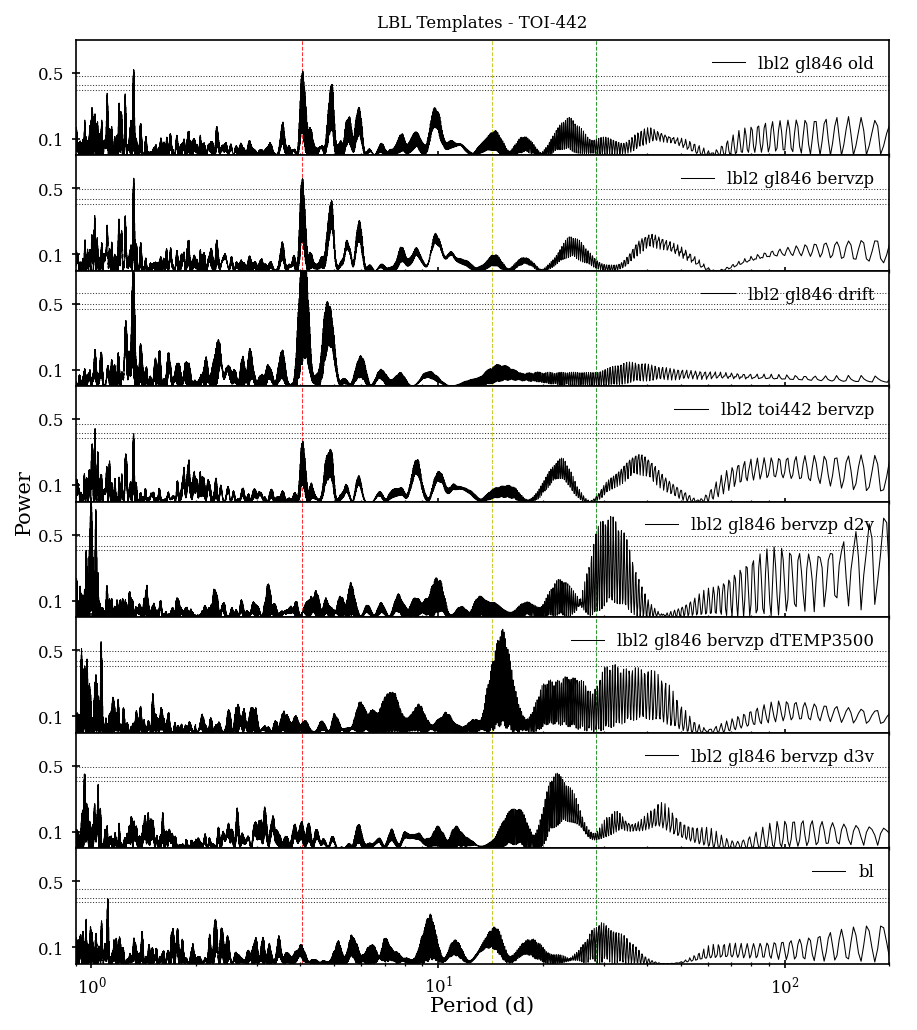

In [11]:
# check if the signal is present in any of the datasets
series = ['lbl2 gl846 old', 'lbl2 gl846 bervzp', 'lbl2 gl846 drift', 'lbl2 toi442 bervzp', 
          'lbl2 gl846 bervzp d2v', 'lbl2 gl846 bervzp dTEMP3500', 'lbl2 gl846 bervzp d3v', 'bl']

lg = [ls(spirou_lbl2_old.rjd, spirou_lbl2_old.vrad, spirou_lbl2_old.svrad),
      ls(spirou_lbl2.rjd, spirou_lbl2.vrad, spirou_lbl2.svrad),
      ls(spirou_lbl2_vtot.rjd, spirou_lbl2_vtot.vrad, spirou_lbl2_vtot.svrad),
      ls(spirou_lbl2_star.rjd, spirou_lbl2_star.vrad, spirou_lbl2_star.svrad),
      ls(spirou_lbl2.rjd, spirou_lbl2.d2v, spirou_lbl2.sd2v),
      ls(spirou_lbl2.rjd, spirou_lbl2['DTEMP4000'], spirou_lbl2['sDTEMP4000']),
      ls(spirou_lbl2.rjd, spirou_lbl2.d3v, spirou_lbl2.sd3v),
      ls(bl.rjd, bl.bl, bl.sbl)]

min_freq = 0.001
max_freq = 10
sppk = 5
probabilities = [0.1, 0.05, 0.01]

freq = {}
power = {}
fap = {}

for n, name in enumerate(series):
    freq[name], power[name] = lg[n].autopower(minimum_frequency=min_freq, maximum_frequency=max_freq, samples_per_peak=sppk)
    fap[name] = lg[n].false_alarm_level(probabilities)

# plot the periodograms
fig, ax = plt.subplots(len(series), 1, sharex=True, figsize=(7,len(series)), dpi=150)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0)

for i, name in enumerate(series):
    ax[i].axvline(x=period_tess.nominal_value, color='r', linestyle='--', linewidth=0.5, alpha=0.8)
    ax[i].axvline(x=14.3, color='y', linestyle='--', linewidth=0.5, alpha=0.8)
    ax[i].axvline(x=28.6, color='g', linestyle='--', linewidth=0.5, alpha=0.8)
    ax[i].plot(1/freq[series[i]], power[series[i]], color='k', linewidth=0.5, label=name)
    ax[i].set_ylabel(series[i])
    ax[i].set_ylim(0, 0.7)
    ax[i].set_xlim(0.9, 200)
    ax[i].set_xscale('log')
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].legend(frameon=False, markerscale=0, loc='upper right')
    ax[i].set_yticks([0.1, 0.5])
    ax[i].tick_params(which='both', top=False, right=False)
    ax[i].axhline(y=fap[name][0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                  , label=f'FAP {probabilities[0]*100}%', zorder=0)
    ax[i].axhline(y=fap[name][1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[1]*100}%', zorder=0)
    ax[i].axhline(y=fap[name][2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[2]*100}%', zorder=0)
    
bigax = fig.add_subplot(111, frameon=False)
bigax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
bigax.set_xlabel("Period (d)", labelpad=2)
bigax.set_ylabel("Power", labelpad=2)
bigax.set_title(f'LBL Templates - {star_name}')
plt.savefig(f'./plots/toi442/periodograms-by-reduction-template{star_name}.png', dpi=200, facecolor='w', bbox_inches='tight')

In [12]:
np.corrcoef(spirou_lbl2['DTEMP4000'], spirou_lbl2['d2v'])

array([[1.        , 0.03627711],
       [0.03627711, 1.        ]])

In [13]:
others.inst.unique()

array(['CARMENES-VIS', 'CARMENES-NIR', 'ESPRESSO', 'HIRES', 'iSHELL',
       'PFS'], dtype=object)

In [14]:
# d2v is "differential line width", an activity indicator. 
# d3v is then the column linked to the third derivative, it is supposed to be linked to the asymmetry of the line, 
# but as far as I know no one tries to use that product yet

# define the spirou data to use
spirou = spirou_lbl2_vtot.copy()
spirou.head()

,rjd,vrad,svrad,d2v,sd2v,d3v,sd3v,DTEMP3000,sDTEMP3000,DTEMP3500,...,svrad_2080nm,vrad_2167nm,svrad_2167nm,vrad_2257nm,svrad_2257nm,vrad_2351nm,svrad_2351nm,vrad_2449nm,svrad_2449nm,VTOT
0,58759.099352,-4.410334,5.037913,309562.041464,25255.588966,-5.837598e+07,4.892239e+07,29.298238,0.839857,52.054258,...,28.894310,-7364.085840,41.420328,-7506.764238,35.749514,-7418.815322,20.510148,-7241.022876,41.170075,-26.438940
1,58761.991347,12.944538,4.494779,273800.727946,22617.942096,-4.159441e+07,4.374633e+07,32.615551,0.742026,55.640179,...,26.153026,-7515.509243,36.818443,-7457.345072,29.108008,-7392.051428,17.467969,-7270.666153,34.819227,-25.862201
2,58762.982476,-15.459238,4.323448,207012.707368,21660.193935,-4.249725e+07,4.202392e+07,32.492424,0.742623,56.723298,...,26.887589,-7433.335901,37.760019,-7365.625268,29.542214,-7439.076734,16.409368,-8511.660150,32.801498,-25.614346
3,58766.039346,4.727727,4.491969,282112.711853,22630.699070,-4.056928e+07,4.392853e+07,32.898056,0.781701,57.748206,...,29.108265,-7467.498974,41.393723,-7403.704200,29.731731,-7418.663880,18.185806,-7317.350825,35.405389,-24.502738
4,58770.122279,16.922534,4.389523,295818.029418,22107.821862,-5.504935e+07,4.294125e+07,32.195326,0.751443,55.457072,...,26.912622,-7487.412646,38.496453,-7367.962732,30.246595,-7370.042065,18.288923,-7218.589573,38.554121,-22.936799


### Plot RVs

CARMENES-VIS median error: 2.58 m/s, RV std: 12.031 m/s
CARMENES-NIR median error: 13.21 m/s, RV std: 22.961 m/s
ESPRESSO median error: 0.95 m/s, RV std: 14.974 m/s
HIRES median error: 1.66 m/s, RV std: 12.416 m/s
iSHELL median error: 6.13 m/s, RV std: 13.111 m/s
PFS median error: 1.615 m/s, RV std: 15.131 m/s
Spirou median error: 4.044 m/s , RV std: 12.617 m/s


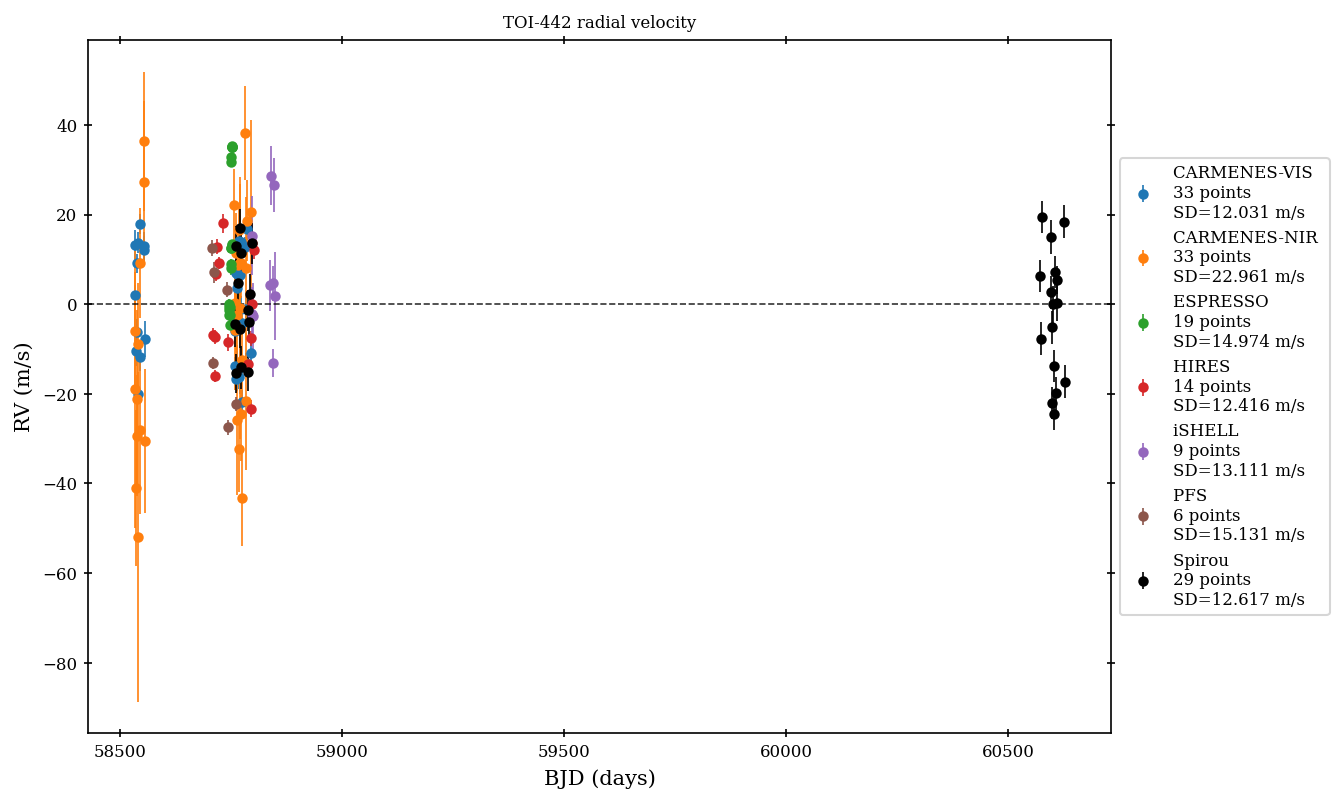

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))

for inst in others.inst.unique():
    mask = others.inst == inst
    ax.errorbar(others[mask].rjd, others[mask].vrad-others.vrad.median(), yerr=others[mask].svrad, fmt='o', 
                label=f'{inst} \n{len(others[mask])} points\nSD={np.round(np.std(others[mask].vrad),3)} m/s', markersize=4, elinewidth=0.8)
    print(f'{inst} median error: {np.round(np.median(others[mask].svrad),3)} m/s, RV std: {np.round(np.std(others[mask].vrad),3)} m/s')
ax.errorbar(spirou['rjd'], spirou['vrad'], yerr=spirou['svrad'], fmt='o', label=f'Spirou \n{len(spirou)} points\nSD={np.round(np.std(spirou.vrad),3)} m/s', markersize=4, elinewidth=0.8, color='k')
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.8)
print('Spirou median error:', np.round(np.median(spirou['svrad']),3), 'm/s', ', RV std:', np.round(np.std(spirou['vrad']),3), 'm/s')
# set legend outside the plot
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title(f'{star_name} radial velocity')
ax.set_xlabel('BJD (days)')
#ax.set_xlim(58740, 58755)
ax.set_ylabel('RV (m/s)')
# plt.savefig(f'./plots/toi442/all_rvs_{star_name}.png', dpi=200, facecolor='w', bbox_inches='tight')
plt.show()

In [16]:
print(spirou['svrad'].mean())
print(spirou['vrad'].std())

4.0368227674331205
12.840587243997113


In [17]:
for i in range(len(spirou)):
    print(f"{spirou.reset_index()['rjd'][i]:.2f} & {spirou.reset_index()['vrad'][i]:.2f} & {spirou.reset_index()['svrad'][i]:.2f} & {spirou.reset_index()['d2v'][i]:.2f} & {spirou.reset_index()['sd2v'][i]:.2f} \\\\")

58759.10 & -4.41 & 5.04 & 309562.04 & 25255.59 \\
58761.99 & 12.94 & 4.49 & 273800.73 & 22617.94 \\
58762.98 & -15.46 & 4.32 & 207012.71 & 21660.19 \\
58766.04 & 4.73 & 4.49 & 282112.71 & 22630.70 \\
58770.12 & 16.92 & 4.39 & 295818.03 & 22107.82 \\
58771.04 & -5.51 & 4.37 & 179102.34 & 21951.89 \\
58772.07 & -14.13 & 4.76 & 326749.60 & 23904.36 \\
58773.02 & 11.50 & 4.63 & 241551.51 & 23179.65 \\
58787.98 & -15.09 & 4.25 & 245202.05 & 21398.09 \\
58788.99 & -1.39 & 4.51 & 324731.64 & 22655.32 \\
58792.07 & -4.05 & 4.46 & 158896.09 & 22479.30 \\
58793.03 & 2.33 & 4.47 & 225339.14 & 22477.70 \\
58797.96 & 13.57 & 4.53 & 303967.66 & 22768.00 \\
60572.07 & 6.26 & 3.53 & 36962.12 & 17721.90 \\
60575.09 & -7.73 & 3.65 & 28585.36 & 18372.73 \\
60577.01 & 19.53 & 3.58 & 55832.14 & 18054.20 \\
60595.99 & 2.64 & 3.64 & -663.28 & 18318.41 \\
60597.12 & 14.98 & 3.75 & 54787.14 & 18932.64 \\
60598.13 & -5.15 & 3.62 & 34943.90 & 18232.80 \\
60598.98 & -22.03 & 3.58 & -36822.81 & 18026.53 \\
60600.0

In [18]:
# drop the first season of CARMENES-NIR
mask = (others.inst == 'CARMENES-NIR') & (others.rjd < 58600)
others = others[~mask]

In [19]:
others.inst.unique()

array(['CARMENES-VIS', 'CARMENES-NIR', 'ESPRESSO', 'HIRES', 'iSHELL',
       'PFS'], dtype=object)

In [20]:
# filter the data for CARMENES-NIR to outliers in svrad (theres is one point with 30 m/s error)
print(len(others[others.inst == 'CARMENES-NIR']))
mask = (others.inst == 'CARMENES-NIR') & (others.svrad > 25)
others = others[~mask]
print(len(others[others.inst == 'CARMENES-NIR']))

21
20


In [21]:
spirou['inst'] = 'SPIROU'

# lets remoove CARMENES-NIR from the list of instruments to use, it doesnt look good at all
rv_inst_names_used = ['SPIROU',
                      'CARMENES-VIS',
                      'ESPRESSO',
                      'HIRES',
                      'iSHELL',
                      'PFS']

nir_instruments = [spirou, 
                   others[others.inst == 'iSHELL']]
opt_instruments = [others[others.inst == 'CARMENES-VIS'],
                   others[others.inst == 'ESPRESSO'],
                   others[others.inst == 'HIRES'],
                   others[others.inst == 'PFS']]

# prepare the data for the model
xrv = np.concatenate((spirou['rjd'],
                    others[others.inst == 'iSHELL']['rjd'],
                    others[others.inst == 'CARMENES-VIS']['rjd'],
                    others[others.inst == 'ESPRESSO']['rjd'],
                    others[others.inst == 'HIRES']['rjd'],
                    others[others.inst == 'PFS']['rjd']))

yrv = np.concatenate((spirou['vrad'],
                    others[others.inst == 'iSHELL']['vrad'],
                    others[others.inst == 'CARMENES-VIS']['vrad'],
                    others[others.inst == 'ESPRESSO']['vrad'],
                    others[others.inst == 'HIRES']['vrad'],
                    others[others.inst == 'PFS']['vrad']))

yerrrv = np.concatenate((spirou['svrad'],
                    others[others.inst == 'iSHELL']['svrad'],
                    others[others.inst == 'CARMENES-VIS']['svrad'],
                    others[others.inst == 'ESPRESSO']['svrad'],
                    others[others.inst == 'HIRES']['svrad'],
                    others[others.inst == 'PFS']['svrad']))

rv_inst = np.concatenate((spirou['inst'], 
                    others[others.inst == 'iSHELL']['inst'],
                    others[others.inst == 'CARMENES-VIS']['inst'],
                    others[others.inst == 'ESPRESSO']['inst'],
                    others[others.inst == 'HIRES']['inst'],
                    others[others.inst == 'PFS']['inst']))

# map inst names to integers
rv_inst_id = np.array([rv_inst_names_used.index(inst) for inst in rv_inst])
rv_band_id = np.concatenate((np.concatenate([np.zeros(len(i)) for i in nir_instruments]),
                             np.concatenate([np.ones(len(i)) for i in opt_instruments]))) 
rv_inst_error = []
for i, inst in enumerate(rv_inst_names_used):
    rv_inst_error.append(np.median(yerrrv[rv_inst_id == i]))

inds = np.argsort(xrv)
xrv = np.ascontiguousarray(xrv[inds], dtype=np.float64) - 57000
yrv = np.ascontiguousarray(yrv[inds], dtype=np.float64)
yerrrv = np.ascontiguousarray(yerrrv[inds], dtype=np.float64)
rv_inst_id = np.ascontiguousarray(rv_inst_id[inds], dtype=int)
rv_band_id = np.ascontiguousarray(rv_band_id[inds], dtype=int) # 0 will be nir, 1 optical
rv_inst = np.ascontiguousarray(rv_inst[inds], dtype='str')

num_rv_inst = len(rv_inst_names_used)

In [22]:
for i, inst in enumerate(rv_inst_names_used):
    print(f'{inst}: median error {np.median(yerrrv[rv_inst_id == i]):.3f} m/s,  median rv {np.median(yrv[rv_inst_id == i]):.3f} m/s')

SPIROU: median error 4.044 m/s,  median rv 0.000 m/s
CARMENES-VIS: median error 2.580 m/s,  median rv -1.080 m/s
ESPRESSO: median error 0.950 m/s,  median rv 12.460 m/s
HIRES: median error 1.660 m/s,  median rv -3.405 m/s
iSHELL: median error 6.130 m/s,  median rv 4.170 m/s
PFS: median error 1.615 m/s,  median rv -4.920 m/s


In [23]:
# how different are the two seasons of spirou data?
print('SPIROU-1 mean RV:', np.mean(yrv[(rv_inst_id == 0) & (xrv < 2000)]))
print('SPIROU-2 mean RV:', np.mean(yrv[(rv_inst_id == 0) & (xrv > 2000)]))
# Compute the difference
difference = np.mean(yrv[(rv_inst_id == 0) & (xrv > 2000)]) - np.mean(yrv[(rv_inst_id == 0) & (xrv < 2000)])
print('Difference between SPIROU-2 and SPIROU-1 mean RVs:', difference, 'm/s')
# Compute the uncerainty of the means 
uncertainty_spi1 = np.std(yrv[(rv_inst_id == 0) & (xrv < 2000)]) / np.sqrt(len(yrv[(rv_inst_id == 0) & (xrv < 2000)]))
uncertainty_spi2 = np.std(yrv[(rv_inst_id == 0) & (xrv > 2000)]) / np.sqrt(len(yrv[(rv_inst_id == 0) & (xrv > 2000)]))
total_uncertainty = np.sqrt(uncertainty_spi1**2 + uncertainty_spi2**2)
print('Uncertainty in the difference:', total_uncertainty, 'm/s')

SPIROU-1 mean RV: 0.15005638385984918
SPIROU-2 mean RV: -2.2116275306166813
Difference between SPIROU-2 and SPIROU-1 mean RVs: -2.3616839144765303 m/s
Uncertainty in the difference: 4.578065949702254 m/s


### GLS analysis

In [24]:
# series = ['spirou rvs', 'spirou dlw', 'spirou1 rvs', 'spirou2 rvs', 'carmenes-nir', 'carmenes-vis', 'espresso', 'hires', 'ishell', 'all rvs', 'window function']
series = ['all rvs', 'spirou rvs', 'spirou dlw', 'spirou dtemp', 'spirou bl']
carmenes_nir_mask = rv_inst == 'CARMENES-NIR'
carmenes_vis_mask = rv_inst == 'CARMENES-VIS'
espresso_mask = rv_inst == 'ESPRESSO'
hires_mask = rv_inst == 'HIRES'
ishell_mask = rv_inst == 'iSHELL'

lg = [ls(xrv, yrv, yerrrv),
      ls(spirou.rjd, spirou.vrad, spirou.svrad),
      ls(spirou.rjd, spirou.d2v, spirou.sd2v),
      ls(spirou.rjd, spirou['DTEMP4000'], spirou['sDTEMP4000']),
      ls(bl.rjd, bl['bl'], bl['sbl']),
      ls(xrv[carmenes_nir_mask], yrv[carmenes_nir_mask], yerrrv[carmenes_nir_mask]),
      ls(xrv[carmenes_vis_mask], yrv[carmenes_vis_mask], yerrrv[carmenes_vis_mask]),
      ls(xrv[espresso_mask], yrv[espresso_mask], yerrrv[espresso_mask]),
      ls(xrv[hires_mask], yrv[hires_mask], yerrrv[hires_mask]),
      ls(xrv[ishell_mask], yrv[ishell_mask], yerrrv[ishell_mask])]

min_freq = 0.001
max_freq = 10
sppk = 5
probabilities = [0.1, 0.05, 0.01]

freq = {}
power = {}
fap = {}

for n, name in enumerate(series):
    freq[name], power[name] = lg[n].autopower(minimum_frequency=min_freq, maximum_frequency=max_freq, samples_per_peak=sppk)
    if name != 'window function':
        fap[name] = lg[n].false_alarm_level(probabilities)

In [25]:
def compute_one_day_aliases(P):
    f = 1 / P
    f_minus = abs(f - 1)
    f_plus = abs(f + 1)
    P_minus = 1 / f_minus
    P_plus = 1 / f_plus
    return P_minus, P_plus

def compute_aliases(P, n_list=[1, 2]):
    f = 1 / P
    aliases = []
    for n in n_list:
        for sign in [+1, -1]:
            f_alias = abs(f + sign * n)
            P_alias = 1 / f_alias
            aliases.append((n, sign, P_alias))
    return aliases

In [26]:
compute_aliases(period_tess.nominal_value, n_list=[1, 2])

[(1, 1, 0.8020600325001591),
 (1, -1, 1.3276500466835788),
 (2, 1, 0.44507953011276186),
 (2, -1, 0.5703821536984076)]

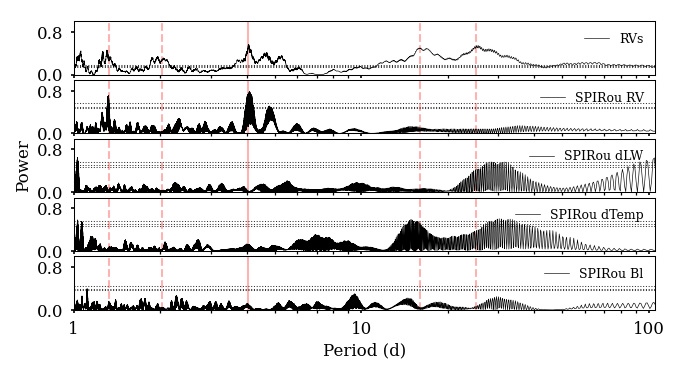

In [27]:
fig, ax = plt.subplots(len(series), 1, sharex=True, figsize=(5,2.5), dpi=150)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
names_ = ['RVs', 'SPIRou RV', 'SPIRou dLW', 'SPIRou dTemp', 'SPIRou Bl']
aliases = compute_one_day_aliases(period_tess.nominal_value)

for i, name in enumerate(series):
    ax[i].axvline(x=period_tess.nominal_value, color='r', linestyle='-', linewidth=1, alpha=0.3)
    ax[i].axvline(x=aliases[0], color='r', linestyle='--', linewidth=1, alpha=0.3)
    ax[i].axvline(x=16, color='r', linestyle='--', linewidth=1, alpha=0.3)
    ax[i].axvline(x=25, color='r', linestyle='--', linewidth=1, alpha=0.3)
    # ax[i].axvline(x=16, color='r', linestyle='--', linewidth=1, alpha=0.3)
    ax[i].axvline(x=period_tess.nominal_value/2, color='r', linestyle='--', linewidth=1, alpha=0.3)
    # ax[i].axvline(x=33.0, color='y', linestyle='--', linewidth=0.5, alpha=0.8)
    ax[i].plot(1/freq[series[i]], power[series[i]], color='k', linewidth=0.3, label=names_[i])
    ax[i].set_ylabel(series[i])
    ax[i].set_ylim(0, 1)
    ax[i].set_xlim(1, 105)
    ax[i].set_xscale('log')
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].legend(frameon=False, markerscale=0, loc='upper right', fontsize=6, edgecolor='k', fancybox=False)
    ax[i].set_yticks([0.0, 0.8], labels=['0.0', '0.8'], size=8)
    ax[i].set_xticks([1, 10, 100], labels=['1', '10', '100'], size=8)
    ax[i].tick_params(which='both', top=False, right=False, direction='out', length=1.5)
    ax[i].axhline(y=fap[name][0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                , label=f'FAP {probabilities[0]*100}%', zorder=0)
    ax[i].axhline(y=fap[name][1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                , label=f'FAP {probabilities[1]*100}%', zorder=0)
    ax[i].axhline(y=fap[name][2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                , label=f'FAP {probabilities[2]*100}%', zorder=0)
    for axis in ['top','bottom','left','right']:
        ax[i].spines[axis].set_linewidth(0.5)
bigax = fig.add_subplot(111, frameon=False)
bigax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
bigax.set_xlabel("Period (d)", labelpad=2, size=8)
bigax.set_ylabel("Power", labelpad=2, size=8)
plt.savefig(f'./plots/toi442/rvgls_442.png', dpi=400, facecolor='w', bbox_inches='tight')

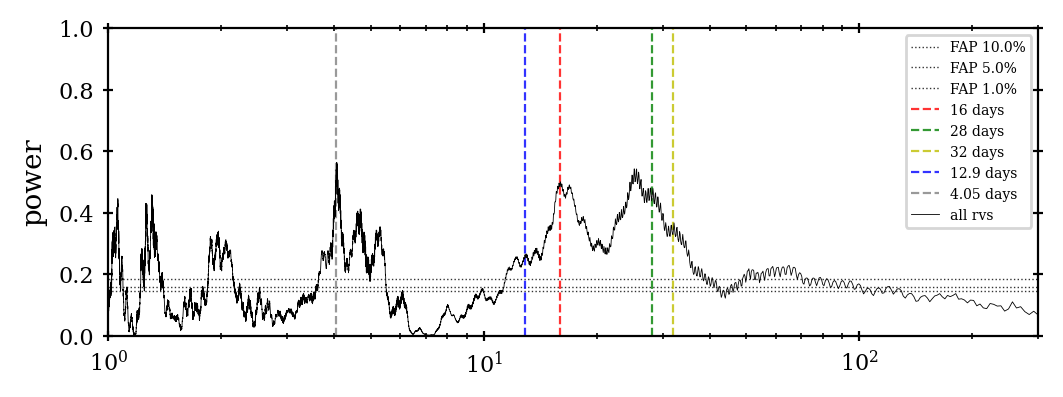

In [28]:
fig, ax = plt.subplots(figsize=(6, 2), dpi=200)

lg_all = ls(xrv, yrv, yerrrv)
fr_all, pw_all = lg_all.autopower(minimum_frequency=1/300, maximum_frequency=max_freq, samples_per_peak=sppk)
fp = lg_all.false_alarm_level(probabilities)
ax.axhline(y=fp[0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                  , label=f'FAP {probabilities[0]*100}%', zorder=0)
ax.axhline(y=fp[1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[1]*100}%', zorder=0)
ax.axhline(y=fp[2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[2]*100}%', zorder=0)
ax.axvline(16, color='r', linestyle='--', linewidth=0.8, alpha=0.8, label='16 days')
ax.axvline(28, color='g', linestyle='--', linewidth=0.8, alpha=0.8, label='28 days')
ax.axvline(32, color='y', linestyle='--', linewidth=0.8, alpha=0.8, label='32 days')
ax.axvline(12.9, color='b', linestyle='--', linewidth=0.8, alpha=0.8, label='12.9 days')
ax.axvline(4.05, color='gray', linestyle='--', linewidth=0.8, alpha=0.8, label='4.05 days')
ax.plot(1/fr_all, pw_all, color='k', linewidth=0.3, label='all rvs')
ax.set_ylabel('power')
ax.set_xlim(1, 300)
ax.set_xscale('log')
ax.set_ylim(0, 1)
ax.legend(fontsize=5)
plt.savefig(f'./plots/toi442/rv_ALL_gls.png', dpi=200, facecolor='w', bbox_inches='tight')

## Read LCs

In [29]:
#exofop: https://exofop.ipac.caltech.edu/tess/target.php?id=70899085

# tpf_search = lk.search_targetpixelfile('TIC 70899085')
# tpf_search

In [30]:
# search = lk.search_lightcurve('TIC 70899085')
# search

In [31]:
# read the saved 2-min lightcurve
read_file = pd.read_csv('./data/toi442/lc.csv')
lc = lk.LightCurve(time=read_file['time'], flux=read_file['flux'], flux_err=read_file['flux_err'])

<Axes: xlabel='Time [JD]', ylabel='Flux'>

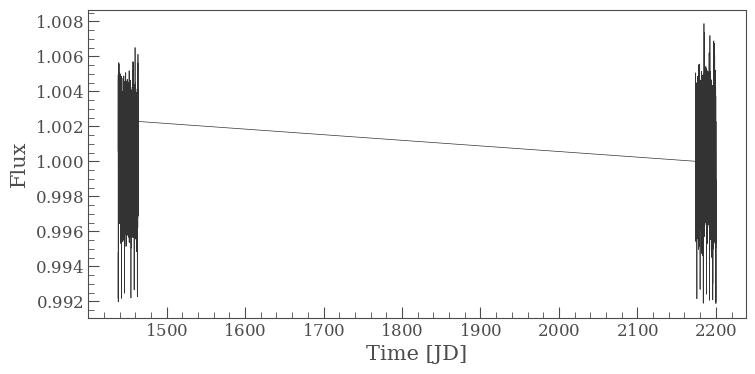

In [32]:
lc.plot()

(1437.0, 1464.0)

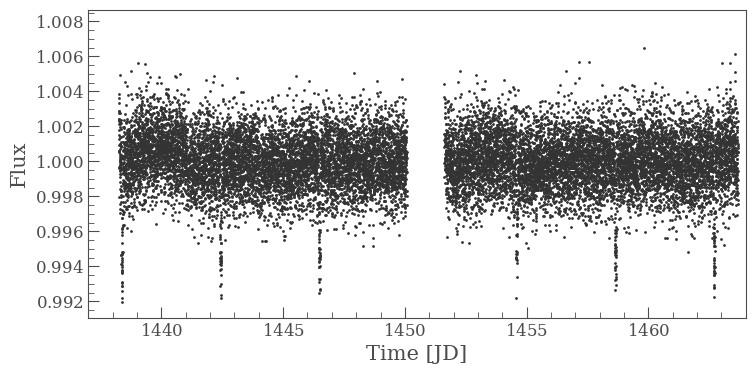

In [33]:
# sector 5
lc.scatter()
plt.xlim(1437, 1464)

(2172.0, 2201.0)

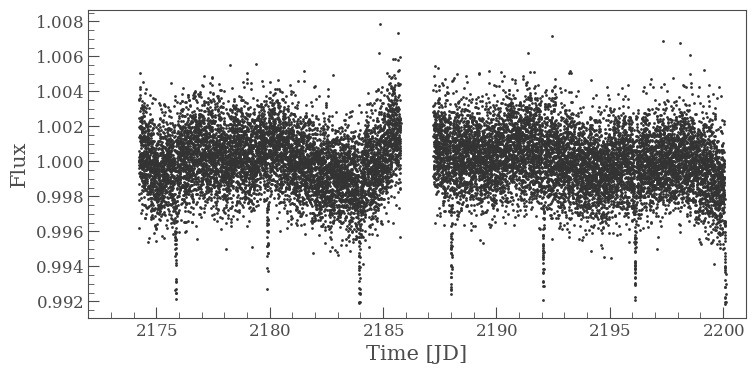

In [34]:
# sector 32
lc.scatter()
plt.xlim(2172, 2201)

In [35]:
# lets remove that last transit
lc = lc.truncate(after=2199.50)

<Axes: xlabel='Phase [JD]', ylabel='Flux'>

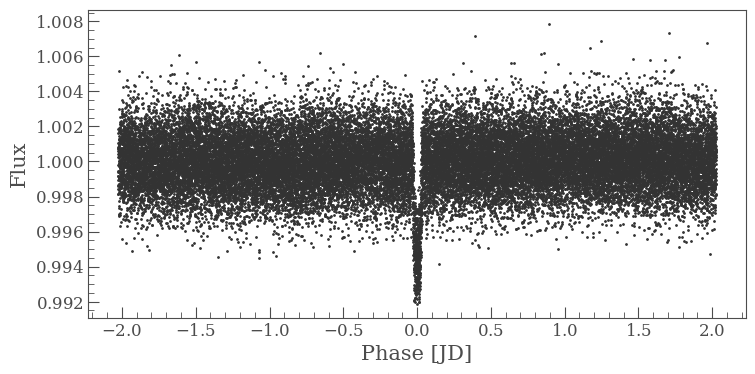

In [36]:
lc.fold(period_tess.nominal_value, epoch_time=epoch_tess.nominal_value-2457000).scatter()

### LC to use

In [37]:
# read the binned lightcurve
read_file_binned = pd.read_csv('./data/toi442/lc_5min.csv')
lc_binned = lk.LightCurve(time=read_file_binned['time'], flux=read_file_binned['flux'], flux_err=read_file_binned['flux_err'])

time = np.asarray(lc.time.value)
flux = np.asarray(lc.flux.value)
flux_err = np.asarray(lc.flux_err.value)
inds = np.argsort(time)
time = np.ascontiguousarray(time[inds], dtype=np.float64)
flux = np.ascontiguousarray(flux[inds], dtype=np.float64)
flux_err = np.ascontiguousarray(flux_err[inds], dtype=np.float64)

time_5min = lc_binned.time.value
flux_5min = lc_binned.flux.value
flux_err_5min = lc_binned.flux_err.value
inds5 = np.argsort(time_5min)
time_5min = np.ascontiguousarray(time_5min[inds5], dtype=np.float64)
flux_5min = np.ascontiguousarray(flux_5min[inds5], dtype=np.float64)
flux_err_5min = np.ascontiguousarray(flux_err_5min[inds5], dtype=np.float64)



# get the exptimes
texp_2 = 2.0 / 60.0 / 24.0
texp_5 = 5.0 / 60.0 / 24.0

ref_time = np.min(time)

In [38]:
# we're gonna split the lightcurves in 2 parts, sector 5, and sector 32
# lets creat another variable to store the sector of each point, then the sector ID will be 0, 1
# same as we did with different instruments in RVs
# sector 5 -> time < 1800
# sector 32 -> 1800 < time 

# 2min cadence
sector_id = np.zeros(len(time), dtype=int)
sector_id[time < 1800] = 0
sector_id[time > 1800] = 1

# 5min cadence
sector_id_5min = np.zeros(len(time_5min), dtype=int)
sector_id_5min[time_5min < 1800] = 0
sector_id_5min[time_5min > 1800] = 1

sector_id_names = ['Sector_5', 'Sector_32']

### TESS TLS

In [39]:
from transitleastsquares import transit_mask
import pickle

In [40]:
# load the results from the TLS
with open('./results/tls/tls_complete_442.pkl', 'rb') as f:
    results = pickle.load(f)

In [41]:
print(results['period'], results['T0'], results['duration'], results['depth'], results['SDE'])
tls_p = results['period']
tls_t0 = results['T0']
tls_duration = results['duration']
tls_depth = results['depth']

4.05207220998396 1438.3808123817212 0.003499671379386358 0.9948902960237005 64.36412438677563


In [42]:
tls_duration*25

0.08749178448465895

### Transit masks

(1437.0, 1464.0)

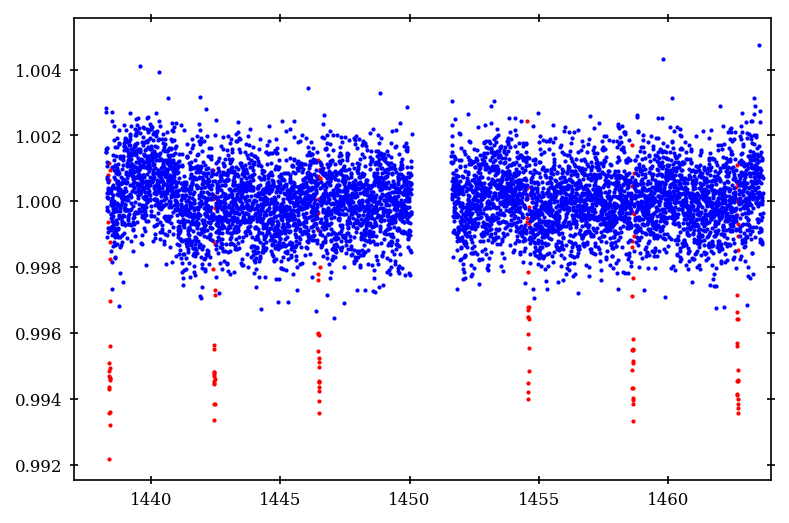

In [43]:
# 1 day around the transits for faster modeling
intransit_5min = transit_mask(time_5min, tls_p, 1, tls_t0)
intransit = transit_mask(time, tls_p, 1, tls_t0)
# just the transits 5min
intransit_5min_small = transit_mask(time_5min, tls_p, tls_duration*25, tls_t0) # only the transits
intransit_small = transit_mask(time, tls_p, tls_duration*25, tls_t0)
# just the transits 120s
in_transit = transit_mask(time, tls_p, tls_duration*25, tls_t0)

plt.scatter(time_5min[intransit_5min_small], flux_5min[intransit_5min_small], s=1, color='red')  # in-transit points in red
plt.scatter(time_5min[~intransit_5min_small], flux_5min[~intransit_5min_small], s=1, color='blue')  # other points in blue
plt.xlim(1437, 1464)
#plt.xlim(1462, 1463)
#plt.xlim(2150, 1447)

Text(0, 0.5, 'Relative flux')

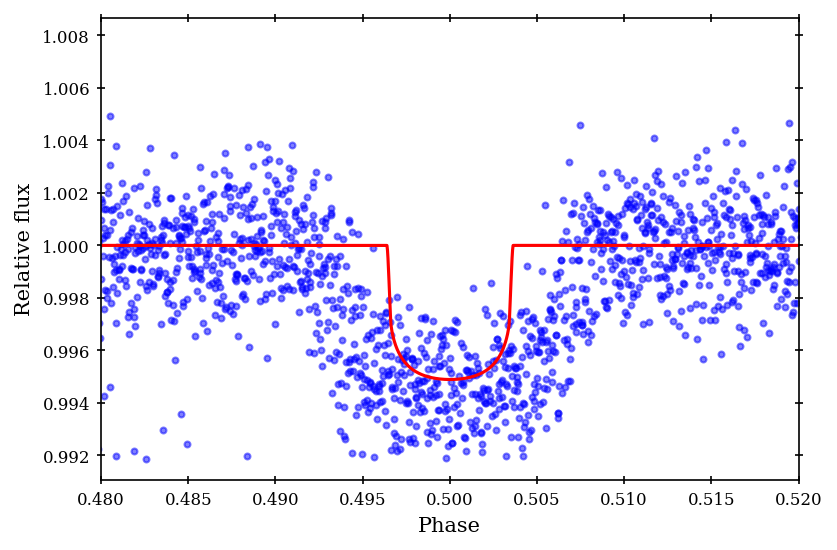

In [44]:
# results phase folded
plt.figure()
plt.scatter(results['folded_phase'], results['folded_y'], color='blue', s=8, alpha=0.5, zorder=2)
plt.plot(results['model_folded_phase'], results['model_folded_model'], color='red')
plt.xlim(0.48, 0.52)
plt.xlabel('Phase')
plt.ylabel('Relative flux')

In [45]:
tls_duration*20

0.06999342758772716

In [46]:
duration_tess/24

0.06502136604977916

## Modelo Global

### Model variables

In [47]:
# load detrended lc
read_detrended5 = pd.read_csv('./data/toi442/detrended_lc_5min.csv')
lc_detrended5 = lk.LightCurve(time=read_detrended5['time'], flux=read_detrended5['flux'], flux_err=read_detrended5['flux_err'])

read_detrended = pd.read_csv('./data/toi442/detrended_lc_2min.csv')
lc_detrended = lk.LightCurve(time=read_detrended['time'], flux=read_detrended['flux'], flux_err=read_detrended['flux_err'])

def get_xy(time_exp, version='short'):
    # parametros
    # ----------
    # time_exp: '120', '300' (int)
    # devuelve
    # ----------
    # x, y, yerr, texp (en días y ppt)
    if version == 'all':
        if time_exp == 120:
            t_ = time
            flux_ = flux
            flux_err_ = flux_err
            texp_ = texp_2
            id_ = sector_id
        elif time_exp == 300:
            t_ = time_5min
            flux_ = flux_5min
            flux_err_ = flux_err_5min
            texp_ = texp_5
            id_ = sector_id_5min
    elif version == '1day':
        if time_exp == 120:
            t_ = time[intransit]
            flux_ = flux[intransit]
            flux_err_ = flux_err[intransit]
            texp_ = texp_2
            id_ = sector_id[intransit]
        elif time_exp == 300:
            t_ = time_5min[intransit_5min]
            flux_ = flux_5min[intransit_5min]
            flux_err_ = flux_err_5min[intransit_5min]
            texp_ = texp_5
            id_ = sector_id_5min[intransit_5min]
    elif version == 'no-transits':
        if time_exp == 120:
            t_ = time[~intransit_small]
            flux_ = flux[~intransit_small]
            flux_err_ = flux_err[~intransit_small]
            texp_ = texp_2
            id_ = sector_id[~intransit_small]
        elif time_exp == 300:
            t_ = time_5min[~intransit_5min_small]
            flux_ = flux_5min[~intransit_5min_small]
            flux_err_ = flux_err_5min[~intransit_5min_small]
            texp_ = texp_5
            id_ = sector_id_5min[~intransit_5min_small]
    elif version == 'detrended-all':
        if time_exp == 300:
            t_ = lc_detrended5.time.value
            flux_ = lc_detrended5.flux.value
            flux_err_ = lc_detrended5.flux_err.value
            texp_ = texp_5
            id_ = sector_id_5min
            return t_, flux_, flux_err_, texp_, id_
        elif time_exp == 120:
            t_ = lc_detrended.time.value
            flux_ = lc_detrended.flux.value
            flux_err_ = lc_detrended.flux_err.value
            texp_ = texp_2
            id_ = sector_id
            return t_, flux_, flux_err_, texp_, id_
    elif version == 'detrended-1day':
        if time_exp == 300:
            t_ = lc_detrended5.time.value[intransit_5min]
            flux_ = lc_detrended5.flux.value[intransit_5min]
            flux_err_ = lc_detrended5.flux_err.value[intransit_5min]
            texp_ = texp_5
            id_ = sector_id_5min[intransit_5min]
            return t_, flux_, flux_err_, texp_, id_
        elif time_exp == 120:
            t_ = lc_detrended.time.value[intransit]
            flux_ = lc_detrended.flux.value[intransit]
            flux_err_ = lc_detrended.flux_err.value[intransit]
            texp_ = texp_2
            id_ = sector_id[intransit]
            return t_, flux_, flux_err_, texp_, id_

    x_ = np.ascontiguousarray(t_ - ref_time, dtype=np.float64)
    y_ = np.ascontiguousarray(1e3 * (flux_ - 1.0), dtype=np.float64) # Here we convert flux to ppt
    yerr_ = np.ascontiguousarray(1e3 * flux_err_, dtype=np.float64) 
    return x_, y_, yerr_, texp_, id_

def get_xy_rv():
    # just substract the reference time
    x_ = xrv - ref_time
    y_ = yrv
    yerr_ = yerrrv
    rv_inst_id_ = rv_inst_id
    return x_, y_, yerr_, rv_inst_id_

In [48]:
# lc para modelo
x, y, yerr, texp, id = get_xy(120, 'detrended-1day')
print(len(x))

# rvs para modelo
x_rv, y_rv, yerr_rv, rv_inst_id = get_xy_rv()

8363


(1440.0, 1460.0)

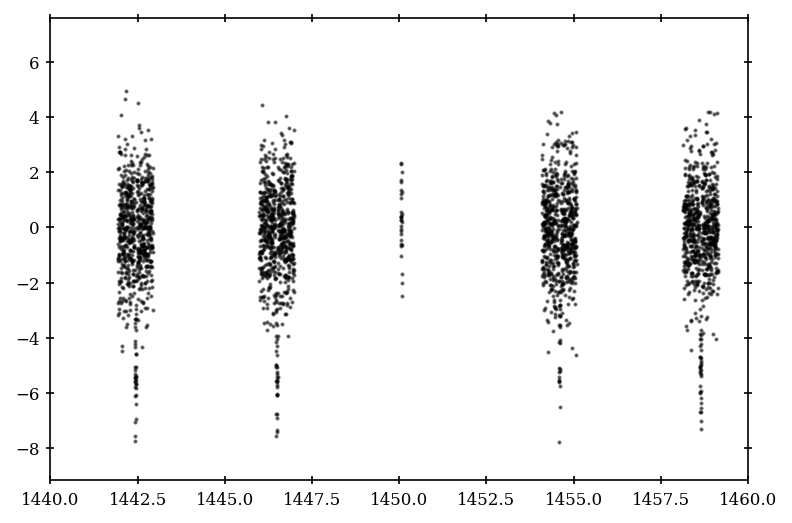

In [49]:
plt.plot(x+ref_time,y,'o', markersize=1, alpha=0.5, color='k', label='2-min detrended')
plt.xlim(1440,1460)

In [50]:
K_est = xo.estimate_semi_amplitude(tls_p, x_rv, y_rv, yerr_rv, t0s=tls_t0-ref_time)
print(K_est, "m/s")

[18.47703658] m/s


In [51]:
# range of sector 5: [1437, 1464]
# range of sector 32: [2172, 2201]
# t0 from best model:  0.131553
# P from best model: 4.052032

transit_times = xo.orbits.ttv.compute_expected_transit_times(x.min(), x.max(), 4.052032, 0.131553)
transit_times = np.array(transit_times, dtype=np.float64)
t_times = transit_times[((transit_times > 1437.0 - ref_time) & (transit_times < 1448.0 - ref_time)) |
                        ((transit_times > 1452.0 - ref_time) & (transit_times < 1464.0 - ref_time)) |
                        ((transit_times > 2172.0 - ref_time) & (transit_times < 2199.5 - ref_time))]

# save the indexes
indexes = np.where((transit_times > 1437.0 - ref_time) & (transit_times < 1448.0 - ref_time))[1]
indexes2 = np.where((transit_times > 1452.0 - ref_time) & (transit_times < 1464.0 - ref_time))[1]
indexes3 = np.where((transit_times > 2172.0 - ref_time) & (transit_times < 2199.5 - ref_time))[1]
indexes = np.concatenate((indexes, indexes2, indexes3))  

### Tess TTVs model

In [52]:
# phase_lc = np.linspace(-0.3, 0.3, 500)

# with pm.Model() as ttv_model:
#     q1 = pm.Uniform("q1", lower=0.0, upper=1.0)
#     q2 = pm.Uniform("q2", lower=0.0, upper=1.0)
#     sqrtq1 = pt.sqrt(q1)
#     twoq2 = 2 * q2
#     u_star = pm.Deterministic("u_star", pt.stack([sqrtq1 * twoq2, sqrtq1 * (1 - twoq2)], axis=0))
#     star = xo.LimbDarkLightCurve(u_star)

#     rstar = pm.TruncatedNormal("rstar", mu=par.iloc[0].R, sigma=par.iloc[0].M_err, lower=0.0, upper=1.0)    
#     log_ror = pm.Normal("log_ror", mu=0.5*np.log((1-np.nanmean(results['transit_depths']))), sigma=np.nanmean(results['transit_depths_uncertainties'])/(1-np.nanmean(results['transit_depths'])))
#     ror = pm.Deterministic("ror", pt.exp(log_ror))
#     r_pl = pm.Deterministic("r_pl", ror * rstar)
    
#     b = pm.Uniform("b", lower=0.0, upper=1.0)      
#     transits = [pm.Normal('transits', mu=t_times, sigma=1.0, shape=len(t_times))]

#     orbit = xo.orbits.TTVOrbit(b=b, transit_times=transits, transit_inds=[indexes])
#     pm.Deterministic("t0", orbit.t0)
#     pm.Deterministic("period", orbit.period)        
#     # pm.Deterministic("ttvs", orbit.ttvs)

#     # Function to compute the light curve model
#     def lc_model(mean_, star, r_pl_, texp_, t_):
#         return pt.sum(1e3*star.get_light_curve(orbit=orbit, r=r_pl_, t=t_, texp=texp_), axis=-1) + mean_

#     lc_mean = pm.Normal("lc_mean", mu=0.0, sigma=1.0) # mean flux
#     logs = pm.Normal("logs", mu=np.log(np.std(y)), sigma=1)

#     err_lc = pt.sqrt(yerr**2 + pt.exp(2 * logs)) # jitter + error
#     lc_mod = lc_model(lc_mean, star, r_pl, texp, x)
#     pm.Normal("lc_obs", mu=lc_mod, sigma=err_lc, observed=y) 
#     pm.Deterministic("lc", lc_mod)

#     ttv_map_soln = pm.find_MAP()    

In [53]:
# fig, ax = plt.subplots(2, 1, figsize=(8, 4), dpi=150)
# ax[0].plot(x, y, ".k", ms=4, label="data")
# ax[1].plot(x, y, ".k", ms=4, label="data")
# ax[0].plot(x, ttv_map_soln["lc"], lw=1, label="planet b")
# ax[1].plot(x, ttv_map_soln["lc"], lw=1, label="planet b")
# ax[0].set_xlim(x.min()-0.5, 26)
# ax[1].set_xlim(x.max()-23, x.max())
# ax[0].set_ylabel("relative flux")
# ax[0].set_xlabel("time [days]")

In [54]:
# with ttv_model:
#     ttv_trace = pm.sample(
#         draws=1000,
#         tune=1000,
#         initvals=ttv_map_soln,
#         chains=2,
#         target_accept=0.95,
#         init="adapt_full",
#     )

In [55]:
# az.summary(ttv_trace, var_names=["lc_mean", "log_ror", "b", "transits"])

In [56]:
# # trace to save
# az.to_netcdf(ttv_trace, f'./saves/toi442/trace_ttv.save')

# # save to trace
# ttv_trace = az.from_netcdf(f'./saves/toi442/trace_ttv.save')

In [57]:
# ttv_flat_samps = ttv_trace.posterior.stack(sample=("chain", "draw"))

In [58]:
# fig, ax = plt.subplots(2, 1, figsize=(5, 4), dpi=150)
# fig.subplots_adjust(hspace=0.35)
# q = np.percentile(ttv_flat_samps["transits"], [16, 50, 84], axis=-1)
# oc = t_times - q[1]
# ax[0].scatter(t_times+ref_time, oc*24*60, s=10, color='k')
# ax[0].errorbar(t_times+ref_time, oc*24*60, yerr=[(q[1]-q[0])*24*60, (q[2]-q[1])*24*60], fmt='o', markersize=0, elinewidth=1.2, color='k', alpha=0.5, label='O-C')
# ax[1].scatter(t_times+ref_time, oc*24*60, s=10, color='k')
# ax[1].errorbar(t_times+ref_time, oc*24*60, yerr=[(q[1]-q[0])*24*60, (q[2]-q[1])*24*60], fmt='o', markersize=0, elinewidth=1.2, color='k', alpha=0.5, label='O-C')
# ax[0].axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.8)
# ax[1].axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.8)
# ax[0].annotate('Sector 5', xy=(0.05, 0.88), xycoords='axes fraction', fontsize=10)
# ax[1].annotate('Sector 32', xy=(0.05, 0.88), xycoords='axes fraction', fontsize=10)
# ax[0].set_xlim(x.min()-0.5+ref_time, 26+ref_time)
# ax[1].set_xlim(x.max()-23+ref_time, x.max()+ref_time)
# ax[0].set_ylabel("O-C (min)", labelpad=2)
# ax[1].set_ylabel("O-C (min)", labelpad=2)
# ax[0].set_xlabel("Transit time (TBJD)")
# ax[1].set_xlabel("Transit time (TBJD)")
# for i in range(2):
#     ax[i].tick_params(direction='inout', length=1.5, labelsize=9, pad=1.6)
#     # ax[i].set_xticks([-2.0,-1.5,-1.0,-0.5,0,0.5,1.0,1.5,2.0])
#     # ax[i].set_xticklabels(['-2','','1','','0','','1','','2'])
#     for axis in ['top','bottom','left','right']:
#         ax[i].spines[axis].set_linewidth(0.5)
# plt.savefig('./plots/toi442/ttvs.png', dpi=200, facecolor='w', bbox_inches='tight')

In [59]:
# shapiro-wilk test of normality
# from scipy import stats

# shapiro_test = stats.shapiro(oc)
# print(shapiro_test)
# print(shapiro_test.statistic)
# print(shapiro_test.pvalue)

In [60]:
import rebound

In [61]:
# a1/a2
# 0.04056/0.10163

# 16.07/4.052032/4 # old period
15.93/4.052032/4

0.9828402144899152

In [62]:
sim = rebound.Simulation()
sim.add(m=0.54)
sim.add(m=28.4*u.M_earth.to(u.M_sun), a=0.04055, e=0.029, omega=1.6)
sim.add(m=(13.4)*u.M_earth.to(u.M_sun), a=0.1015, e=0.31, omega=-0.6)
# sim.add(m=(13.4)*u.M_earth.to(u.M_sun), a=0.1005, e=0.04, omega=-0.6)
# sim.add(m=(13.4+-3.19)*u.M_earth.to(u.M_sun), a=0.1005, e=0.05, omega=-0.6)

sim.move_to_com()

In [63]:
N=1000
transittimes = np.zeros(N)
p = sim.particles
i = 0
while i<N:
    y_old = p[1].y - p[0].y  # (Thanks to David Martin for pointing out a bug in this line!)
    t_old = sim.t
    sim.integrate(sim.t+0.001) # check for transits every 0.5 time units. Note that 0.5 is shorter than one orbit
    t_new = sim.t
    if y_old*(p[1].y-p[0].y)<0. and p[1].x-p[0].x>0.:   # sign changed (y_old*y<0), planet in front of star (x>0)
        while t_new-t_old>1e-9:   # bisect until prec of 1e-5 reached
            if y_old*(p[1].y-p[0].y)<0.:
                t_new = sim.t
            else:
                t_old = sim.t
            sim.integrate( (t_new+t_old)/2.)
        transittimes[i] = sim.t
        i += 1
        sim.integrate(sim.t+0.001) 

In [64]:
A = np.vstack([np.ones(N), range(N)]).T
c, m = np.linalg.lstsq(A, transittimes, rcond=-1)[0]

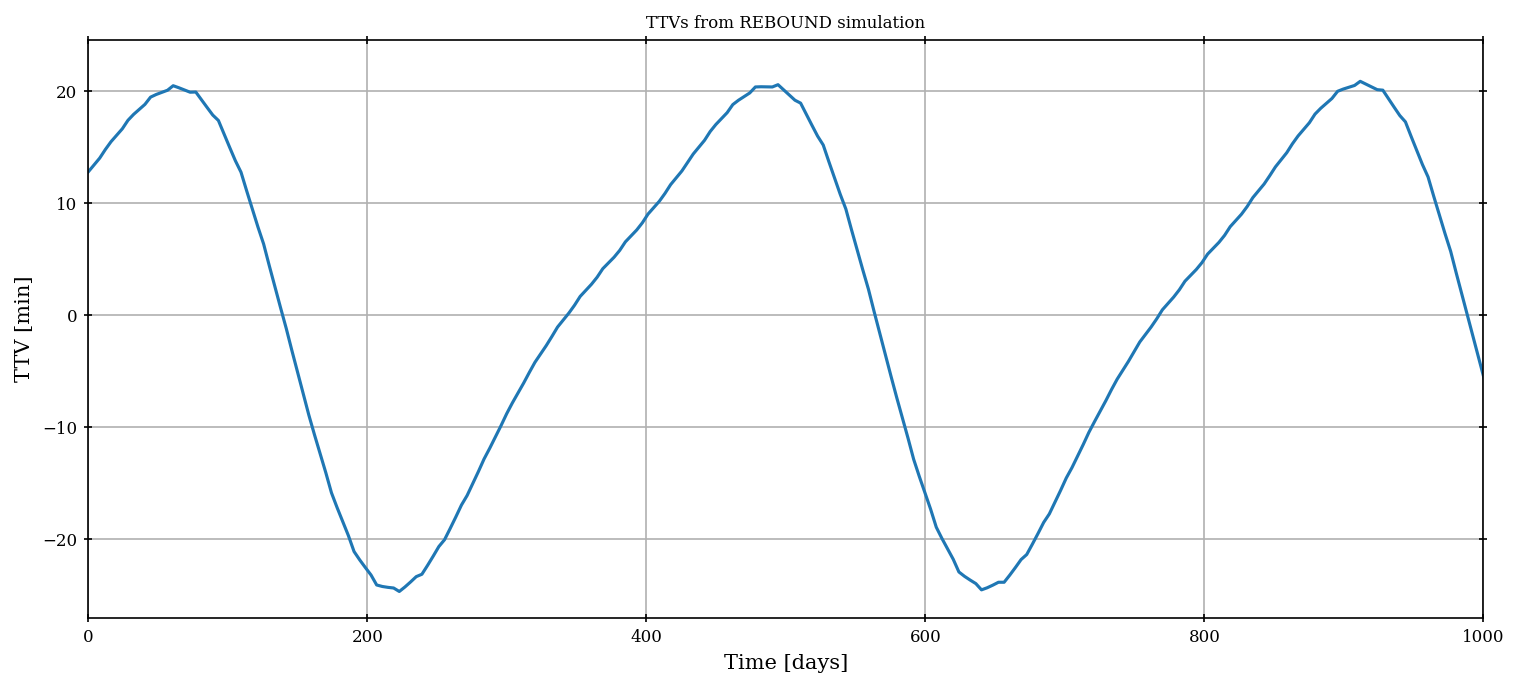

In [65]:
fig, ax = plt.subplots(figsize=(12,5))
ax.set_xlim([0,N])
ax.set_xlabel("Time [days]")
ax.set_ylabel("TTV [min]")
# ax.scatter(np.array(range(N))*4.052032, (transittimes-m*np.array(range(N))-c)*(60.*24.*365./2./np.pi))
ax.plot(np.array(range(N))*4.052032, (transittimes-m*np.array(range(N))-c)*(60.*24.*365./2./np.pi))
ax.set_title("TTVs from REBOUND simulation")
ax.grid()
plt.savefig('./plots/toi442/ttv_rebound_new.png', dpi=200, facecolor='w', bbox_inches='tight')

In [66]:
glss = ls(np.array(range(N))*4.052032, (transittimes-m*np.array(range(N))-c)*(60.*24.*365./2./np.pi))
freq_ttv, power_ttv = glss.autopower(minimum_frequency=1/1000, maximum_frequency=1/10, samples_per_peak=5)
period_ttv = 1/freq_ttv[np.argmax(power_ttv)]
print(f'Period of the TTVs: {period_ttv:.3f} days')

Period of the TTVs: 428.449 days


In [67]:
# is that the super-period?
# ~180*4.05 = 729 days
# If the period ratio P2=P1is within a few percent of the ratio j=k, with jand kbeing integers, then the expected TTV period is
# Agol & Fabrycky
# super_period = 1/abs(j/P2 - k/P1) with j, k integers

# resonant period
# res_p = np.pi * (2./delta) ** (1/4)
# delta = 

# pp1 = ((0.04055*u.au.to(u.m)) ** 3 * ( 4 * np.pi**2 ) / (constants.G * (0.54*u.M_sun.to(u.kg) + 29.47*u.M_earth.to(u.kg)))) ** (1/2)/3600.0/24.0
# pp2 = ((0.1016*u.au.to(u.m)) ** 3 * ( 4 * np.pi**2 ) / (constants.G * (0.54*u.M_sun.to(u.kg) + 18.0*u.M_earth.to(u.kg)))) ** (1/2)/3600.0/24.0
super_period = 1./np.abs(1/4.052032 - 4/16.072877)
print('Super period:', super_period, "days")
print(2*super_period)

Super period: 481.5329419824195 days
963.065883964839


In [68]:
# depth expected?
ratio1 = 2*u.Rearth.to(u.Rsun) / 0.53
ratio2 = 4*u.Rearth.to(u.Rsun) / 0.53
dep1 = ratio1**2*1e3
dep2 = ratio2**2*1e3
print(f'Expected depth for 1 Mearth: {dep1:.6f} ppm')
print(f'Expected depth for 10 Mearth: {dep2:.6f} ppm')

Expected depth for 1 Mearth: 1.196870 ppm
Expected depth for 10 Mearth: 4.787479 ppm


In [69]:
# time of transit reference 1169.34
# for i in range(70):
#     print(1169.34+i*16.07)

t_anomaly = np.pi/2-(-1.0)
e_anomaly = 2*np.arctan(np.sqrt((1+0.33)/(1-0.33))*np.tan(t_anomaly/2))
time_since_peri = 16.07/(2*np.pi)*(e_anomaly - 0.33*np.sin(e_anomaly))
print(f'Time since pericenter passage: {time_since_peri:.2f} days')
print(f'Reference transit time: {1163.9+time_since_peri}')
for i in range(70):
    print(f'Transit time {i}: {1163.9+time_since_peri+i*16.07:.2f} days')

Time since pericenter passage: 6.65 days
Reference transit time: 1170.547845935529
Transit time 0: 1170.55 days
Transit time 1: 1186.62 days
Transit time 2: 1202.69 days
Transit time 3: 1218.76 days
Transit time 4: 1234.83 days
Transit time 5: 1250.90 days
Transit time 6: 1266.97 days
Transit time 7: 1283.04 days
Transit time 8: 1299.11 days
Transit time 9: 1315.18 days
Transit time 10: 1331.25 days
Transit time 11: 1347.32 days
Transit time 12: 1363.39 days
Transit time 13: 1379.46 days
Transit time 14: 1395.53 days
Transit time 15: 1411.60 days
Transit time 16: 1427.67 days
Transit time 17: 1443.74 days
Transit time 18: 1459.81 days
Transit time 19: 1475.88 days
Transit time 20: 1491.95 days
Transit time 21: 1508.02 days
Transit time 22: 1524.09 days
Transit time 23: 1540.16 days
Transit time 24: 1556.23 days
Transit time 25: 1572.30 days
Transit time 26: 1588.37 days
Transit time 27: 1604.44 days
Transit time 28: 1620.51 days
Transit time 29: 1636.58 days
Transit time 30: 1652.65 da

### Model version

In [114]:
# versiones
# 0: per instrument offset en RVs
# 1: per instrument offset + quadratic drift en RVs
# 2: noise GP in RVs
# 3: noise GP in RVs + drift

version_names = ['offset', 'drift', 'SHO-GP', 'SHO-GP+drift', 'QP-GP', 'QP-GP+drift']

n_planets = 2

version = 2

# v0 and v1 2 planets with P2 uniform between 14 and 18 (0 to 20 was difficult to sample)
# v2,3,4,5 with two planets and P2 uniform between 14 and 18 doesnt converge

# there's no additional signals after fitting the stellar activity
# the 12 days signal is not present with the new data

### Model build

In [ ]:
# time vectors for plotting
from pytensor.printing import pydotprint

phase_lc = np.linspace(-0.3, 0.3, 500)
t_rv = np.linspace(x_rv.min() - 5, x_rv.max() + 5, 6000)
# Compute a reference time that will be used to normalize the trends model
x_ref = 0.5 * (x_rv.min() + x_rv.max())

def build_model(version=0, map=True, circular=False):
    with pm.Model() as model:
        # Limb darkening pero sin initvals (exoplanets los usa por default [0.0,0.5])
        # because pymc error "cannot convert models with non-default initial_values" when using compute_likelihood() on posterior
        q1 = pm.Uniform("q1", lower=0.0, upper=1.0)
        q2 = pm.Uniform("q2", lower=0.0, upper=1.0)
        sqrtq1 = pt.sqrt(q1)
        twoq2 = 2 * q2
        u_star = pm.Deterministic("u_star", pt.stack([sqrtq1 * twoq2, sqrtq1 * (1 - twoq2)], axis=0))
        star = xo.LimbDarkLightCurve(u_star)

        # Stellar parameters from TESS
        mstar = pm.TruncatedNormal("mstar", mu=par.iloc[0].M, sigma=par.iloc[0].M_err, lower=0.0, upper=1.0)
        rstar = pm.TruncatedNormal("rstar", mu=par.iloc[0].R, sigma=par.iloc[0].M_err, lower=0.0, upper=1.0)

        # Orbital parameters for the planet
        log_t0 = pm.Normal("log_t0", mu=np.log(tls_t0-ref_time), sigma=0.1)
        t0 = pm.Deterministic("t0", pt.exp(log_t0))

        log_P = pm.Normal("log_P", mu=np.log(tls_p), sigma=results['period_uncertainty']/tls_p)
        P = pm.Deterministic("P", pt.exp(log_P))
        
        # K = pm.Uniform("K", lower=0, upper=50.0)
        log_K = pm.Normal("log_K", mu=np.log(K_est), sigma=0.1)
        K = pm.Deterministic("K", pt.exp(log_K))

        # Fit in terms of ror
        log_ror = pm.Normal("log_ror", mu=0.5*np.log((1-np.nanmean(results['transit_depths']))), sigma=np.nanmean(results['transit_depths_uncertainties'])/(1-np.nanmean(results['transit_depths'])))
        ror = pm.Deterministic("ror", pt.exp(log_ror))
        r_pl = pm.Deterministic("r_pl", ror * rstar)
        b = pm.Uniform("b", lower=0.0, upper=1.0) 
        
        ecc = pm.Uniform("e", lower=0.0, upper=0.5)
        omega = pm.Uniform("w", lower=-np.pi, upper=np.pi)

        # derived parameters
        m_pl = pm.Deterministic('m_pl', K*pt.sqrt(1-ecc**2)*(P*u.day.to(u.second)*(mstar*u.M_sun.to(u.kg))**2/(2*np.pi*constants.G))**(1/3)*u.kg.to(u.M_earth))
        density_pl = pm.Deterministic('density_pl', m_pl*u.M_earth.to(u.g)/(4/3*np.pi*(r_pl*u.R_sun.to(u.cm))**3))    
        a = pm.Deterministic('a', ((P*u.day.to(u.second))**2*constants.G*(mstar*u.M_sun.to(u.kg)+m_pl*u.M_earth.to(u.kg))/(4*np.pi**2))**(1/3)*u.m.to(u.au))
        teq = pm.Deterministic('teq', par.iloc[0].teff*(rstar*u.R_sun.to(u.au)/a)**(1/2)*(1/4)**(1/4))
        
        orbit = xo.orbits.KeplerianOrbit(
            r_star=rstar,
            m_star=mstar,
            period=P,
            t0=t0,
            b=b,
            ecc=ecc,
            omega=omega,
            )
        
        if n_planets == 2:
            if not circular:
                ecc_2 = pm.Uniform("e_2", lower=0.0, upper=0.7)
                omega_2 = pm.Uniform("w_2", lower=0, upper=2*np.pi) 

            log_P_2 = pm.Uniform("log_P_2", lower=np.log(14.0), upper=np.log(18.0))
            P_2 = pm.Deterministic("P_2", pt.exp(log_P_2))

            lambda_2 = pm.Uniform("lambda_2", lower=0.0, upper=2*np.pi)  # This is mean anomaly at ref epoch, lambda_0 = omega + M_0 
            n = 2.0 * np.pi / P_2  # mean angular motion
            # tperi_2 = pm.Deterministic("tperi_2", pt.mod(x_rv.mean() - (lambda_2 - omega_2) / n, P_2))
            tperi_2 = pm.Deterministic("tperi_2", x_rv.mean() - (lambda_2 - omega_2) / n)    # We recover t_periastron
            
            K_2 = pm.HalfNormal("K_2", sigma=5.0) 

            if not circular:
                orbit_2 = xo.orbits.KeplerianOrbit(
                    r_star=rstar,
                    m_star=mstar,
                    period=P_2,
                    t_periastron=tperi_2,
                    ecc=ecc_2,
                    omega=omega_2,
                    )
            else:
                orbit_2 = xo.orbits.KeplerianOrbit(
                    r_star=rstar,
                    m_star=mstar,
                    period=P_2,
                    t_periastron=tperi_2,
                    )
                
            m_pl_2 = pm.Deterministic('m_pl_2', K_2*(P_2*u.day.to(u.second)*(mstar*u.M_sun.to(u.kg))**2/(2*np.pi*constants.G))**(1/3)*u.kg.to(u.M_earth))  
            a_2 = pm.Deterministic('a_2', ((P_2*u.day.to(u.second))**2*constants.G*(mstar*u.M_sun.to(u.kg)+m_pl_2*u.M_earth.to(u.kg))/(4*np.pi**2))**(1/3)*u.m.to(u.au))
            teq_2 = pm.Deterministic('teq_2', par.iloc[0].teff*(rstar*u.R_sun.to(u.au)/a_2)**(1/2)*(1/4)**(1/4))

        # Function to compute the light curve model
        def lc_model(mean_, star, r_pl, texp_, t_):
            return pt.sum(1e3*star.get_light_curve(orbit=orbit, r=r_pl, t=t_, texp=texp_), axis=-1) + mean_

        # Function to compute the radial velocity model
        def get_rv_model(x, name=""):
            vrad = orbit.get_radial_velocity(x, K=K)
            pm.Deterministic("vrad" + name, vrad)
            if n_planets == 2:
                vrad_2 = orbit_2.get_radial_velocity(x, K=K_2)
                pm.Deterministic("vrad_2" + name, vrad_2)
            if version == 1 or version == 3 or version == 5:
                # Define the background model
                # Use only the first two columns (we removed the constant term)
                A = np.vander(x - x_ref, 3)
                bkg = pm.Deterministic("bkg" + name, pt.dot(A, trend))
                if n_planets == 2:
                    return pm.Deterministic("rv_model" + name, vrad + vrad_2 + bkg)
                else:
                    return pm.Deterministic("rv_model" + name, vrad + bkg)
            elif version == 0 or version == 2 or version == 4:
                if n_planets == 2:
                    return pm.Deterministic("rv_model" + name, vrad + vrad_2)
                else:
                    return pm.Deterministic("rv_model" + name, vrad)
        
        lc_mean = pm.Normal("lc_mean", mu=0.0, sigma=1.0) # mean flux
        logs = pm.Normal("logs", mu=np.log(np.std(y)), sigma=1) # tess jitter
    
        err_lc = pt.sqrt(yerr**2 + pt.exp(2 * logs)) # jitter + error

        # compute the model light curve
        lc_mod = lc_model(lc_mean, star, r_pl, texp, x)
        lc_phase_mod = lc_model(lc_mean, star, r_pl, texp, t0 + phase_lc)

        # the likelihood for the light curves
        pm.Normal("lc_obs", mu=lc_mod, sigma=err_lc, observed=y) 
        pm.Deterministic("lc", lc_mod)
        pm.Deterministic("lc_phase", lc_phase_mod)

        # Per instrument offset and jitter
        means = pm.Normal("means", mu=0, sigma=5.0, shape=num_rv_inst)
        log_sigmas = pm.Normal("log_sigmas", mu=np.log(np.array(rv_inst_error)), sigma=1, shape=num_rv_inst)

        if version in [1,3,5]:
            # RV quadratic trend, remove the constant term because we're using a per instrument mean
            trend = pm.Normal("trend", mu=0, sigma=np.array([0.01, 0.1, 1.0]), shape=3)

        # rv model versions
        if version in [0, 1]:
            
            mean = pt.zeros(len(x_rv))
            sigma = pt.zeros(len(x_rv))
            for i in range(len(rv_inst_names_used)):
                mean += means[i] * (rv_inst_id == i)
                sigma += (yerr_rv**2 + pt.exp(2 * log_sigmas[i])) * (rv_inst_id == i)
                # sigma += (yerr_rv**2 + sigmas[i]**2) * (rv_inst_id == i)

            pm.Deterministic("mean", mean)
            pm.Deterministic("sigma", sigma)

            # rv model
            rv_mod = get_rv_model(x_rv) + mean
            get_rv_model(t_rv, "_pred")

            # the likelihood for the rvs
            err = pt.sqrt(sigma)
            pm.Normal("obs", mu=rv_mod, sigma=err, observed=y_rv)

        elif version in [2,3,4,5]:
            
            # Compute the RV offset and jitter for each data point depending on its instrument
            mean = pt.zeros(len(x_rv))
            diag = pt.zeros(len(x_rv))
            for i in range(num_rv_inst):
                mean += means[i] * (rv_inst_id == i)
                diag += (yerr_rv**2 + pt.exp(2 * log_sigmas[i])) * (rv_inst_id == i)
            pm.Deterministic("mean", mean)
            pm.Deterministic("diag", diag)

            rv_mod = get_rv_model(x_rv) + mean
            get_rv_model(t_rv, "_pred")

            if version in [2,3]:
                # Noise model parameters
                # sigma_gp = pm.Uniform("sigma_gp", lower=0.0, upper=40)
                # rho_gp = pm.Uniform("rho_gp", lower=0.0, upper=1000.0)
                # sigma_gp = pm.HalfNormal("sigma_gp", sigma=np.std(y_rv))
                # log_rho_gp = pm.Normal("log_rho_gp", mu=np.log(34), sigma=2.0)
                # kernelrv = terms.SHOTerm(
                #     sigma=sigma_gp, 
                #     rho=pt.exp(log_rho_gp), 
                #     Q=1.0 / 3)
                
                sigma_gp = pm.HalfNormal("sigma_gp", sigma=[np.std(y_rv[rv_band_id == 0]), np.std(y_rv[rv_band_id == 1])], shape=2) # nIR and optical
                # gp_period = pm.Uniform("gp_period", lower=22.0, upper=45.0)
                gp_period = pm.Normal("gp_period", mu=28.6, sigma=1.25)
                tau = pm.Uniform("tau", lower=10.0, upper=1000.0, shape=2)
                
                kernelrv_nir = terms.SHOTerm(
                    rho=gp_period,
                    tau=tau[0],
                    sigma=sigma_gp[0],)
                
                kernelrv_opt = terms.SHOTerm(
                    rho=gp_period,
                    tau=tau[1],
                    sigma=sigma_gp[1],)
                
            if version in [4,5]:   
                #Rotation term model parameters
                # sigma_gp_rv = pm.Uniform("sigma_gp_rv", lower=0.0, upper=40)
                # gp_period = pm.Uniform("gp_period", lower=22.0, upper=52.0)
                # Q0 = pm.Uniform("Q0", lower=0.0, upper=1000.0)
                # dQ = pm.Uniform("dQ", lower=0.0, upper=1000.0)
                sigma_gp = pm.HalfNormal("sigma_gp", sigma=[np.std(y_rv[rv_band_id == 0]), np.std(y_rv[rv_band_id == 1])], shape=2) # nIR and optical
                # gp_period = pm.Uniform("gp_period", lower=22.0, upper=45.0)
                gp_period = pm.Normal("gp_period", mu=28.6, sigma=1.25)
                log_Q0 = pm.Uniform("log_Q0", lower=1, upper=8, shape=2)
                log_dQ = pm.Uniform("log_dQ", lower=-3, upper=10, shape=2)
                f = pm.Uniform("f", lower=0.1, upper=1.0, shape=2)

                kernelrv_nir = terms.RotationTerm(
                    sigma=sigma_gp[0],
                    period=gp_period,
                    Q0=pt.exp(log_Q0[0]),
                    dQ=pt.exp(log_dQ[0]),
                    f=f[0])
                
                kernelrv_opt = terms.RotationTerm(
                    sigma=sigma_gp[1],
                    period=gp_period,
                    Q0=pt.exp(log_Q0[1]),
                    dQ=pt.exp(log_dQ[1]),
                    f=f[1])
            
            # bl_jitter = pm.Normal("bl_jitter", mu=np.log(np.mean(bl.sbl.values)), sigma=1)
            # diag_act = (bl.sbl.values**2 + pt.exp(2 * bl_jitter))
            # gp_nir_act = GaussianProcess(kernel_nir_act, t=bl.rjd, mean=0.0, diag=diag_act)
            gp_rv_nir = GaussianProcess(kernelrv_nir, t=x_rv[(rv_band_id == 0)], mean=rv_mod[(rv_band_id == 0)], diag=diag[(rv_band_id == 0)])
            gp_rv_opt = GaussianProcess(kernelrv_opt, t=x_rv[(rv_band_id == 1)], mean=rv_mod[(rv_band_id == 1)], diag=diag[(rv_band_id == 1)])

            # gp_nir_act.marginal("obs_act_nir", observed=bl.bl.values)
            gp_rv_nir.marginal("obs_nir", observed=y_rv[(rv_band_id == 0)])
            gp_rv_opt.marginal("obs_opt", observed=y_rv[(rv_band_id == 1)])

            # predictions for marginal implementation
            # pm.Deterministic("gp_nir_act_pred", gp_nir_act.predict(bl.bl.values, include_mean=False))
            pm.Deterministic("gp_rv_pred_nir", gp_rv_nir.predict(y_rv[(rv_band_id == 0)], include_mean=False))
            pm.Deterministic("gp_rv_pred_opt", gp_rv_opt.predict(y_rv[(rv_band_id == 1)], include_mean=False))
            # pm.Deterministic("gp_rv_pred_plot_nir", gp_rv_nir.predict(y_rv[(rv_band_id == 0)], t_rv, include_mean=False))
            # pm.Deterministic("gp_rv_pred_plot_opt", gp_rv_opt.predict(y_rv[(rv_band_id == 1)], t_rv, include_mean=False))
        else:
            raise ValueError('Version not found')
        
        if map:
            # Find MAP
            if version in [1, 3, 5]:
                map_soln = pm.find_MAP(vars=[trend])
                map_soln = pm.find_MAP(start=map_soln, vars=[log_sigmas])
            else:
                map_soln = pm.find_MAP(vars=[log_sigmas])
            map_soln = pm.find_MAP(start=map_soln, vars=[means])
            map_soln = pm.find_MAP(start=map_soln, vars=[log_t0])
            map_soln = pm.find_MAP(start=map_soln, vars=[logs])
            map_soln = pm.find_MAP(start=map_soln, vars=[log_P])
            map_soln = pm.find_MAP(start=map_soln, vars=[log_K])
            map_soln = pm.find_MAP(start=map_soln, vars=[b])
            map_soln = pm.find_MAP(start=map_soln, vars=[log_ror])
            if version in [2, 3, 4, 5]:
                map_soln = pm.find_MAP(start=map_soln, vars=[gp_period])
                map_soln = pm.find_MAP(start=map_soln, vars=[sigma_gp])
                if version in [2, 3]:
                    map_soln = pm.find_MAP(start=map_soln, vars=[tau])
                if version in [4, 5]:
                    map_soln = pm.find_MAP(start=map_soln, vars=[log_Q0])
                    map_soln = pm.find_MAP(start=map_soln, vars=[log_dQ])
                    map_soln = pm.find_MAP(start=map_soln, vars=[f])
            map_soln = pm.find_MAP(start=map_soln, vars=[ecc])
            map_soln = pm.find_MAP(start=map_soln, vars=[omega])
            map_soln = pm.find_MAP(start=map_soln, vars=[q1, q2])
            map_soln = pm.find_MAP(start=map_soln, vars=[mstar, rstar])
            if n_planets == 2:
                map_soln = pm.find_MAP(start=map_soln, vars=[log_P_2])
                # map_soln = pm.find_MAP(start=map_soln, vars=[P_2])
                # map_soln = pm.find_MAP(start=map_soln, vars=[tperi_2])
                map_soln = pm.find_MAP(start=map_soln, vars=[K_2])
                if not circular:
                    map_soln = pm.find_MAP(start=map_soln, vars=[ecc_2]) # ecc_2
                    map_soln = pm.find_MAP(start=map_soln, vars=[omega_2]) # omega_2
                    map_soln = pm.find_MAP(start=map_soln, vars=[lambda_2])

        else:
            map_soln = None
        
        # pydotprint(omega_2, outfile="P_2.png", format="png")
        # debugprint(gp_period)
    return model, map_soln

circular = False
model, map_soln = build_model(version=version, map=False, circular=circular)

/home/juanserrano/anaconda3/envs/exoplanet3/lib/python3.11/site-packages/pytensor/tensor/random/op.py:83: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
/home/juanserrano/anaconda3/envs/exoplanet3/lib/python3.11/site-packages/pytensor/tensor/random/op.py:93: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(
/home/juanserrano/anaconda3/envs/exoplanet3/lib/python3.11/site-packages/pytensor/tensor/random/op.py:83: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
/home/juanserrano/anaconda3/envs/exoplanet3/lib/python3.11/site-packages/pytensor/tensor/random/op.py:93: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(


Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

Output()

### Posterior Sampling

In [ ]:
# with model:
#     trace = pm.sample(
#         draws=3000,
#         tune=3000,
#         initvals=map_soln,
#         chains=4,
#         target_accept=0.95,
#         init="adapt_full",
#     )

Initializing NUTS using adapt_full...
/home/juanserrano/anaconda3/envs/exoplanet3/lib/python3.11/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [q1, q2, mstar, rstar, log_t0, log_P, log_K, log_ror, b, e, w, e_2, w_2, log_P_2, lambda_2, K_2, lc_mean, logs, means, log_sigmas, sigma_gp, gp_period, tau]


Output()

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 4594 seconds.
There were 1 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [ ]:
# pm.compute_log_likelihood(trace, model=model)

Output()

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

In [137]:
# # # trace to save
# if circular:
#     az.to_netcdf(trace, f'./saves/toi442/trace.global{star_name}_v{version}_{version_names[version]}_{n_planets}planets_circular.save')
# else:
#     az.to_netcdf(trace, f'./saves/toi442/trace.global{star_name}_v{version}_{version_names[version]}_{n_planets}planets.save')

# # save to trace
if circular:
    trace = az.from_netcdf(f'./saves/toi442/trace.global{star_name}_v{version}_{version_names[version]}_{n_planets}planets_circular.save')
else:
    trace = az.from_netcdf(f'./saves/toi442/trace.global{star_name}_v{version}_{version_names[version]}_{n_planets}planets.save')

In [ ]:
# trace.isel(chain=[0, 1, 2], groups="posterior_groups", inplace=True)

<xarray.Dataset> Size: 2GB
Dimensions:               (chain: 3, draw: 3000, log_K_dim_0: 1,
                           means_dim_0: 6, log_sigmas_dim_0: 6,
                           sigma_gp_dim_0: 2, tau_dim_0: 2, u_star_dim_0: 2,
                           K_dim_0: 1, m_pl_dim_0: 1, density_pl_dim_0: 1,
                           a_dim_0: 1, teq_dim_0: 1, lc_dim_0: 8363,
                           lc_phase_dim_0: 500, mean_dim_0: 110,
                           diag_dim_0: 110, vrad_dim_0: 110, vrad_2_dim_0: 110,
                           rv_model_dim_0: 110, vrad_pred_dim_0: 6000,
                           vrad_2_pred_dim_0: 6000, rv_model_pred_dim_0: 6000,
                           gp_rv_pred_nir_dim_0: 38, gp_rv_pred_opt_dim_0: 72)
Coordinates: (12/25)
  * chain                 (chain) int64 24B 0 1 2
  * draw                  (draw) int64 24kB 0 1 2 3 4 ... 2996 2997 2998 2999
  * log_K_dim_0           (log_K_dim_0) int64 8B 0
  * means_dim_0           (means_dim_0) int64 48B 0 1 2 3 4 5
  * log_sigmas_dim_0      (log_sigmas_dim_0) int64 48B 0 1 2 3 4 5
  * sigma_gp_dim_0        (sigma_gp_dim_0) int64 16B 0 1
    ...                    ...
  * rv_model_dim_0        (rv_model_dim_0) int64 880B 0 1 2 3 ... 107 108 109
  * vrad_pred_dim_0       (vrad_pred_dim_0) int64 48kB 0 1 2 ... 5997 5998 5999
  * vrad_2_pred_dim_0     (vrad_2_pred_dim_0) int64 48kB 0 1 2 ... 5998 5999
  * rv_model_pred_dim_0   (rv_model_pred_dim_0) int64 48kB 0 1 2 ... 5998 5999
  * gp_rv_pred_nir_dim_0  (gp_rv_pred_nir_dim_0) int64 304B 0 1 2 3 ... 35 36 37
  * gp_rv_pred_opt_dim_0  (gp_rv_pred_opt_dim_0) int64 576B 0 1 2 3 ... 69 70 71
Data variables: (12/50)
    log_t0                (chain, draw) float64 72kB -2.03 -2.028 ... -2.026
    log_P                 (chain, draw) float64 72kB 1.399 1.399 ... 1.399 1.399
    log_K                 (chain, draw, log_K_dim_0) float64 72kB 2.832 ... 2...
    log_ror               (chain, draw) float64 72kB -2.648 -2.644 ... -2.647
    lc_mean               (chain, draw) float64 72kB -0.009306 ... -0.03538
    logs                  (chain, draw) float64 72kB -2.128 -2.152 ... -2.17
    ...                    ...
    rv_model              (chain, draw, rv_model_dim_0) float64 8MB 12.57 ......
    vrad_pred             (chain, draw, vrad_pred_dim_0) float64 432MB -4.949...
    vrad_2_pred           (chain, draw, vrad_2_pred_dim_0) float64 432MB 4.93...
    rv_model_pred         (chain, draw, rv_model_pred_dim_0) float64 432MB -0...
    gp_rv_pred_nir        (chain, draw, gp_rv_pred_nir_dim_0) float64 3MB 3.1...
    gp_rv_pred_opt        (chain, draw, gp_rv_pred_opt_dim_0) float64 5MB 0.8...
Attributes:
    created_at:                 2026-03-03T19:54:20.439365+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.22.0
    sampling_time:              4593.560986280441
    tuning_steps:               3000

In [140]:
if version in [0,1]:
    if n_planets == 1:
        var_names = ["log_t0","log_P","log_K","log_ror","q1","q2","b","e","w","logs","log_sigmas","means"]
    elif n_planets == 2:
        if circular:
            var_names = ["log_t0","log_P","log_K","log_ror","q1","q2","b","e","w","logs","log_sigmas","means",
                         "tperi_2","P_2","K_2"]
        else:
            var_names = ["log_t0","log_P","log_K","log_ror","q1","q2","b","e","w","logs","log_sigmas","means",
                         "tperi_2","P_2","K_2","e_2","w_2"]
elif version in [2, 3]:
    if n_planets == 1:
        var_names = ["log_t0","log_P","log_K","log_ror","q1","q2","b","e","w","logs","log_sigmas","means",
                     "sigma_gp","gp_period", "tau"]
    elif n_planets == 2:
        if circular:
            var_names = ["log_t0","log_P","log_K","log_ror","q1","q2","b","e","w","logs","log_sigmas","means","sigma_gp","gp_period", "tau",
                         "tperi_2","P_2","K_2"]
        else:
            var_names = ["log_t0","log_P","log_K","log_ror","q1","q2","b","e","w","logs","log_sigmas","means","sigma_gp","gp_period", "tau",
                         "tperi_2","P_2","K_2","e_2","w_2", "lambda_2"]
elif version in [4, 5]:
    if n_planets == 1:
        var_names = ["log_t0","log_P","log_K","log_ror","q1","q2","b","e","w","logs","log_sigmas","means",
                     "sigma_gp","log_Q0","log_dQ","f","gp_period"]
    elif n_planets == 2:
        if circular:
            var_names = ["log_t0","log_P","log_K","log_ror","q1","q2","b","e","w","logs","log_sigmas","means",
                        "sigma_gp","log_Q0","log_dQ","f","gp_period", "tperi_2","P_2","K_2"]
        else:
            var_names = ["log_t0","log_P","log_K","log_ror","q1","q2","b","e","w","logs","log_sigmas","means",
                        "sigma_gp","log_Q0","log_dQ","f","gp_period", "tperi_2","P_2","K_2","e_2","w_2", "lambda_2"]
summary = az.summary(trace.isel(chain=[0, 1, 2], groups="posterior_groups", inplace=False), kind='all', hdi_prob=0.68, 
                     round_to=6, stat_focus='median', var_names=var_names)
summary

,median,mad,eti_16%,eti_84%,mcse_median,ess_median,ess_tail,r_hat
log_t0,-2.028288,0.001882,-2.031007,-2.025556,0.000043,7927.414614,6504.498072,1.000220
log_P,1.399219,0.000000,1.399218,1.399219,0.000000,7954.031787,5855.727480,1.000173
log_K[0],2.836122,0.021730,2.804261,2.869080,0.000513,6000.159921,5164.561433,1.000608
log_ror,-2.626795,0.014510,-2.646502,-2.604436,0.000470,3814.245210,5257.848329,1.001823
q1,0.534263,0.171213,0.327688,0.820069,0.004195,4949.667954,1105.459698,1.003043
q2,0.324850,0.183329,0.108680,0.672184,0.005319,5130.729346,3744.262875,1.000654
b,0.708565,0.015155,0.685435,0.730225,0.000581,2488.633759,3284.387065,1.001950
e,0.017331,0.009461,0.005630,0.034128,0.000309,4400.855369,3481.765150,1.000415
w,-0.630096,2.013297,-2.524645,2.443446,0.363183,950.285475,4668.725729,1.001064
logs,-2.126442,0.270512,-2.570628,-1.777077,0.005770,7498.870826,3881.088139,1.000909


In [77]:
# trace.posterior.P_2.plot.hist(bins=80);

### Traceplot

/home/juanserrano/anaconda3/envs/exoplanet3/lib/python3.11/site-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (21), generating only 20 plots
  warnings.warn(


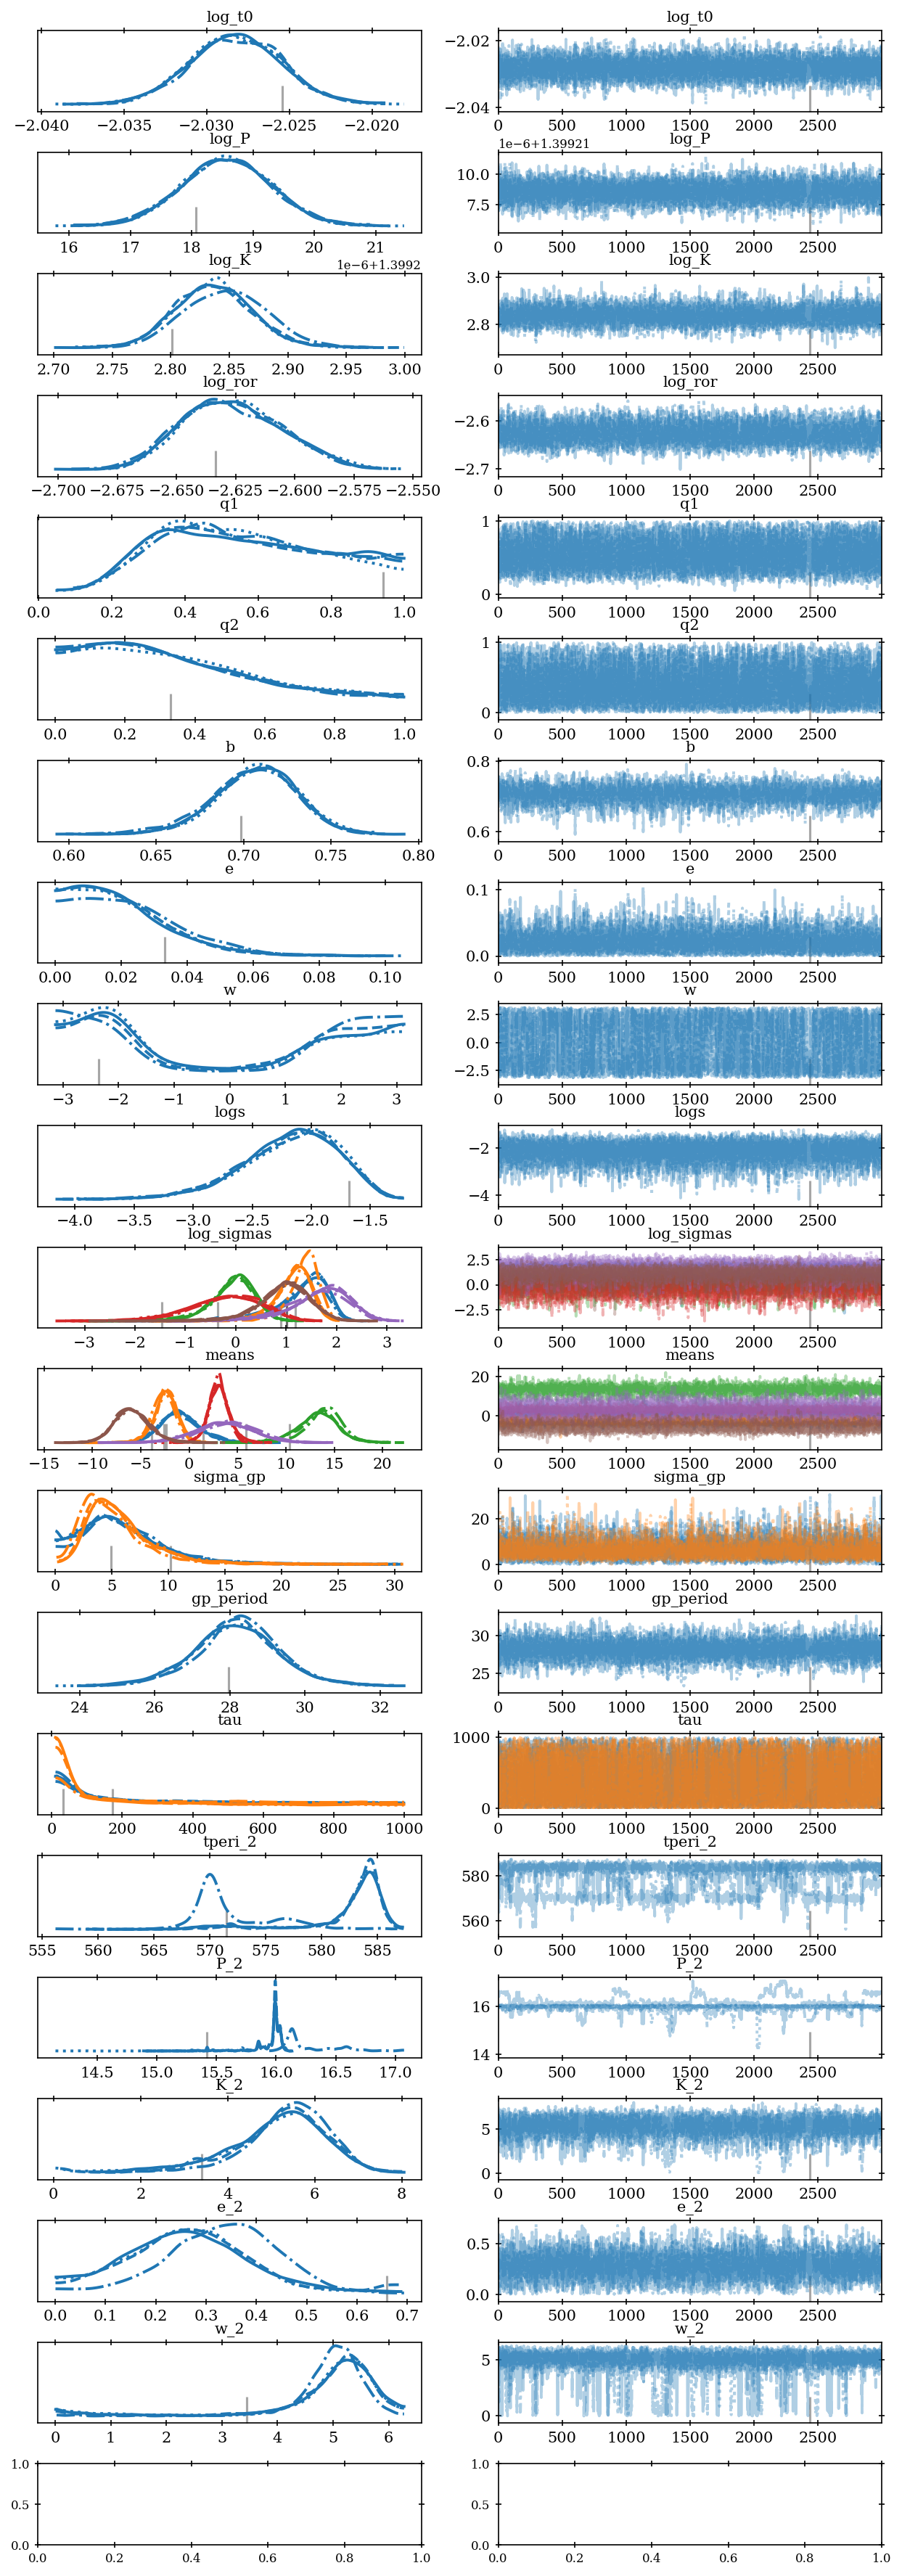

In [128]:
# trace plot
fig, ax = plt.subplots(len(var_names), 2, figsize=(10,30), dpi=150)
fig.subplots_adjust(hspace=0.5)
az.plot_trace(trace, var_names=var_names, axes=ax)
# plt.savefig(f'./plots/toi442/trace_{version_names[version]}_{n_planets}planets.png', 
#             dpi=150, bbox_inches='tight', pad_inches=0.1)
plt.show()

### Resulting parameters

In [79]:
flat_samps = trace.posterior.stack(sample=("chain", "draw"))

In [80]:
import pickle
from uncertainties.umath import *
from asymmetric_uncertainty import a_u

params = {}
if circular:
    file_ = f'./results/toi442/{star_name}_v{version}_{version_names[version]}_{n_planets}planets_circular.txt'
else:
    file_ = f'./results/toi442/{star_name}_v{version}_{version_names[version]}_{n_planets}planets_2.txt'

with open(file_, 'w') as f:
    for var in flat_samps.data_vars:
        if flat_samps[var].ndim > 1 and flat_samps[var].shape[0] > 10:
            continue
        else:
            if flat_samps[var].ndim > 1:
                for n in range(flat_samps[var].shape[0]):
                    parameter = a_u(flat_samps[var].median(dim='sample').values[n],
                                flat_samps[var].quantile(q=0.84, dim='sample').values[n]-flat_samps[var].median(dim='sample').values[n],
                                flat_samps[var].median(dim='sample').values[n]-flat_samps[var].quantile(q=0.16, dim='sample').values[n])
                    print(var+f'_{n}', " = {r:.6f}".format(r=parameter))
                    params[var+f'_{n}'] = parameter
                    f.write(var+f'_{n} = {parameter:.6f}\n')
            else:
                if var == 'r_pl':
                    parameter = a_u(flat_samps[var].median().item()*u.R_sun.to(u.R_earth),
                                flat_samps[var].quantile(q=0.84).item()*u.R_sun.to(u.R_earth)-flat_samps[var].median().item()*u.R_sun.to(u.R_earth),
                                flat_samps[var].median().item()*u.R_sun.to(u.R_earth)-flat_samps[var].quantile(q=0.16).item()*u.R_sun.to(u.R_earth))
                else:
                    parameter = a_u(flat_samps[var].median().item(),
                                    flat_samps[var].quantile(q=0.84).item()-flat_samps[var].median().item(),
                                    flat_samps[var].median().item()-flat_samps[var].quantile(q=0.16).item())
                print(var, " = {r:.6f}".format(r=parameter))
                params[var] = parameter
                f.write(f'{var} = {parameter:.6f}\n')
    print('----------------')
    tess_jitter = np.exp(params['logs'])
    print('tess_jitter = {:.3f}'.format(tess_jitter))
    params['tess_jitter'] = tess_jitter
    f.write(f'tess_jitter = {tess_jitter:.3f}\n')
    print('----------------')
    num = flat_samps['b'].values * (1.0 + flat_samps['e'].values * np.sin(flat_samps['w'].values))
    den = (flat_samps['a'].values*u.au.to(u.R_sun) /  flat_samps['rstar'].values) * (1.0 - flat_samps['e'].values**2)
    cosi = num / den
    inclination = np.degrees(np.arccos(cosi))
    inclination_u = a_u(np.median(inclination), np.percentile(inclination, 84) - np.median(inclination), np.median(inclination)- np.percentile(inclination, 16))
    print(f'inclination = {inclination_u:.6f} deg')
    f.write(f'inclination = {inclination_u:.6f}\n')
    print('----------------')
    num = np.sqrt((1+flat_samps['ror'].values)**2 - flat_samps['b'].values**2)
    den = (flat_samps['a'].values*u.au.to(u.R_sun) /  flat_samps['rstar'].values) * np.sin(np.radians(inclination)) 
    arg = num / den
    Tdur = (flat_samps['P'].values / np.pi) * np.arcsin(arg) * u.day.to(u.hour)
    Tdur_u = a_u(np.median(Tdur), np.percentile(Tdur, 84) - np.median(Tdur), np.median(Tdur)- np.percentile(Tdur, 16))
    print(f'Tdur = {Tdur_u:.6f} hours')
    f.write(f'Tdur = {Tdur_u:.6f}\n')
    print('----------------')
    for i, inst in enumerate(rv_inst_names_used):
        jitter = np.exp(params['log_sigmas_'+str(i)])
        params[f'{inst}_jitter'] = jitter
        print(f'{inst}_jitter = {jitter:.3f}')
        f.write(f'{inst}_jitter = {jitter:.3f}\n')
    print('----------------')
    # Precisions:
    key_params = ['m_pl_0', 'r_pl', 'P', 't0']
    for param in key_params:
        precision = (params[param].items()[1]+params[param].items()[2])/2/params[param].items()[0]*100
        params[param+'_precision'] = precision
        print(f'{param} precision: {precision:.4f} %')
        f.write(f'{param}_precision = {precision:.4f} %\n')
    # save to pickle

if circular: 
    with open(f'./results/toi442/{star_name}_v{version}_{version_names[version]}_{n_planets}planets_circular.pkl', 'wb') as f1:
        pickle.dump(params, f1)
    # load pickle
    # with open(f'./results/toi442/{star_name}_v{version}_{version_names[version]}_{n_planets}planets_circular.pkl', 'rb') as f1:
    #     params = pickle.load(f1)
else:
    with open(f'./results/toi442/{star_name}_v{version}_{version_names[version]}_{n_planets}planets_2.pkl', 'wb') as f1:
        pickle.dump(params, f1)
    # load pickle
    # with open(f'./results/toi442/{star_name}_v{version}_{version_names[version]}_{n_planets}planets.pkl', 'rb') as f1:
    #     params = pickle.load(f1)
f.close()
f1.close()                            

log_t0  = -2.028279 (+0.002766, -0.002681)
log_P  = 1.399219 (+0.000001, -0.000001)
log_K_0  = 2.841017 (+0.026647, -0.026107)
log_ror  = -2.622550 (+0.022982, -0.019942)
lc_mean  = 0.001158 (+0.016596, -0.017016)
logs  = -2.132321 (+0.339398, -0.444750)
means_0  = -1.173501 (+1.689262, -1.606254)
means_1  = -2.114467 (+0.974219, -0.926313)
means_2  = 12.284648 (+1.675033, -1.709238)
means_3  = 2.319910 (+0.917551, -0.887090)
means_4  = 4.596846 (+2.775651, -2.890072)
means_5  = -6.915372 (+1.815938, -1.672448)
log_sigmas_0  = 1.168581 (+0.460539, -0.836823)
log_sigmas_1  = 0.847042 (+0.330344, -0.465602)
log_sigmas_2  = -0.004952 (+0.333627, -0.437231)
log_sigmas_3  = -0.333524 (+0.615233, -0.705824)
log_sigmas_4  = 1.697307 (+0.510120, -0.691446)
log_sigmas_5  = 1.010306 (+0.437133, -0.510255)
gp_period  = 28.832201 (+1.500638, -0.579018)
q1  = 0.505131 (+0.278272, -0.190510)
q2  = 0.325986 (+0.356102, -0.220930)
mstar  = 0.542002 (+0.000996, -0.000996)
rstar  = 0.536020 (+0.000996, 

In [81]:
if version in [1, 3, 5]:
    fig, ax = plt.subplots(1,3,figsize=(12,4))
    for i in range(3):
        ax[i].hist(flat_samps['trend'][i].values)
        ax[i].axvline(az.hdi(flat_samps['trend'][i].values, hdi_prob=.95)[0], linestyle='--', color='k')
        ax[i].axvline(az.hdi(flat_samps['trend'][i].values, hdi_prob=.95)[1], linestyle='--', color='k')
        # annotate the values of hdi
        ax[i].text(0.05, 0.9, f'95% HDI:\n{az.hdi(flat_samps["trend"][i].values, hdi_prob=.95)[0]:.6f} to {az.hdi(flat_samps["trend"][i].values, hdi_prob=.95)[1]:.6f}',
                transform=ax[i].transAxes, bbox=dict(facecolor='white', alpha=0.8))
    plt.savefig(f'./plots/toi442/trend_hdi_v{version}.png', dpi=100, bbox_inches='tight', facecolor='w')

In [82]:
if version in [1, 3, 5]:    
    for i in range(3):
        print(f'trend_{i} value: {params[f"trend_{i}"]:.6f}')
        print(f'trend_{i} sigmas: {params[f"trend_{i}"].value/((params[f"trend_{i}"].minus + params[f"trend_{i}"].plus)/2):.1f}')

In [83]:
if version in [1, 3, 5]:
    deltav = flat_samps['bkg_pred'].values[np.argmax(np.median(flat_samps['bkg_pred'], axis=-1)),:]-flat_samps['bkg_pred'].values[np.argmin(np.median(flat_samps['bkg_pred'], axis=-1)),:]
    print(f'Delta RV over time span: {np.median(deltav):.1f} +{(np.percentile(deltav, 84)-np.percentile(deltav, 16))/2:.1f} m/s')
    plt.plot(x_rv, np.median(flat_samps['bkg'], axis=-1))
    # paint the 16th and 84th percentiles
    plt.fill_between(x_rv, np.percentile(flat_samps['bkg'], 16, axis=-1), np.percentile(flat_samps['bkg'], 84, axis=-1), alpha=0.3)
    plt.plot(t_rv, np.median(flat_samps['bkg_pred'], axis=-1))
    plt.fill_between(t_rv, np.percentile(flat_samps['bkg_pred'], 16, axis=-1), np.percentile(flat_samps['bkg_pred'], 84, axis=-1), alpha=0.3)

In [84]:
# improve period uncertainty?
# dreizler et al: 4.052037 +/- 0.000004
params['P']

In [85]:
# precision in Radius in Dreizler paper is 6.3 %

### Cornerplot

In [86]:
CORNER_KWARGS = dict(
    smooth=0.5,
    plot_density=True,
    plot_datapoints=True,
    fill_contours=False,
    #levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.)),
    levels=(0.16,0.5,0.84),
    max_n_ticks=3
)

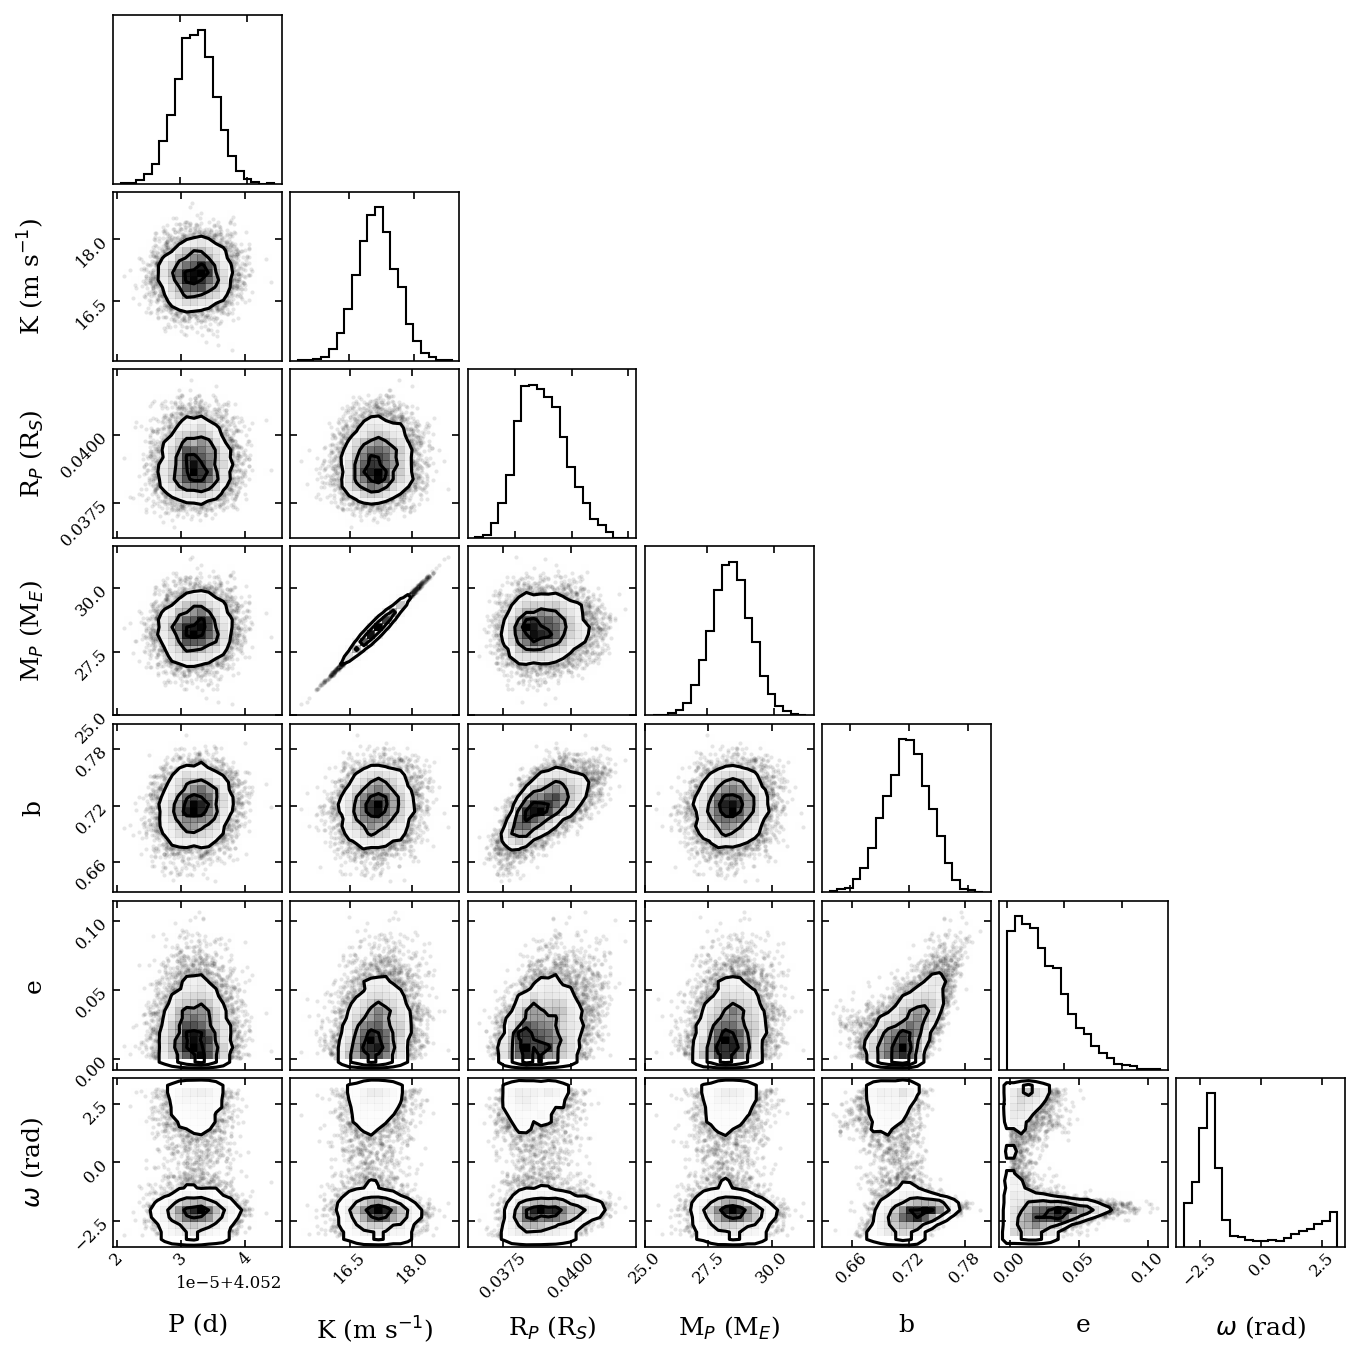

In [87]:
from cProfile import label
import corner
from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter()

fig, ax = plt.subplots(7, 7, figsize=(9, 9))

figure = corner.corner(trace, var_names=['P', 'K', 'r_pl', 'm_pl', 'b', 'e', 'w'],
                        labels=["P (d)", "K (m s$^{-1}$)", "R$_P$ (R$_S$)", "M$_P$ (M$_E$)", "b", "e", "$\omega~$(rad)"], label_kwargs={'fontsize':12},
                        show_titles=False, title_kwargs={'fontsize':12, 'pad':9.0}, titles=['P', 'K', 'R\_P','M\_P','b','e','$\omega$'], divergences=False, plot_contours=True,
                        labelpad=0.1, color='k', fig=fig, **CORNER_KWARGS)
for i,ax in enumerate(figure.get_axes()):
    ax.tick_params(axis='both', pad=1, direction='in', labelbottom=True, labelleft=True, left=True, bottom=True)

if circular:
    plt.savefig(f'./plots/toi442/corner_planet1_{star_name}_v{version}_{version_names[version]}_{n_planets}planets_circular.png', dpi=100, bbox_inches='tight', facecolor='w')
else:
    plt.savefig(f'./plots/toi442/corner1_{star_name}_v{version}_{version_names[version]}_{n_planets}planets.png', dpi=100, bbox_inches='tight', facecolor='w')
plt.show()

In [88]:
# paper figure

# CORNER_KWARGS_ = dict(
#     smooth=0.5,
#     plot_density=True,
#     plot_datapoints=True,
#     fill_contours=True,
#     #levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.)),
#     levels=(0.16,0.5,0.84),
#     max_n_ticks=3, 
#     data_kwargs={'alpha': 0.9, 'ms': 0.5},)

# fig, ax = plt.subplots(12, 12, figsize=(9, 9))
# corner_vars = ["t0","P","K","ror","b","e","w","sigma_gp","gp_period", "log_Q0","log_dQ","f"]
# figure = corner.corner(trace, var_names=corner_vars,
#                         labels=["t0 (d)", "P (d)", "K (m s$^{-1}$)", "R$_P$/R$_\star$", "b", "e", "$\omega~$(rad)",
#                                 "$\sigma_{GP}$ (m s$^{-1}$)", "P$_{GP}$", "$\log$ Q$_0$", "$\log$ dQ", "$f$"], label_kwargs={'fontsize':8},
#                         show_titles=False, divergences=False, plot_contours=True, hist_kwargs={'linewidth': 0.5},
#                         labelpad=0.2, fig=fig, contour_kwargs={'linewidths': 0.5}, **CORNER_KWARGS_)
# for i,ax in enumerate(figure.get_axes()):
#     ax.tick_params(axis='both', pad=0.5, length=1, direction='in', labelsize=7, 
#                    labelbottom=True, labelleft=True, left=True, bottom=True)
#     for axis in ['top','bottom','left','right']:
#         ax.spines[axis].set_linewidth(0.5)
# plt.savefig(f'./plots/paper/corner_442.png', dpi=400, bbox_inches='tight', facecolor='w')

In [89]:
# Corner 2 planets
#fig, ax = plt.subplots(9, 9, figsize=(9, 9))
if n_planets == 2:
    if not circular:
        var_names2 = ['P_2', 'K_2', 'm_pl_2', 'tperi_2', 'e_2', 'w_2']
    else:
        var_names2 = ['P_2', 'K_2', 'm_pl_2', 'tperi_2']
    figure = corner.corner(trace, var_names=var_names2, label_kwargs={'fontsize':16}, **CORNER_KWARGS)
    for i, ax in enumerate(figure.get_axes()):
        ax.tick_params(labelsize=14)
    plt.savefig(f'./plots/toi442/corner2_{star_name}_v{version}_{version_names[version]}_{n_planets}planets.png', dpi=100, bbox_inches='tight', facecolor='w')

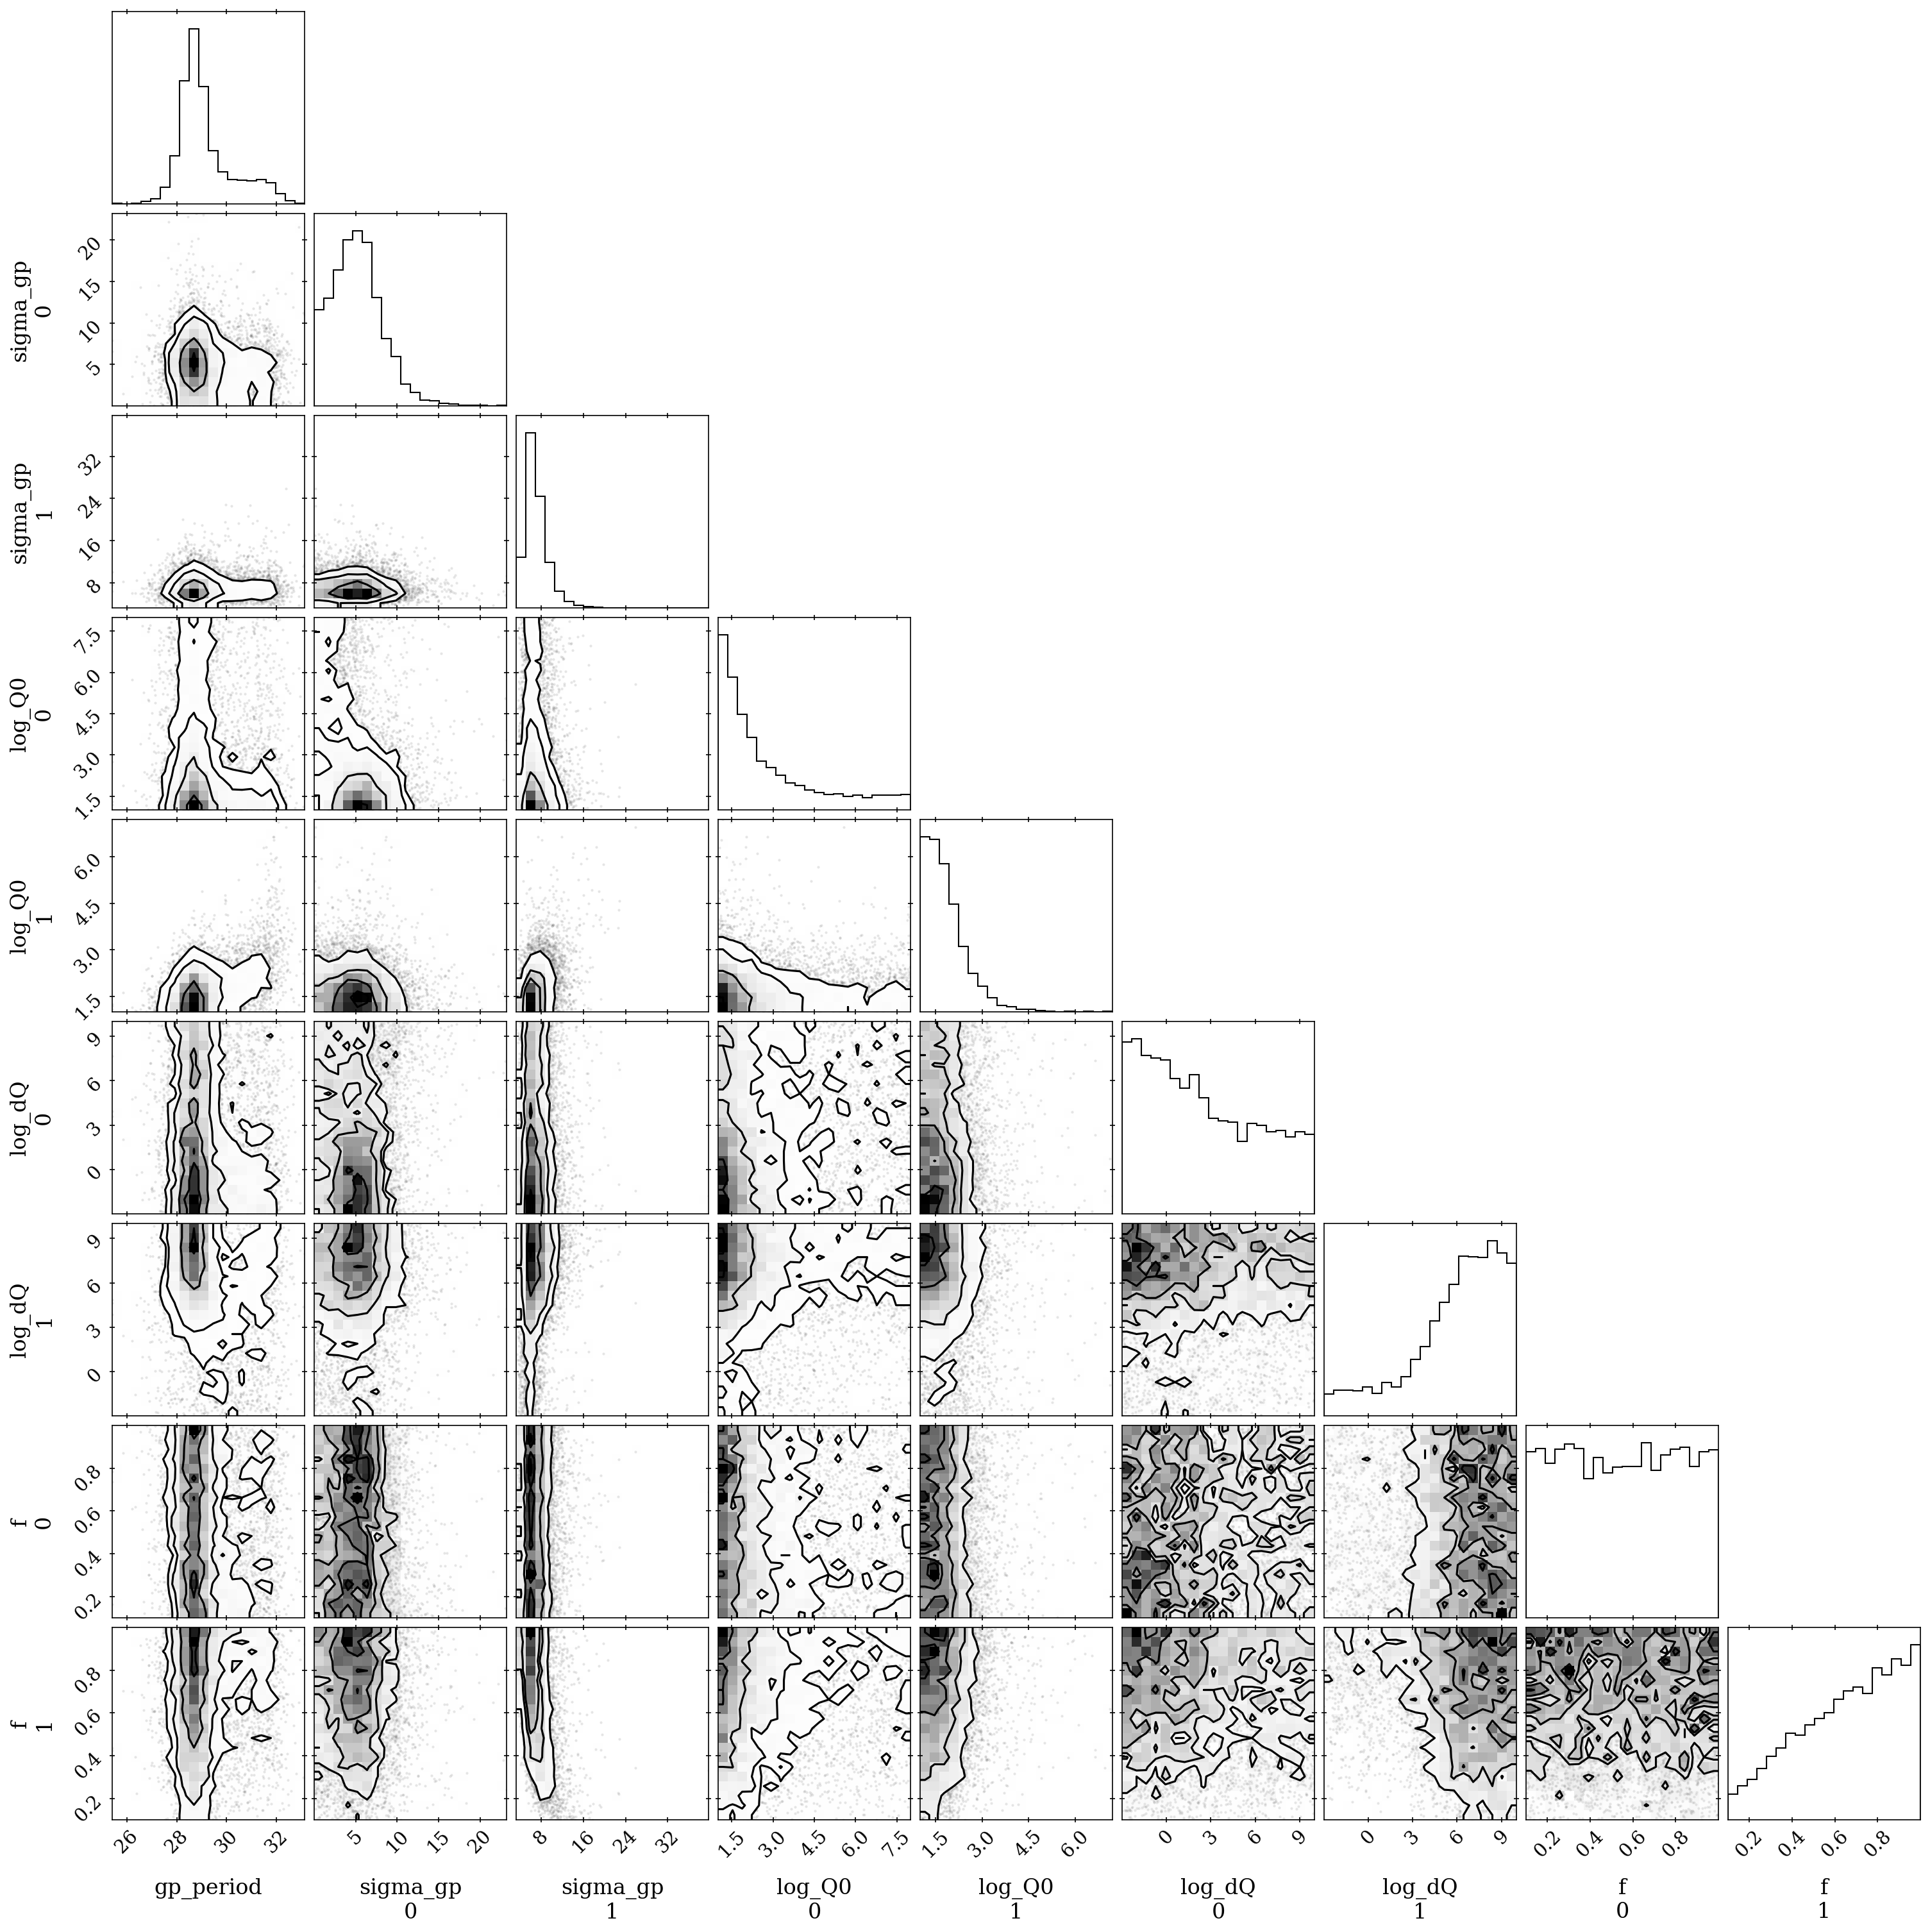

In [90]:
## Corner GP parameters
if version == 2 or version == 3:
    gp_vars = ['gp_period', 'sigma_gp', 'tau']
    figure = corner.corner(trace, var_names=gp_vars, label_kwargs={'fontsize':16})
    for i, ax in enumerate(figure.get_axes()):
        ax.tick_params(labelsize=14)
    plt.savefig(f'./plots/toi442/corner3_{star_name}_v{version}_{version_names[version]}_{n_planets}planets2.png', dpi=100, bbox_inches='tight', facecolor='w')
elif version == 4 or version == 5:
    gp_vars = ['gp_period', 'sigma_gp', 'log_Q0', 'log_dQ', 'f']
    figure = corner.corner(trace, var_names=gp_vars, label_kwargs={'fontsize':16})
    for i, ax in enumerate(figure.get_axes()):
        ax.tick_params(labelsize=14)
    plt.savefig(f'./plots/toi442/corner3_{star_name}_v{version}_{version_names[version]}_{n_planets}planets.png', dpi=100, bbox_inches='tight', facecolor='w')

In [91]:
if version == 5 and n_planets == 1:
    var_names_ = [s for s in var_names if not any(word in s for word in ['means', 'log_sigmas'])]
    titles_ = ['log_t0',
    'log_P',
    'log_K',
    'log_ror',
    'q1',
    'q2',
    'b',
    'e',
    'w',
    'logs',
    'sigma_gp_0',
    'sigma_gp_1',
    'log_Q0_0',
    'log_Q0_1',
    'log_dQ_0',
    'log_dQ_1',
    'f_0',
    'f_1',
    'gp_period']
    fig, ax = plt.subplots(len(var_names_)+4, len(var_names_)+4, figsize=(20, 20))

    figure = corner.corner(trace, var_names=var_names_,
                            labels=titles_, label_kwargs={'fontsize':12},
                            show_titles=False, title_kwargs={'fontsize':12, 'pad':9.0}, titles=titles_, divergences=False, plot_contours=True,
                            labelpad=0.1, color='k', fig=fig, **CORNER_KWARGS)
    for i,ax in enumerate(figure.get_axes()):
        ax.tick_params(axis='both', pad=1, direction='in', labelbottom=True, labelleft=True, left=True, bottom=True)

    plt.savefig(f'./plots/toi442/corner4_{star_name}_v{version}_{version_names[version]}_{n_planets}planets.png', dpi=150, bbox_inches='tight', facecolor='w')
    plt.show()

In [92]:
CORNER_KWARGS2 = {'smooth': 0.5,
 'plot_density': False,
 'plot_datapoints': True,
 'fill_contours': False,
 'levels': (0.16, 0.5, 0.84),
 'max_n_ticks': 3} 

In [93]:
# if version == 4 or version == 5:
#     if n_planets == 2:
#         var_names3 = ['tperi_2', 'P_2', 'K_2', 'm_pl_2', 'e_2', 'w_2', 'sigma_gp', 'gp_period', 'log_Q0', 'log_dQ', 'f']
#         var_names3 = ['tperi_2', 'P_2', 'K_2', 'm_pl_2', 'e_2', 'w_2', 'sigma_gp', 'gp_period', 'log_Q0', 'log_dQ', 'f']
        
#         fig, ax = plt.subplots(len(var_names3), len(var_names3), figsize=(12, 12))

#         figure = corner.corner(trace, var_names=var_names3,
#                                 labels=var_names3, label_kwargs={'fontsize':12},
#                                 show_titles=False, title_kwargs={'fontsize':12, 'pad':9.0}, titles=var_names3, divergences=False, plot_contours=False,
#                                 labelpad=0.1, color='k', fig=fig, **CORNER_KWARGS2)
#         for i,ax in enumerate(figure.get_axes()):
#             ax.tick_params(axis='both', pad=1, direction='in', labelbottom=True, labelleft=True, left=True, bottom=True)

#         plt.savefig(f'./plots/toi442/corner5_{star_name}_v{version}_{version_names[version]}_{n_planets}planets.png', dpi=150, bbox_inches='tight', facecolor='w')
#         plt.show()

In [94]:
# log_like = trace.log_likelihood.stack(sample=("chain", "draw"))['obs'].values
# plt.figure(figsize=(4, 4), dpi=150)
# plt.scatter(flat_samps['P_2'].values, log_like, s=1, c='k', alpha=0.5)
# plt.xlabel("log likelihood")
# plt.ylabel("P_2 (d)")
# plt.savefig(f'./plots/toi442/log_like_P2_{star_name}_v{version}_{version_names[version]}_{n_planets}planets.png', 
#             dpi=150, bbox_inches='tight', facecolor='w')


### RV fit plots

In [110]:
period = np.median(flat_samps["P"])
t0_ = np.median(flat_samps["t0"])
rv_model = np.percentile(flat_samps['rv_model'].values, [16,50,84], axis=-1)
rv_model_pred = np.percentile(flat_samps["rv_model_pred"].values, [16,50,84], axis=-1)
vrad_ = np.percentile(flat_samps["vrad"].values, [16,50,84], axis=-1)
vrad_pred_ = np.percentile(flat_samps["vrad_pred"].values, [16,50,84], axis=-1)
mean_ = np.percentile(flat_samps["mean"].values, [16,50,84], axis=-1)
if n_planets == 2:
    period_2 = np.median(flat_samps["P_2"])
    tperi_2_ = np.median(flat_samps['tperi_2'])
    vrad_2_ = np.percentile(flat_samps["vrad_2"].values, [16,50,84], axis=-1)
    vrad_2_pred_ = np.percentile(flat_samps["vrad_2_pred"].values, [16,50,84], axis=-1)

lc_model = np.percentile(flat_samps['lc'].values, [16,50,84], axis=-1)
lc_phase = np.percentile(flat_samps["lc_phase"], [16,50,84], axis=-1)

if version == 0 or version == 1:
    residuals = y_rv - (rv_model[1] + mean_[1])
elif version == 2 or version == 3 or version == 4 or version == 5:
    gp_rv_pred_opt = np.percentile(flat_samps["gp_rv_pred_opt"].values, [16,50,84], axis=-1)
    gp_rv_pred_nir = np.percentile(flat_samps["gp_rv_pred_nir"].values, [16,50,84], axis=-1)
    gp_rv_pred = np.empty(rv_model.shape, dtype=gp_rv_pred_opt.dtype)
    gp_rv_pred[:, rv_band_id == 1] = gp_rv_pred_opt
    gp_rv_pred[:, rv_band_id == 0] = gp_rv_pred_nir
    if version == 4 and n_planets ==1:
        gp_rv_pred_nir_plot = np.percentile(flat_samps["gp_rv_pred_plot_nir"].values, [16,50,84], axis=-1)
        gp_rv_pred_opt_plot = np.percentile(flat_samps["gp_rv_pred_plot_opt"].values, [16,50,84], axis=-1)
    residuals = y_rv - (rv_model[1] + mean_[1] + gp_rv_pred[1])
    planet_residuals = y_rv - vrad_[1]
    gp_residuals = y_rv - gp_rv_pred[1]
    # residuals = residuals.values

if version == 0:
    background = mean_[1].copy()
elif version == 1:
    background = mean_[1] + np.median(flat_samps['bkg'].values, axis=-1)
elif version == 2: 
    background = mean_[1] + gp_rv_pred[1]
elif version == 3:
    background = mean_[1] + np.median(flat_samps['bkg'].values, axis=-1) + gp_rv_pred[1]
elif version == 4:
    background = mean_[1] + gp_rv_pred[1]
    gpandmean = gp_rv_pred[1] + mean_[1]
elif version == 5:
    background = mean_[1] + np.median(flat_samps['bkg'].values, axis=-1) + gp_rv_pred[1]
    gpandmean = gp_rv_pred[1] + mean_[1]


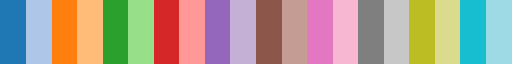

In [96]:
import matplotlib as mpl
cmap = mpl.colormaps['tab20']
cmap

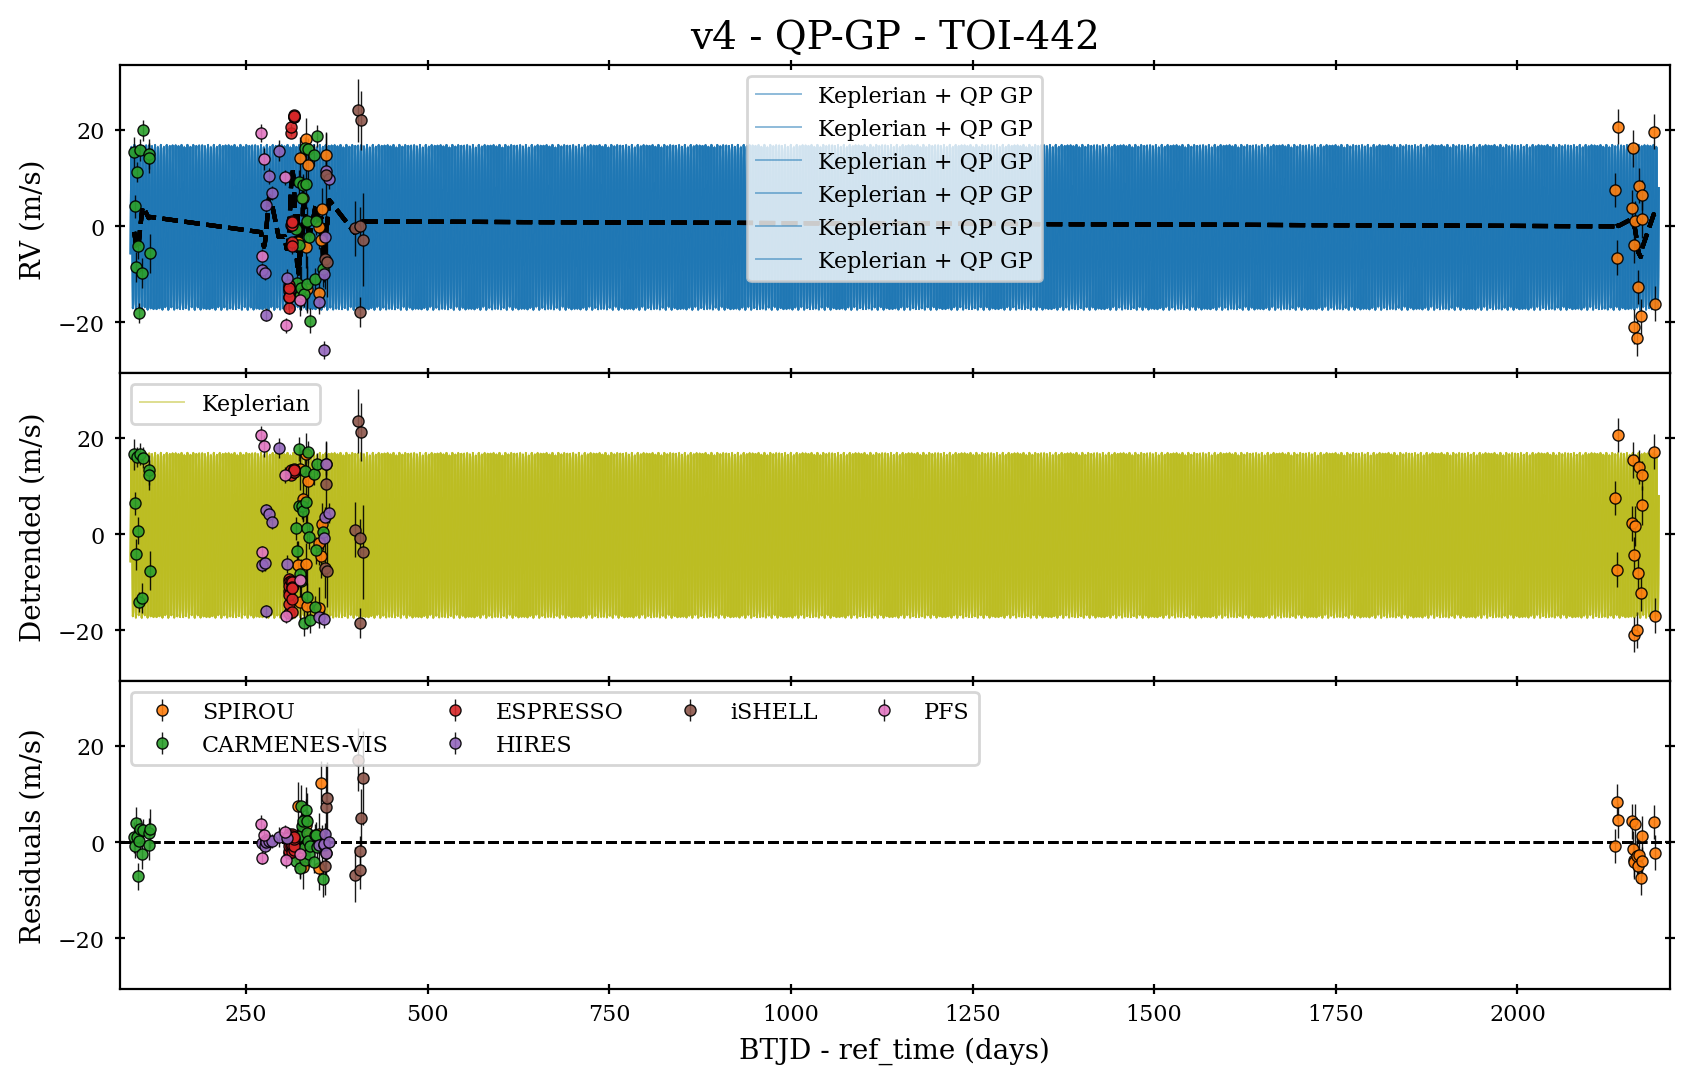

In [97]:
fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True, sharey=True, dpi=200)
fig.subplots_adjust(hspace=0)

ax[0].set_title(f"v{version} - {version_names[version]} - {star_name}", fontsize=14)
ax[0].set_xlim(x_rv.min()-20, x_rv.max()+20)
ax[2].set_xlabel("BTJD - ref_time (days)")
ax[0].set_ylabel("RV (m/s)")
ax[1].set_ylabel("Detrended (m/s)")
ax[2].set_ylabel("Residuals (m/s)")

labels_ = ['Keplerian', 'Keplerian + drift', 'Keplerian + SHO GP', 'Keplerian + SHO GP + drift', 
           'Keplerian + QP GP', 'Keplerian + QP GP + drift']
for i, name in enumerate(rv_inst_names_used):
    fmt = ['o', 'o', 'o', 'o', 'o', 'o', 'v', 'v'] # ['v', '^']
    colors = [cmap(2), cmap(4), cmap(6), cmap(8), cmap(10), cmap(12), cmap(14), cmap(16)]
    m = rv_inst_id == i
    # ax 0
    ax[0].errorbar(x_rv[m], y_rv[m] - mean_[1][m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=0.5, ecolor='k', 
                markersize=4, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9)
    if version == 0 or version == 1:
        ax[0].plot(t_rv, rv_model_pred[1], color=cmap(0), lw=0.7, zorder=-100, alpha=0.5,  label=labels_[version])
        art = ax[0].fill_between(t_rv, rv_model_pred[0], rv_model_pred[2], 
                                color=cmap(0), alpha=0.15, zorder=2) 
        art.set_edgecolor("none")
        ax[0].legend()
    elif version == 2 or version == 3 or version == 4 or version == 5:
        # to better plot the GP model, but takes longer to sample..
        # ax[0].plot(t_rv, gp_rv_pred_plot[1], linestyle='--', color='k', lw=1.5, zorder=-50)
        # ax[0].plot(t_rv, rv_model_pred[1] + gp_rv_pred_plot[1], color=cmap(0), lw=0.7, zorder=-100, alpha=0.5,  label=labels_[version])
        # art = ax[0].fill_between(t_rv, rv_model_pred[0] + gp_rv_pred_plot[0], rv_model_pred[2] + gp_rv_pred_plot[2], 
        #                         color=cmap(0), alpha=0.15, zorder=2) 
        # art.set_edgecolor("none")
        # ax[0].legend()
        ax[0].plot(x_rv, gp_rv_pred[1], linestyle='--', color='k', lw=1.5, zorder=-50)
        ax[0].plot(t_rv, rv_model_pred[1], color=cmap(0), lw=0.7, zorder=-100, alpha=0.5,  label=labels_[version])
        art = ax[0].fill_between(t_rv, rv_model_pred[0], rv_model_pred[2], 
                                color=cmap(0), alpha=0.15, zorder=2) 
        art.set_edgecolor("none")
        ax[0].legend()

    if i == 0:
        ax[0].legend(fontsize=8, loc='upper left', ncols=2)
    # ax 1
    ax[1].errorbar(x_rv[m], y_rv[m] - background[m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=0.5, ecolor='k', 
                markersize=4, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9)
    ax[1].plot(t_rv, vrad_pred_[1], color=cmap(16), lw=0.7, zorder=-100, alpha=0.5,  label='Keplerian')
    art = ax[1].fill_between(t_rv, vrad_pred_[0], vrad_pred_[2], 
                            color=cmap(16), alpha=0.15, zorder=2) 
    art.set_edgecolor("none")

    # ax 2
    ax[2].errorbar(x_rv[m], residuals[m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=0.5, ecolor='k', 
                markersize=4, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9, label=name)
    ax[2].axhline(0, linestyle='--', color='k', lw=1, zorder=-100)
    if i == 0:
        ax[1].legend(fontsize=8, loc='upper left', ncols=2)
        ax[1].legend(fontsize=8, loc='upper left')
    ax[2].legend(fontsize=8, loc='upper left', ncols=4)
if circular:
    plt.savefig(f'./plots/toi442/rv_paper_{star_name}_v{version}_{version_names[version]}_{n_planets}planets_circular.png', dpi=300, facecolor='w', bbox_inches='tight')
else:
    plt.savefig(f'./plots/toi442/rv_paper_{star_name}_v{version}_{version_names[version]}_{n_planets}planets.png', dpi=300, facecolor='w', bbox_inches='tight')
plt.show()

RV fit for paper

In [99]:
x_rv.min()

96.07062334280931

/tmp/ipykernel_155814/4777499.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,1].set_yticklabels(['','','','','','','','','',''])
/tmp/ipykernel_155814/4777499.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,1].set_yticklabels(['','','','','','','','','',''])
/tmp/ipykernel_155814/4777499.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,1].set_yticklabels(['','','','','','','','','',''])


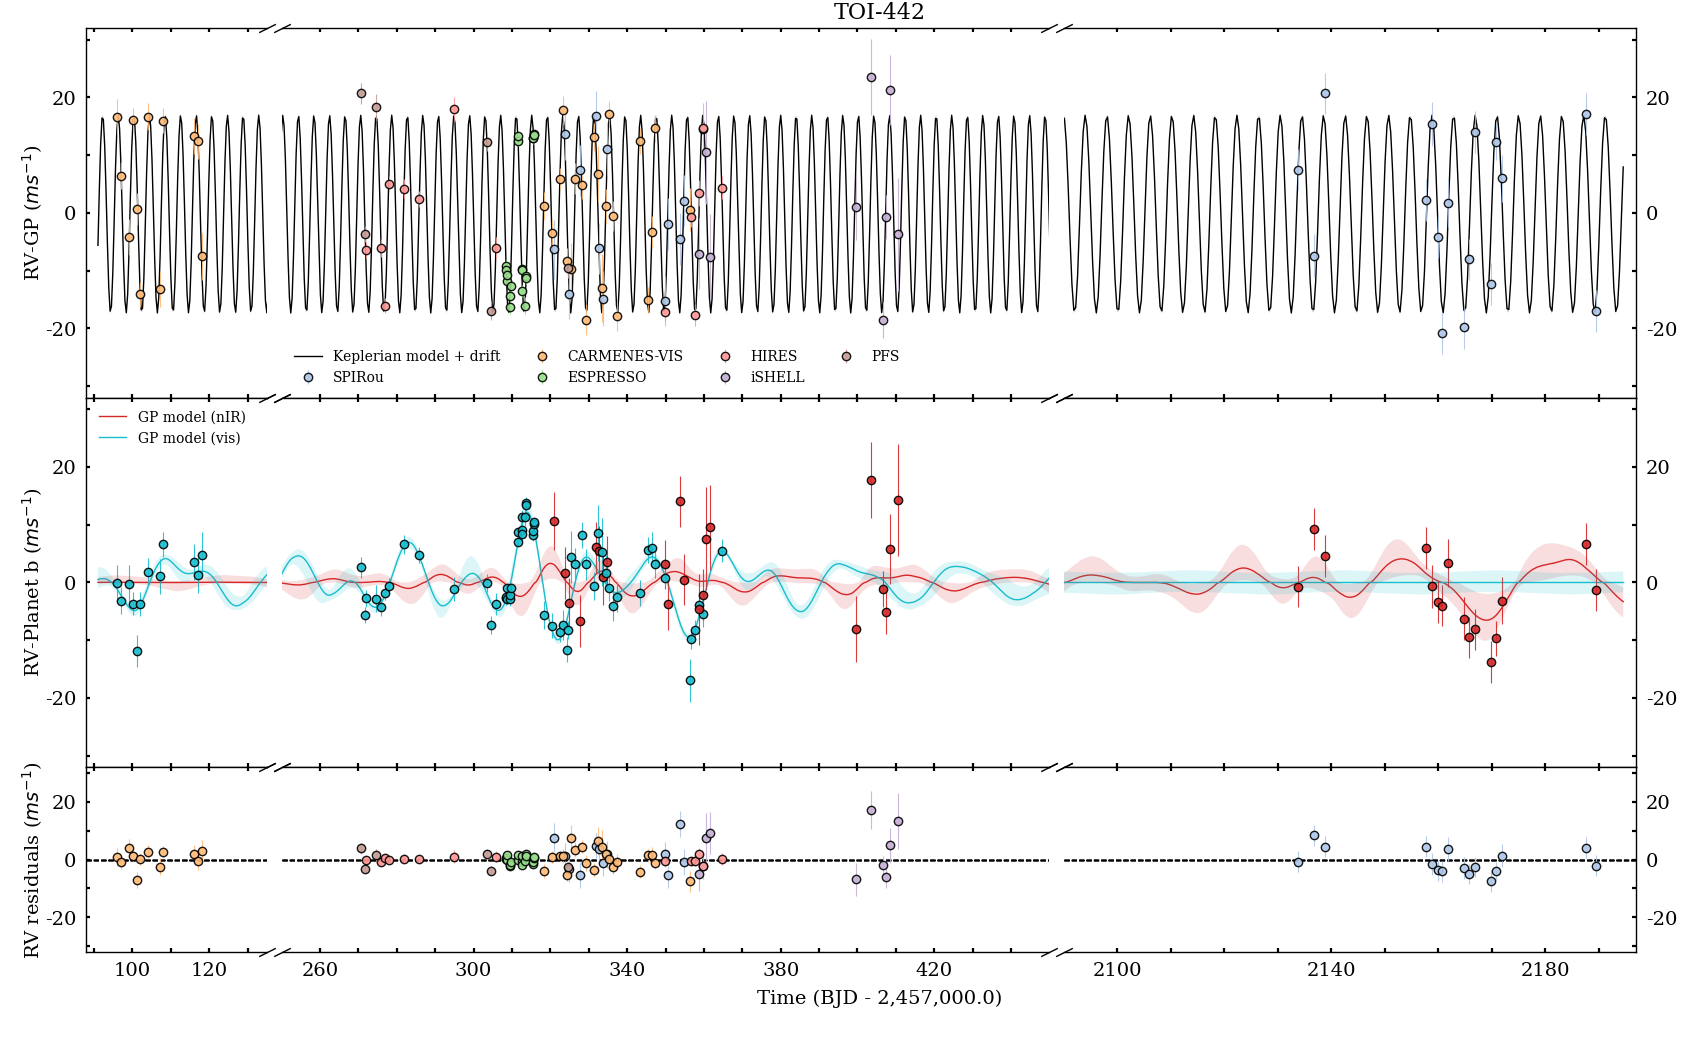

In [101]:
if version == 4:    
    fig = plt.figure(figsize=(10, 6), dpi=200)
    gs = fig.add_gridspec(3, 8, width_ratios= [1,1,1,1,1,1,1,1], height_ratios= [1,1,0.5], wspace=0.08, hspace=0.0)
    ax = np.empty((3, 3), dtype=object)
    ax[0,0] = fig.add_subplot(gs[0, 0:1])
    ax[0,1] = fig.add_subplot(gs[0, 1:5])
    ax[0,2] = fig.add_subplot(gs[0, 5:8])
    ax[1,0] = fig.add_subplot(gs[1, 0:1])
    ax[1,1] = fig.add_subplot(gs[1, 1:5])
    ax[1,2] = fig.add_subplot(gs[1, 5:8])
    ax[2,0] = fig.add_subplot(gs[2, 0:1])
    ax[2,1] = fig.add_subplot(gs[2, 1:5])
    ax[2,2] = fig.add_subplot(gs[2, 5:8])
    y_labels = ['RV-GP ($m s^{-1}$)', 'RV-Planet b ($m s^{-1}$)', 'RV residuals ($m s^{-1}$)']
    for i in range(3):
        ax[i,0].set_xlim(88, 135)
        ax[i,1].set_xlim(250, 450)
        ax[i,2].set_xlim(2090, 2197)
        ax[i,0].set_ylabel(y_labels[i], labelpad=0.1, size=7)
        ax[i,0].spines.right.set_visible(False)
        ax[i,1].spines.left.set_visible(False)
        ax[i,1].spines.right.set_visible(False)
        ax[i,2].spines.left.set_visible(False)
        ax[i,0].set_yticks([-40,-30,-20,-10,0,10,20,30,40,50])
        ax[i,2].set_yticks([-40,-30,-20,-10,0,10,20,30,40,50])
        ax[i,0].set_yticklabels(['-40','','-20','','0','','20','','40',''])
        ax[i,2].set_yticklabels(['-40','','-20','','0','','20','','40',''])
        ax[i,1].set_yticklabels(['','','','','','','','','',''])
        ax[i,0].set_xticks([90,100,110,120,130])
        ax[i,1].set_xticks([260,270,280,290,300,310,320,330,340,350,360,370,380,390,400,410,420,430,440])
        ax[i,2].set_xticks([2100,2110,2120,2130,2140,2150,2160,2170,2180,2190])
        ax[i,1].yaxis.set_ticks_position('none')
        ax[i,0].yaxis.set_ticks_position('left')
        ax[i,2].yaxis.set_ticks_position('right')
        if i == 2:
            ax[i,0].set_xticklabels(['','100','','120',''])
            ax[i,1].set_xticklabels(['260','','','','300','','','','340','','','','380','','','','420','',''])
            ax[i,2].set_xticklabels(['2100','','','','2140','','','','2180',''])
        else:
            ax[i,0].set_xticklabels(['','','','',''])
            ax[i,1].set_xticklabels(['','','','','','','','','','','','','','','','','','',''])
            ax[i,2].set_xticklabels(['','','','','','','','','',''])
        for j in range(3):
            ax[i,j].tick_params(direction='in', length=1.5, labelsize=7)
            ax[i,j].set_ylim(-32,32)
            for axis in ['top','bottom','left','right']:
                ax[i,j].spines[axis].set_linewidth(0.5)
    ax[2,0].annotate('Time (BJD - 2,457,000.0)', xy=(0.44, 0.04), xycoords='figure fraction', ha='center', va='bottom', fontsize=7)
    d = .5
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=6,
                linestyle="none", color='k', mec='k', mew=0.5, clip_on=False)
    ax[0,0].plot([1, 1], [0, 1], transform=ax[0,0].transAxes, **kwargs)
    ax[0,1].plot([0, 0], [1, 0], transform=ax[0,1].transAxes, **kwargs)
    ax[0,1].plot([1, 1], [0, 1], transform=ax[0,1].transAxes, **kwargs)
    ax[0,2].plot([0, 0], [1, 0], transform=ax[0,2].transAxes, **kwargs)
    ax[1,0].plot([1, 1], [0, 1], transform=ax[1,0].transAxes, **kwargs)
    ax[1,1].plot([0, 0], [1, 0], transform=ax[1,1].transAxes, **kwargs)
    ax[1,1].plot([1, 1], [0, 1], transform=ax[1,1].transAxes, **kwargs)
    ax[1,2].plot([0, 0], [1, 0], transform=ax[1,2].transAxes, **kwargs)
    ax[2,0].plot([1, 1], [0, 1], transform=ax[2,0].transAxes, **kwargs)
    ax[2,1].plot([0, 0], [1, 0], transform=ax[2,1].transAxes, **kwargs)
    ax[2,1].plot([1, 1], [0, 1], transform=ax[2,1].transAxes, **kwargs)
    ax[2,2].plot([0, 0], [1, 0], transform=ax[2,2].transAxes, **kwargs)

    plot_lw = 0.5
    models_c = 'k'
    nir_color = cmap(6)
    opt_color = cmap(18)
    msize = 3
    elinew = 0.4 
    inst_labels = ['SPIRou', 'CARMENES-VIS', 'ESPRESSO', 'HIRES', 'iSHELL', 'PFS']
    colors = [cmap(1), cmap(3), cmap(5), cmap(7), cmap(9), cmap(11), cmap(13), cmap(15)]
    fmt = 'o' 
    gp_colors = [nir_color, opt_color, opt_color, opt_color, nir_color, opt_color]
    for i, name in enumerate(rv_inst_names_used):
        m = rv_inst_id == i
        ax[0,0].errorbar(x_rv[m], y_rv[m] - gpandmean[m] , yerr=yerr_rv[m], fmt=fmt, color=colors[i], elinewidth=elinew, ecolor=colors[i], 
                    markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9, label=inst_labels[i])

        ax[0,1].errorbar(x_rv[m], y_rv[m] - gpandmean[m], yerr=yerr_rv[m], fmt=fmt, color=colors[i], elinewidth=elinew, ecolor=colors[i], 
                    markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9)
        
        ax[0,2].errorbar(x_rv[m], y_rv[m] - gpandmean[m], yerr=yerr_rv[m], fmt=fmt, color=colors[i], elinewidth=elinew, ecolor=colors[i], 
                    markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9)

        # ax 1
        ax[1,0].errorbar(x_rv[m], y_rv[m] - mean_[1][m] - rv_model[1][m], yerr=yerr_rv[m], fmt=fmt, color=gp_colors[i], elinewidth=elinew, ecolor=gp_colors[i], 
                    markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9)

        ax[1,1].errorbar(x_rv[m], y_rv[m] - mean_[1][m] - rv_model[1][m], yerr=yerr_rv[m], fmt=fmt, color=gp_colors[i], elinewidth=elinew, ecolor=gp_colors[i], 
                    markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9)

        ax[1,2].errorbar(x_rv[m], y_rv[m] - mean_[1][m] - rv_model[1][m], yerr=yerr_rv[m], fmt=fmt, color=gp_colors[i], elinewidth=elinew, ecolor=gp_colors[i], 
                    markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9)

        # ax 2
        ax[2,0].errorbar(x_rv[m], residuals[m], yerr=yerr_rv[m], fmt=fmt, color=colors[i], elinewidth=elinew, ecolor=colors[i], 
                    markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9, label=name)
        ax[2,0].axhline(0, linestyle='--', color=models_c, lw=plot_lw, zorder=-100)

        ax[2,1].errorbar(x_rv[m], residuals[m], yerr=yerr_rv[m], fmt=fmt, color=colors[i], elinewidth=elinew, ecolor=colors[i], 
                    markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9, label=name)
        ax[2,1].axhline(0, linestyle='--', color=models_c, lw=plot_lw, zorder=-100)

        ax[2,2].errorbar(x_rv[m], residuals[m], yerr=yerr_rv[m], fmt=fmt, color=colors[i], elinewidth=elinew, ecolor=colors[i], 
                    markersize=msize, markeredgewidth=0.5, markeredgecolor='k', alpha=0.9, label=name)
        ax[2,2].axhline(0, linestyle='--', color=models_c, lw=plot_lw, zorder=-100)

    # Models
    ax[0,0].plot(t_rv, rv_model_pred[1], color=models_c, lw=plot_lw, zorder=-100, alpha=1,  label='Keplerian model + drift')
    art = ax[0,0].fill_between(t_rv, rv_model_pred[0] , rv_model_pred[2], color='k', alpha=0.15, zorder=2) 
    art.set_edgecolor("none")
    ax[0,1].plot(t_rv, rv_model_pred[1], color=models_c, lw=plot_lw, zorder=-100, alpha=1)
    art = ax[0,1].fill_between(t_rv, rv_model_pred[0], rv_model_pred[2], color=models_c, alpha=0.15, zorder=2) 
    art.set_edgecolor("none")
    ax[0,2].plot(t_rv, rv_model_pred[1], color=models_c, lw=plot_lw, zorder=-100, alpha=1)
    art = ax[0,2].fill_between(t_rv, rv_model_pred[0], rv_model_pred[2], color=models_c, alpha=0.15, zorder=2) 
    art.set_edgecolor("none")

    ax[1,0].plot(t_rv, gp_rv_pred_nir_plot[1], color=nir_color, lw=plot_lw, zorder=-100, alpha=1,  label='GP model (nIR)')
    art = ax[1,0].fill_between(t_rv, gp_rv_pred_nir_plot[0], gp_rv_pred_nir_plot[2], color=nir_color, alpha=0.15, zorder=2) 
    art.set_edgecolor("none")
    ax[1,1].plot(t_rv, gp_rv_pred_nir_plot[1], color=nir_color, lw=plot_lw, zorder=-100, alpha=1)
    art = ax[1,1].fill_between(t_rv, gp_rv_pred_nir_plot[0], gp_rv_pred_nir_plot[2], color=nir_color, alpha=0.15, zorder=2) 
    art.set_edgecolor("none")
    ax[1,2].plot(t_rv, gp_rv_pred_nir_plot[1], color=nir_color, lw=plot_lw, zorder=-100, alpha=1)
    art = ax[1,2].fill_between(t_rv, gp_rv_pred_nir_plot[0], gp_rv_pred_nir_plot[2], color=nir_color, alpha=0.15, zorder=2) 
    art.set_edgecolor("none")

    ax[1,0].plot(t_rv, gp_rv_pred_opt_plot[1], color=opt_color, lw=plot_lw, zorder=-100, alpha=1,  label='GP model (vis)')
    art = ax[1,0].fill_between(t_rv, gp_rv_pred_opt_plot[0], gp_rv_pred_opt_plot[2], color=opt_color, alpha=0.15, zorder=2) 
    art.set_edgecolor("none")
    ax[1,1].plot(t_rv, gp_rv_pred_opt_plot[1], color=opt_color, lw=plot_lw, zorder=-100, alpha=1)
    art = ax[1,1].fill_between(t_rv, gp_rv_pred_opt_plot[0], gp_rv_pred_opt_plot[2], color=opt_color, alpha=0.15, zorder=2) 
    art.set_edgecolor("none")
    ax[1,2].plot(t_rv, gp_rv_pred_opt_plot[1], color=opt_color, lw=plot_lw, zorder=-100, alpha=1)
    art = ax[1,2].fill_between(t_rv, gp_rv_pred_opt_plot[0], gp_rv_pred_opt_plot[2], color=opt_color, alpha=0.15, zorder=2) 
    art.set_edgecolor("none")

    handles, labels = ax[0,0].get_legend_handles_labels()
    unique_labels = dict(zip(labels, handles))
    ax[0,1].legend(unique_labels.values(), unique_labels.keys(),fontsize=5, loc='lower left', framealpha=0.0, ncol=4)

    handles, labels = ax[1,0].get_legend_handles_labels()
    unique_labels = dict(zip(labels, handles))
    ax[1,0].legend(unique_labels.values(), unique_labels.keys(),fontsize=5, loc='upper left', framealpha=0.0)

    # Title
    ax[0,0].annotate('TOI-442', xy=(0.44, 0.86), xycoords='figure fraction', ha='center', va='bottom', fontsize=8, fontweight='light') 
    plt.savefig(f'./plots/toi442/rvfit_442.pdf', facecolor='w', bbox_inches='tight', format='pdf')
    plt.show()

In [ ]:
if version == 5:
    plt.plot(t_rv, gp_rv_pred_nir_plot[1,:], color='blue', label='NIR GP model')
    plt.plot(t_rv, gp_rv_pred_opt_plot[1,:], color='red', label='Optical GP model')

In [ ]:
# if n_planets == 1:
#     fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharey=True)
#     fig.subplots_adjust(hspace=0.0)
#     if version == 2 or version == 3 or version == 4 or version == 5:
#         # ax[0].plot(t_rv, rv_model_pred[1] + gp_rv_pred_plot[1], color=cmap(0), lw=1, zorder=-50)
#         # art = ax[0].fill_between(t_rv, rv_model_pred[0] + gp_rv_pred_plot[0], rv_model_pred[2] + + gp_rv_pred_plot[2], 
#         #                         color=cmap(0), alpha=0.5, zorder=2) 
#         ax[0].plot(x_rv, gp_rv_pred[1], linestyle='--', color='k', lw=1, zorder=-50)
#         ax[0].plot(t_rv, rv_model_pred[1], color=cmap(0), lw=1, zorder=-50)
#         art = ax[0].fill_between(t_rv, rv_model_pred[0], rv_model_pred[2], 
#                                 color=cmap(0), alpha=0.5, zorder=2) 
#     else: 
#         ax[0].plot(t_rv, rv_model_pred[1], color=cmap(0), lw=1, zorder=-50)
#         art = ax[0].fill_between(t_rv, rv_model_pred[0], rv_model_pred[2], 
#                                 color="#FF7F00", alpha=0.5, zorder=2) 

#     art.set_edgecolor("none")
#     for i, name in enumerate(rv_inst_names_used):
#         m = rv_inst_id == i
#         ax[0].errorbar(x_rv[m], y_rv[m] - mean_[m], yerr=yerr_rv[m], fmt=fmt, color=colors[i], elinewidth=0.5, ecolor='k', 
#                     markersize=4, markeredgewidth=0.6, markeredgecolor='k', alpha=1)
#     ax[0].legend(fontsize=10)
#     ax[0].set_xlim(x_rv.min(), x_rv.max())
#     ax[0].set_xlabel("BTJD - ref_time (days)")
#     ax[0].set_ylabel("RV (m/s)")
#     ax[0].set_title(f"v{version} - {version_names[version]} - {star_name}", fontsize=14)

#     for i, name in enumerate(rv_inst_names_used):
#         m = rv_inst_id == i
#         fold = (x_rv[m] - t0_ + 0.5 * period) % period - 0.5 * period
#         inds = np.argsort(fold)
#         ax[1].errorbar(fold[inds]/period, y_rv[m][inds] - background[m][inds], yerr=yerr_rv[m][inds], fmt=fmt, color=colors[i], elinewidth=0.5, ecolor='k', 
#                     markersize=4, markeredgewidth=0.6, markeredgecolor='k', alpha=1)

#     fold2 = (t_rv - t0_ + 0.5 * period) % period - 0.5 * period
#     inds2 = np.argsort(fold2)
#     ax[1].plot(fold2[inds2]/period, vrad_pred_[1][inds2], color=cmap(0), lw=1, zorder=-50)
#     art = ax[1].fill_between(fold2[inds2]/period, vrad_pred_[0][inds2], vrad_pred_[2][inds2], color=cmap(0), alpha=0.5, zorder=2) 
#     art.set_edgecolor("none")
#     ax[1].set_xlim(-0.51, 0.51)
#     ax[1].set_xlabel("Phase")
#     ax[1].set_ylabel("Residuals (m/s)")
#     ax[0].text(.01, .99, 'K = {k:.4f} m/s'.format(k=params['K_0']), fontsize=11, ha='left', va='top', transform=ax[0].transAxes)
#     ax[0].text(.01, .92, 'Mp = {k:.4f} Mearth'.format(k=params['m_pl_0']), fontsize=11, ha='left', va='top', transform=ax[0].transAxes)
#     ax[1].text(.01, .99, 'RVs STD = {k:.4f} m/s'.format(k=np.std(y_rv)), fontsize=11, ha='left', va='top', transform=ax[1].transAxes)
#     ax[1].text(.01, .92, 'Resid STD = {k:.4f} m/s'.format(k=np.std(residuals)), fontsize=11, ha='left', va='top', transform=ax[1].transAxes)
#     ax[1].legend(fontsize=8, loc='upper left', ncols=4)
#     plt.tight_layout()
#     # if circular:
#     #     plt.savefig(f'./plots/toi442/rv_fit_{star_name}_v{version}_{version_names[version]}_{n_planets}planets_circular.png', dpi=300, facecolor='w', bbox_inches='tight')
#     # else: 
#     #     plt.savefig(f'./plots/toi442/rv_fit_{star_name}_v{version}_{version_names[version]}_{n_planets}planets.png', dpi=300, facecolor='w', bbox_inches='tight')
#     # plt.show()
# elif n_planets==2:
#     fig, ax = plt.subplots(3, 1, figsize=(10, 7))
#     fig.subplots_adjust(hspace=0.0)
#     if version == 2 or version == 3 or version == 4 or version == 5:
#         # ax[0].plot(t_rv, rv_model_pred[1] + gp_rv_pred_plot[1], color=cmap(0), lw=1, zorder=-50)
#         # art = ax[0].fill_between(t_rv, rv_model_pred[0] + gp_rv_pred_plot[0], rv_model_pred[2] + + gp_rv_pred_plot[2], 
#         #                         color=cmap(0), alpha=0.5, zorder=2) 
#         ax[0].plot(x_rv, gp_rv_pred[1], linestyle='--', color='k', lw=1, zorder=-50)
#         ax[0].plot(t_rv, rv_model_pred[1], color=cmap(0), lw=1, zorder=-50)
#         art = ax[0].fill_between(t_rv, rv_model_pred[0], rv_model_pred[2], 
#                                 color=cmap(0), alpha=0.5, zorder=2) 
#     else: 
#         ax[0].plot(t_rv, rv_model_pred[1], color=cmap(0), lw=1, zorder=-50)
#         art = ax[0].fill_between(t_rv, rv_model_pred[0], rv_model_pred[2], 
#                                 color="#FF7F00", alpha=0.5, zorder=2) 

#     art.set_edgecolor("none")
#     for i, name in enumerate(rv_inst_names_used):
#         m = rv_inst_id == i
#         ax[0].errorbar(x_rv[m], y_rv[m] - mean_[m], yerr=yerr_rv[m], fmt=fmt[i], color=colors[i], elinewidth=0.5, ecolor='k', 
#                     markersize=4, markeredgewidth=0.6, markeredgecolor='k', alpha=1)
#     ax[0].legend(fontsize=10)
#     ax[0].set_xlim(x_rv.min(), x_rv.max())
#     ax[0].set_xlabel("BTJD - ref_time (days)")
#     ax[0].set_ylabel("RV (m/s)")
#     ax[0].set_title(f"v{version} - {version_names[version]} - {star_name}", fontsize=14)

#     for i, name in enumerate(rv_inst_names_used):
#         m = rv_inst_id == i
#         fold = (x_rv[m] - t0_ + 0.5 * period) % period - 0.5 * period
#         fold_2 = (x_rv[m] - tperi_2_ + 0.5 * period_2) % period_2 - 0.5 * period_2
#         inds = np.argsort(fold)
#         inds_2 = np.argsort(fold_2)
#         ax[1].errorbar(fold[inds]/period, y_rv[m][inds] - background[m][inds] - vrad_2_[1][m][inds], yerr=yerr_rv[m][inds], fmt=fmt[i], color=colors[i], elinewidth=0.5, ecolor='k', 
#                     markersize=4, markeredgewidth=0.6, markeredgecolor='k', alpha=1, label=name)
#         ax[2].errorbar(fold_2[inds_2]/period_2, y_rv[m][inds_2] - background[m][inds_2] - vrad_[1][m][inds_2], yerr=yerr_rv[m][inds_2], fmt=fmt[i], color=colors[i], elinewidth=0.5, ecolor='k', 
#                     markersize=4, markeredgewidth=0.6, markeredgecolor='k', alpha=1, label=name)
        
#     fold_t = (t_rv - t0_ + 0.5 * period) % period - 0.5 * period
#     fold_t_2 = (t_rv - tperi_2_ + 0.5 * period_2) % period_2 - 0.5 * period_2
#     inds_t = np.argsort(fold_t)
#     inds_t_2 = np.argsort(fold_t_2)
#     ax[1].plot(fold_t[inds_t]/period, vrad_pred_[1][inds_t], color=cmap(0), lw=1, zorder=-50)
#     art = ax[1].fill_between(fold_t[inds_t]/period, vrad_pred_[0][inds_t], vrad_pred_[2][inds_t], color=cmap(0), alpha=0.5, zorder=2) 
#     art.set_edgecolor("none")
#     ax[2].plot(fold_t_2[inds_t_2]/period_2, vrad_2_pred_[1][inds_t_2], color=cmap(0), lw=1, zorder=-50)
#     art = ax[2].fill_between(fold_t_2[inds_t_2]/period_2, vrad_2_pred_[0][inds_t_2], vrad_2_pred_[2][inds_t_2], color=cmap(0), alpha=0.5, zorder=2)
#     art.set_edgecolor("none")
#     ax[1].set_xlim(-0.51, 0.51)
#     ax[2].set_ylim(-35,35)
#     ax[1].set_xlabel("Phase")
#     ax[1].set_ylabel("RV (m/s)")
#     ax[2].set_xlabel("Phase")
#     ax[2].set_ylabel("RV (m/s)")
#     ax[0].text(.01, .99, 'K = {k:.4f} m/s'.format(k=params["log_K_0"]), fontsize=11, ha='left', va='top', transform=ax[0].transAxes)
#     ax[0].text(.01, .92, 'Mp = {k:.4f} Mearth'.format(k=params['m_pl_0']), fontsize=11, ha='left', va='top', transform=ax[0].transAxes)
#     ax[1].text(.01, .99, 'RVs STD = {k:.4f} m/s'.format(k=np.std(y_rv)), fontsize=11, ha='left', va='top', transform=ax[1].transAxes)
#     ax[1].text(.01, .92, 'Resid STD = {k:.4f} m/s'.format(k=np.std(residuals)), fontsize=11, ha='left', va='top', transform=ax[1].transAxes)
#     ax[2].legend(fontsize=8, loc='upper left', ncols=4)
#     plt.tight_layout()
#     # if circular:
#     #     plt.savefig(f'./plots/toi442/rv_fit_{star_name}_v{version}_{version_names[version]}_{n_planets}planets_circular.png', dpi=300, facecolor='w', bbox_inches='tight')
#     # else: 
#     #     plt.savefig(f'./plots/toi442/rv_fit_{star_name}_v{version}_{version_names[version]}_{n_planets}planets.png', dpi=300, facecolor='w', bbox_inches='tight')
#     # plt.show()

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(5, 3), dpi=150, sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.0)

plot_lw = 0.5
models_c = 'k'
msize = 3
elinew = 0.4 
fmt = 'o'
inst_labels = ['SPIROU', 'CARMENES-VIS', 'ESPRESSO', 'HIRES', 
               'iSHELL', 'PFS']
colors = [cmap(1), cmap(3), cmap(5), cmap(7), cmap(9), cmap(11), cmap(13)]
ax[0].set_ylabel('RV - GP ($m s^{-1}$)', labelpad=0.05, size=7)

for i, name in enumerate(rv_inst_names_used):
    m = rv_inst_id == i
    fold = (x_rv[m] - t0_ + 0.5 * period) % period - 0.5 * period
    inds = np.argsort(fold)
    ax[0].errorbar(fold[inds]/period, y_rv[m][inds] - background[m][inds], yerr=yerr_rv[m][inds], fmt=fmt, color=colors[i], 
                   elinewidth=elinew, markersize=msize, label=inst_labels[i], markeredgewidth=0.3, markeredgecolor='k', alpha=1.0)

fold2 = (t_rv - t0_ + 0.5 * period) % period - 0.5 * period
inds2 = np.argsort(fold2)
ax[0].plot(fold2[inds2]/period, vrad_pred_[1][inds2], "k", lw=plot_lw, label='Keplerian')
art = ax[0].fill_between(fold2[inds2]/period, vrad_pred_[0][inds2], vrad_pred_[2][inds2], color='k', alpha=0.15, zorder=2) 
art.set_edgecolor("none")
ax[0].set_xlim(-0.51, 0.51)
ax[0].set_ylim(-44,52)
for i in range(2):
    ax[i].tick_params(direction='in', length=1.5, labelsize=7)
    ax[i].set_yticks([-40,-30,-20,-10,0,10,20,30,40,50])
    ax[i].set_yticklabels(['-40','','-20','','0','','20','','40',''])
    ax[i].set_xticks(np.arange(-0.45,0.46,0.05))
    ax[i].set_xticklabels(['','-0.4','','','','-0.20','','','','0.0','','','','0.20','','','','0.40',''])
    for axis in ['top','bottom','left','right']:
        ax[i].spines[axis].set_linewidth(0.5)
for i, name in enumerate(rv_inst_names_used):
    m = rv_inst_id == i
    fold = (x_rv[m] - t0_ + 0.5 * period) % period - 0.5 * period
    inds = np.argsort(fold)
    ax[1].errorbar(fold[inds]/period, residuals[m][inds], yerr=yerr_rv[m][inds], fmt=fmt, color=colors[i], 
                   elinewidth=elinew, markersize=msize, label=inst_labels[i], markeredgewidth=0.3, markeredgecolor='k', alpha=0.9)
ax[1].axhline(y=0, ls='--', color='k', linewidth=1, alpha=0.5, zorder=1)
ax[1].set_ylabel('Residuals ($m s^{-1}$)', labelpad=0.05, size=7)
ax[1].set_xlabel("Phase", labelpad=0.4, size=7)
ax[0].legend(fontsize=5, loc='upper left', framealpha=0.9, ncol=5)
ax[0].text(0.01, 0.11, 'TOI-442', fontsize=6, color='k',
        ha='left', va='top', transform=ax[0].transAxes, 
        bbox=dict(boxstyle="square", alpha=0.0, ec=(0., 0., 0.), fc=(1., 1., 1.)))
plt.savefig(f'./plots/toi442/rv_fit_resid_{star_name}_v{version}_{version_names[version]}.png', dpi=300, facecolor='w', bbox_inches='tight')
# plt.savefig(f'./plots/toi442/rvfit_phase_442.png', dpi=300, facecolor='w', bbox_inches='tight')
plt.show()

In [ ]:
if n_planets == 2 and (version == 2 or version == 3 or version == 0 or version == 1):
    from scipy.stats import gaussian_kde

    posterior = trace.posterior
    tperi2_selected = posterior["tperi_2"].values.flatten()
    peri2_selected = posterior["P_2"].values.flatten()
    # tperi2_selected_2 = tperi2_selected[(tperi2_selected > 605)]

    # KDE mode estimate
    kde = gaussian_kde(tperi2_selected)
    xs = np.linspace(tperi2_selected.min(), tperi2_selected.max(), 2000)
    mode_tperi2_selected = xs[np.argmax(kde(xs))]
    kdep = gaussian_kde(peri2_selected)
    xsp = np.linspace(peri2_selected.min(), peri2_selected.max(), 2000)
    mode_peri2_selected = xsp[np.argmax(kdep(xsp))]

    # index of closest sample
    idx = np.argmin(np.abs(tperi2_selected - mode_tperi2_selected))
    idxp = np.argmin(np.abs(peri2_selected - mode_peri2_selected))

    # Convert flat index to chain/draw
    n_draw = posterior.dims["draw"]
    chain = idx // n_draw
    draw = idx % n_draw

    n_drawp = posterior.dims["draw"]
    chainp = idxp // n_drawp
    drawp = idxp % n_drawp

    # Extract complete sample
    sample_at_mode = posterior.isel(chain=chain, draw=draw)
    sample_at_mode_p = posterior.isel(chain=chainp, draw=drawp)


    # Median of tperi_2
    median_tperi2_selected = np.median(tperi2_selected)
    # Index of median sample
    idx_median = np.argmin(np.abs(tperi2_selected - median_tperi2_selected))
    chain_median = idx_median // n_draw
    draw_median = idx_median % n_draw
    sample_at_median = posterior.isel(chain=chain_median, draw=draw_median)

    # 16th and 84th percentiles
    perc16_tperi2_selected = np.percentile(tperi2_selected, 16)
    perc84_tperi2_selected = np.percentile(tperi2_selected, 84)

    idx_perc16 = np.argmin(np.abs(tperi2_selected - perc16_tperi2_selected))
    chain_perc16 = idx_perc16 // n_draw
    draw_perc16 = idx_perc16 % n_draw
    sample_at_perc16 = posterior.isel(chain=chain_perc16, draw=draw_perc16)

    idx_perc84 = np.argmin(np.abs(tperi2_selected - perc84_tperi2_selected))
    chain_perc84 = idx_perc84 // n_draw
    draw_perc84 = idx_perc84 % n_draw
    sample_at_perc84 = posterior.isel(chain=chain_perc84, draw=draw_perc84)

    # residuals of planet c for GLS
    residuals_c = y_rv - sample_at_mode_p['vrad_2']
    # residuals_c = y_rv - vrad_2_[1]

In [ ]:
if n_planets == 2 and (version == 2 or version == 3 or version == 0 or version == 1):
    # histograms of tperi_2 and P_2
    fig, ax = plt.subplots(1,2,dpi=150, figsize=(7,4))
    ax[0].hist(tperi2_selected, bins=30, color='k', alpha=0.7, edgecolor='k')
    ax[0].axvline(sample_at_mode['tperi_2'], color='r', linestyle='--', label='Sample at mode of Tperi2')
    ax[0].axvline(sample_at_mode_p['tperi_2'], color='b', linestyle='-.', label='Sample at mode of P2')
    # ax[0].axvline(perc16_tperi2_selected, color='g', linestyle=':', label='16th percentile')
    # ax[0].axvline(perc84_tperi2_selected, color='g', linestyle=':', label='84th percentile')    
    ax[0].set_xlabel('Tperi$_c$')
    ax[0].set_ylabel('Counts')
    ax[0].legend(fontsize=6)
    ax[1].hist(peri2_selected, bins=30, color='k', alpha=0.7, edgecolor='k')
    ax[1].axvline(sample_at_mode['P_2'], color='r', linestyle='--', label='Sample at mode of Tperi2')
    ax[1].axvline(sample_at_mode_p['P_2'], color='b', linestyle='-.', label='Sample at mode of P2')
    ax[1].set_xlabel('P$_c$ (days)')
    ax[1].set_ylabel('Counts')
    ax[1].legend(fontsize=6)
    plt.savefig(f'./plots/toi442/hist_tperi2_P2_v{version}.png', dpi=200, bbox_inches='tight', pad_inches=0.1)
    plt.show()

In [ ]:
if n_planets == 2 and (version == 2 or version == 3 or version == 0 or version == 1):
    # for versions 0,1,2,3,4,5 with 2 planets:
    # Load the trace, plot the corner plots for planet 2 parameters: P_2, tperi_2, K_2, ecc_2
    fig, ax = plt.subplots(4,4,dpi=150, figsize=(4,3))
    P2_var_names = ['P_2', 'tperi_2','K_2', 'e_2']
    CORNER_KWARGS_ = dict(
        smooth=0.5,
        plot_density=True,
        plot_datapoints=True,
        fill_contours=True,
        #levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.)),
        levels=(0.16,0.5,0.84),
        max_n_ticks=3, 
        data_kwargs={'alpha': 0.9, 'ms': 0.5},)

    figure = corner.corner(trace, var_names=P2_var_names,
                            labels=["P$_c$ (d)", "Tperi$_C$", "K$_C$ (m/s)", "e$_C$"], label_kwargs={'fontsize':8},
                            show_titles=True, divergences=False, plot_contours=True, hist_kwargs={'linewidth': 0.5},
                            labelpad=0.2, fig=fig, contour_kwargs={'linewidths': 0.5}, **CORNER_KWARGS_)
    # mark the sample at the mode
    axes = np.array(figure.axes).reshape((4, 4))
    for i in range(4):
        for j in range(4):
            if i >= j:
                ax_ = axes[i, j]
                if i == j:
                    ax_.axvline(sample_at_mode_p[P2_var_names[i]], color='r', linestyle='--', lw=1)
                else:
                    ax_.axhline(sample_at_mode_p[P2_var_names[i]], color='r', linestyle='--', lw=1)
                    ax_.axvline(sample_at_mode_p[P2_var_names[j]], color='r', linestyle='--', lw=1)
    # Annotate that red line marks the sample at the mode
    axes[0,3].annotate('Red dashed lines mark\nsample at mode of P$_C$', xy=(0.98, 0.95), xycoords='axes fraction', ha='right', va='top', fontsize=8)
    plt.savefig(f'./plots/toi442/corner_P2_global{star_name}_v{version}_{version_names[version]}_{n_planets}planets.png', 
                dpi=200, bbox_inches='tight', pad_inches=0.1)

In [ ]:
if n_planets == 2 and (version == 2 or version == 3 or version == 0 or version == 1):   
    # Planet c folded
    mode_plot = True
    if mode_plot:
        if version == 0:
            back = sample_at_mode_p['mean']
        elif version == 1:
            back = sample_at_mode_p['mean'].values + sample_at_mode_p['bkg'].values
        elif version == 2: 
            back = sample_at_mode_p['mean'] + sample_at_mode_p['gp_rv_pred'].values
        elif version == 3:
            back = sample_at_mode_p['mean'] + sample_at_mode_p['bkg'].values + sample_at_mode_p['gp_rv_pred'].values

    if version in [0,1,2,3]:
        if n_planets == 2:
            fig, ax = plt.subplots(1, figsize=(4, 3), dpi=150)

            plot_lw = 0.5
            models_c = 'k'
            msize = 3
            elinew = 0.4 
            fmt = 'o'
            inst_labels = ['CARMENES-VIS', 'CARMENES-NIR', 'ESPRESSO', 'HIRES', 
                        'iSHELL', 'PFS', 'SPIRou-1', 'SPIRou-2']
            colors = [cmap(1), cmap(3), cmap(5), cmap(7), cmap(9), cmap(11), cmap(13), cmap(15)]
            ax.set_ylabel('RV - GP ($m s^{-1}$)', labelpad=0.05, size=7)

            for i, name in enumerate(rv_inst_names_used):
                m = rv_inst_id == i
                if mode_plot:
                    fold = (x_rv[m] - sample_at_mode_p['tperi_2'].values + 0.5 * sample_at_mode_p['P_2'].values) % sample_at_mode_p['P_2'].values - 0.5 * sample_at_mode_p['P_2'].values
                    inds = np.argsort(fold)
                    ax.errorbar(fold[inds]/sample_at_mode_p['P_2'].values, y_rv[m][inds] - back[m][inds] - sample_at_mode_p['vrad'].values[m][inds], yerr=yerr_rv[m][inds], fmt=fmt, color=colors[i], 
                                elinewidth=elinew, markersize=msize, label=inst_labels[i], markeredgewidth=0.3, markeredgecolor='k', alpha=1.0)
                else:
                    fold = (x_rv[m] - tperi_2_ + 0.5 * period_2) % period_2 - 0.5 * period_2
                    inds = np.argsort(fold)
                    ax.errorbar(fold[inds]/period_2, y_rv[m][inds] - background[m][inds] - vrad_[1][m][inds], yerr=yerr_rv[m][inds], fmt=fmt, color=colors[i], 
                                elinewidth=elinew, markersize=msize, label=inst_labels[i], markeredgewidth=0.3, markeredgecolor='k', alpha=1.0)
            
            if mode_plot:
                fold2 = (t_rv - sample_at_mode_p['tperi_2'].values + 0.5 * sample_at_mode_p['P_2'].values) % sample_at_mode_p['P_2'].values - 0.5 * sample_at_mode_p['P_2'].values
                inds2 = np.argsort(fold2)
                ax.plot(fold2[inds2]/sample_at_mode_p['P_2'].values, sample_at_mode_p['vrad_2_pred'].values[inds2], "k", lw=plot_lw, label='Keplerian')
            else:
                fold2 = (t_rv - tperi_2_ + 0.5 * period_2) % period_2 - 0.5 * period_2
                inds2 = np.argsort(fold2)
                ax.plot(fold2[inds2]/period_2, vrad_2_pred_[1][inds2], "k", lw=plot_lw, label='Keplerian')
                art = ax.fill_between(fold2[inds2]/period_2, vrad_2_pred_[0][inds2], vrad_2_pred_[2][inds2], color='k', alpha=0.15, zorder=2) 
                art.set_edgecolor("none")
            
            ax.set_xlim(-0.53, 0.53)
            ax.set_ylim(-39,39)
            ax.tick_params(direction='in', length=1.5, labelsize=7)
            ax.set_yticks([-30,-20,-10,0,10,20,30])
            ax.set_yticklabels(['-30','','-10','','10','','30'])
            ax.set_xticks(np.arange(-0.51,0.51,0.05))
            ax.set_xticklabels(['-0.5','','','','','-0.25','','','','','0.0','','','','','0.25','','','','','0.5'])
            for axis in ['top','bottom','left','right']:
                ax.spines[axis].set_linewidth(0.5)

            ax.set_xlabel("Phase", labelpad=0.4, size=7)
            # ax.legend(fontsize=5, loc='upper left', framealpha=0.9, ncol=5)
            ax.text(0.02, 0.95, 'TOI-442 c\nSample at P$_c$ mode model', fontsize=6, color='k',
                    ha='left', va='top', transform=ax.transAxes, 
                    bbox=dict(boxstyle="square", alpha=0.5, ec=(0., 0., 0.), fc=(1., 1., 1.)))
            ax.set_title(f'v{version} - {version_names[version]}', fontsize=8, pad=3)
            plt.savefig(f'./plots/toi442/rvfit_planetc_phase_v{version}.png', dpi=300, facecolor='w', bbox_inches='tight')
            plt.show()

### GLS of residuals

Periodogram of the residuals

/home/juanserrano/anaconda3/envs/exoplanet3/lib/python3.11/site-packages/astropy/timeseries/periodograms/lombscargle/_statistics.py:140: RuntimeWarning: invalid value encountered in power
  return (1 - z) ** (0.5 * Nk)


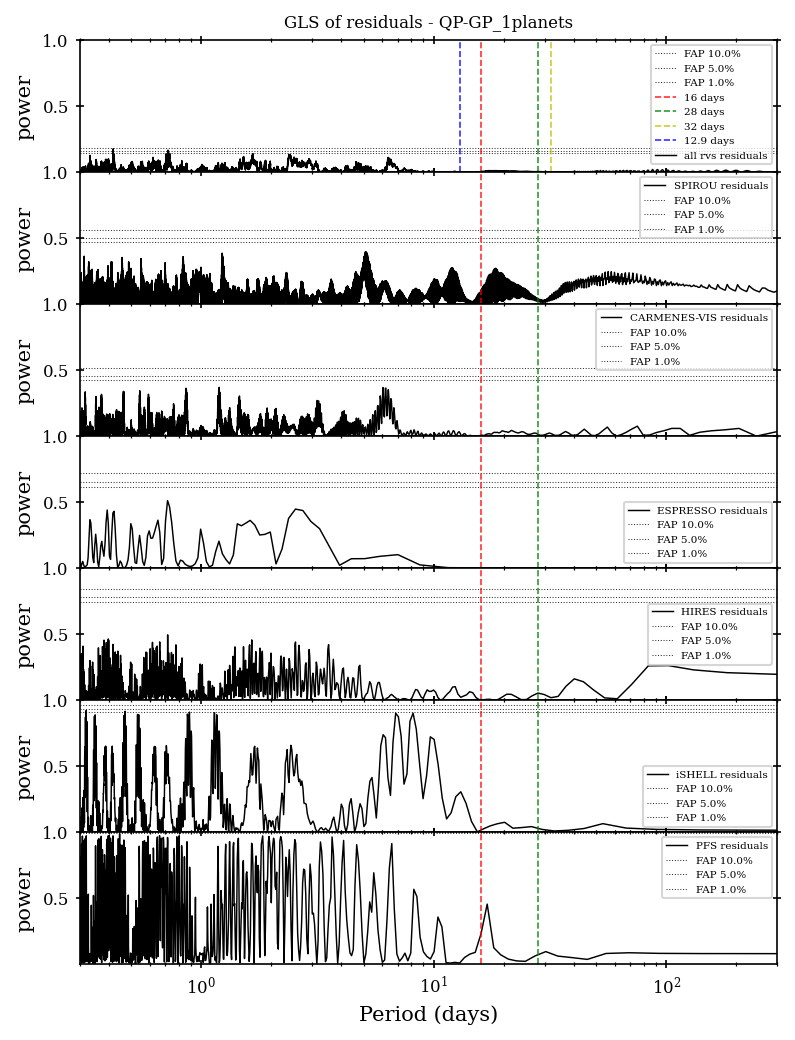

In [105]:
fig, ax = plt.subplots(len(np.unique(rv_inst))+1, 1, figsize=(6, len(rv_inst_names)+1), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.0)
lg_all = ls(x_rv, residuals, yerr_rv)
fr_all, pw_all = lg_all.autopower(minimum_frequency=1/300, maximum_frequency=max_freq, samples_per_peak=sppk)
fp = lg_all.false_alarm_level(probabilities)
ax[0].axhline(y=fp[0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                  , label=f'FAP {probabilities[0]*100}%', zorder=0)
ax[0].axhline(y=fp[1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[1]*100}%', zorder=0)
ax[0].axhline(y=fp[2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[2]*100}%', zorder=0)
ax[0].axvline(16, color='r', linestyle='--', linewidth=0.8, alpha=0.8, label='16 days')
ax[0].axvline(28, color='g', linestyle='--', linewidth=0.8, alpha=0.8, label='28 days')
ax[0].axvline(32, color='y', linestyle='--', linewidth=0.8, alpha=0.8, label='32 days')
ax[0].axvline(12.9, color='b', linestyle='--', linewidth=0.8, alpha=0.8, label='12.9 days')
ax[0].plot(1/fr_all, pw_all, color='k', linewidth=0.7, label='all rvs residuals')
ax[0].set_ylabel('power')
ax[0].set_xlim(0.3, 300)
ax[0].set_ylim(0,0.5)
ax[0].set_xscale('log')
ax[0].legend(fontsize=5)
if circular:
    ax[0].set_title(f'GLS of residuals - {version_names[version]}_{n_planets}planets_circular')
else:
    ax[0].set_title(f'GLS of residuals - {version_names[version]}_{n_planets}planets')
ax[0].set_yticks([0.5, 1.0])
for i, name in enumerate(rv_inst_names_used):
    m = rv_inst_id == i
    lg = ls(x_rv[m], residuals[m], yerr_rv[m])
    fr, pw = lg.autopower(minimum_frequency=1/300, maximum_frequency=max_freq)
    fp = lg.false_alarm_level(probabilities)
    ax[i+1].plot(1/fr, pw, color='k', linewidth=0.7, label=name+' residuals')
    ax[i+1].axhline(y=fp[0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                  , label=f'FAP {probabilities[0]*100}%', zorder=0)
    ax[i+1].axhline(y=fp[1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[1]*100}%', zorder=0)
    ax[i+1].axhline(y=fp[2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[2]*100}%', zorder=0)
    ax[i+1].set_ylabel('power')
    ax[i+1].legend(fontsize=5)
    ax[i+1].axvline(16., color='r', linestyle='--', linewidth=0.8, alpha=0.8, label='16 days')
    ax[i+1].axvline(28, color='g', linestyle='--', linewidth=0.8, alpha=0.8, label='28 days')
ax[i+1].set_xlabel('Period (days)')
if circular:
    plt.savefig(f'./plots/toi442/rv_residuals_gls_v{version}_{version_names[version]}_{n_planets}planets_circular.png', dpi=200, facecolor='w', bbox_inches='tight')
else:
    plt.savefig(f'./plots/toi442/rv_residuals_gls_v{version}_{version_names[version]}_{n_planets}planets.png', dpi=200, facecolor='w', bbox_inches='tight')
plt.show()

/home/juanserrano/anaconda3/envs/exoplanet3/lib/python3.11/site-packages/astropy/timeseries/periodograms/lombscargle/_statistics.py:140: RuntimeWarning: invalid value encountered in power
  return (1 - z) ** (0.5 * Nk)


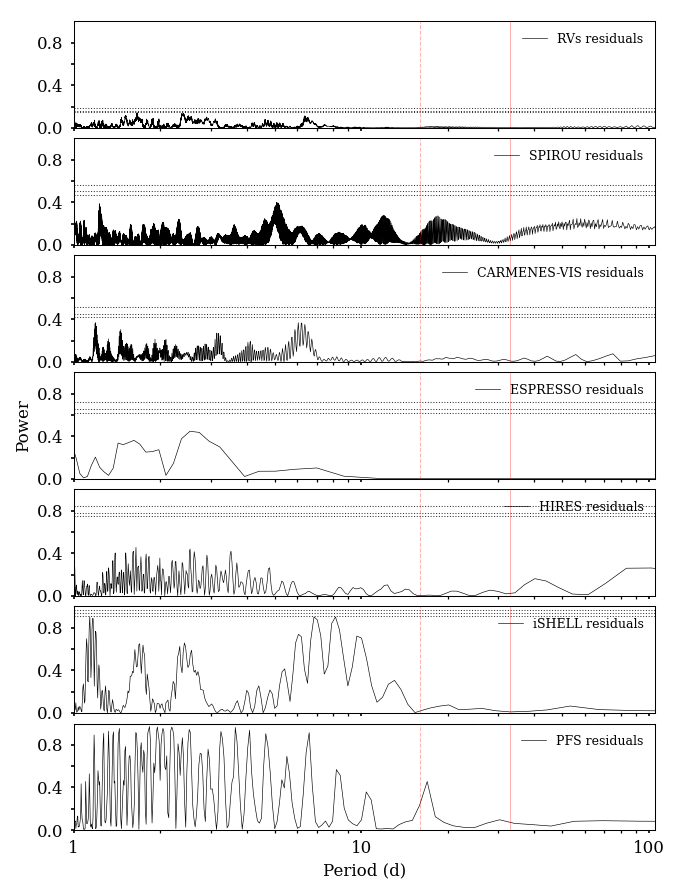

In [106]:
fig, ax = plt.subplots(len(np.unique(rv_inst))+1, 1, figsize=(5, len(rv_inst_names_used)+1), sharex=True,sharey=True, dpi=150)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
lg_all = ls(x_rv, residuals, yerr_rv)
fr_all, pw_all = lg_all.autopower(minimum_frequency=1/300, maximum_frequency=max_freq, samples_per_peak=sppk)
fp = lg_all.false_alarm_level(probabilities)

ax[0].axhline(y=fp[0], color='k', linestyle=':', linewidth=0.5, alpha=0.8, zorder=0)
ax[0].axhline(y=fp[1], color='k', linestyle=':', linewidth=0.5, alpha=0.8, zorder=0)
ax[0].axhline(y=fp[2], color='k', linestyle=':', linewidth=0.5, alpha=0.8, zorder=0)
ax[0].axvline(16, color='r', linestyle='--', linewidth=0.5, alpha=0.3)
ax[0].axvline(33, color='r', linestyle='-', linewidth=0.5, alpha=0.3)
ax[0].plot(1/fr_all, pw_all, color='k', linewidth=0.3, label='RVs residuals')
ax[0].set_xlim(1, 105)
ax[0].set_ylim(0, 1)
ax[0].set_xscale('log')
ax[0].legend(frameon=False, markerscale=0, loc='upper right', fontsize=6, edgecolor='k', fancybox=False)
ax[0].set_yticks([0.0, 0.2, 0.4, 0.6, 0.8], labels=['0.0', '', '0.4', '', '0.8'], size=8)
ax[0].set_xticks([1, 10, 100], labels=['1', '10', '100'], size=8)
ax[0].tick_params(which='both', top=False, right=False, direction='out', length=1.5)
for axis in ['top','bottom','left','right']:
    ax[0].spines[axis].set_linewidth(0.5)
for i, name in enumerate(rv_inst_names_used):
    m = rv_inst_id == i
    lg = ls(x_rv[m], residuals[m], yerr_rv[m])
    fr, pw = lg.autopower(minimum_frequency=1/300, maximum_frequency=max_freq)
    fp = lg.false_alarm_level(probabilities)
    ax[i+1].plot(1/fr, pw, color='k', linewidth=0.3, label=name+' residuals')
    ax[i+1].axhline(y=fp[0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                , zorder=0)
    ax[i+1].axhline(y=fp[1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , zorder=0)
    ax[i+1].axhline(y=fp[2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , zorder=0)
    ax[i+1].legend(frameon=False, markerscale=0, loc='upper right', fontsize=6, edgecolor='k', fancybox=False)
    ax[i+1].axvline(16, color='r', linestyle='--', linewidth=0.5, alpha=0.3)
    ax[i+1].axvline(33, color='r', linestyle='-', linewidth=0.5, alpha=0.3)
    ax[i+1].set_yticks([0.0, 0.2, 0.4, 0.6, 0.8], labels=['0.0', '', '0.4', '', '0.8'], size=8)
    ax[i+1].set_xticks([1, 10, 100], labels=['1', '10', '100'], size=8)
    ax[i+1].tick_params(which='both', top=False, right=False, direction='out', length=1.5)
    for axis in ['top','bottom','left','right']:
        ax[i+1].spines[axis].set_linewidth(0.5)
bigax = fig.add_subplot(111, frameon=False)
bigax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
bigax.set_xlabel("Period (d)", labelpad=2, size=8)
bigax.set_ylabel("Power", labelpad=2, size=8)
plt.savefig(f'./plots/paper/rvgls_442_1planet.pdf', facecolor='w', bbox_inches='tight', format='pdf')

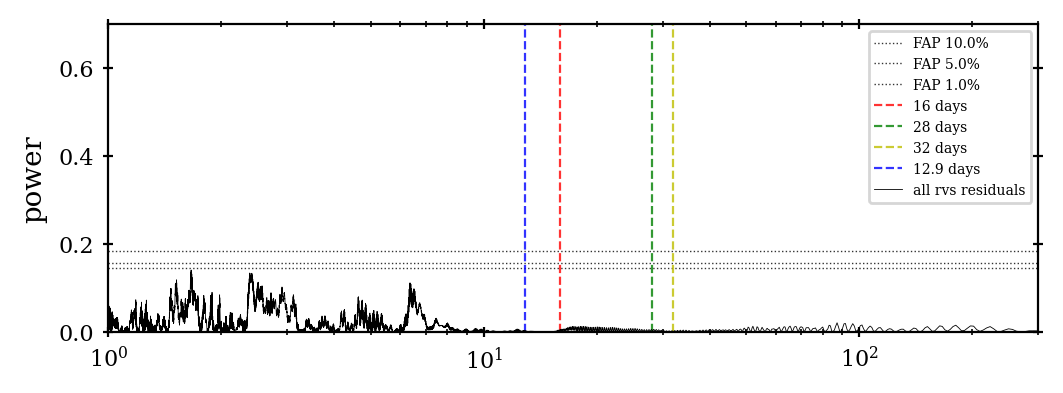

In [107]:
fig, ax = plt.subplots(figsize=(6, 2), dpi=200)
lg_all = ls(x_rv, residuals, yerr_rv)
fr_all, pw_all = lg_all.autopower(minimum_frequency=1/300, maximum_frequency=max_freq, samples_per_peak=sppk)
fp = lg_all.false_alarm_level(probabilities)
ax.axhline(y=fp[0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                  , label=f'FAP {probabilities[0]*100}%', zorder=0)
ax.axhline(y=fp[1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[1]*100}%', zorder=0)
ax.axhline(y=fp[2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[2]*100}%', zorder=0)
ax.axvline(16, color='r', linestyle='--', linewidth=0.8, alpha=0.8, label='16 days')
ax.axvline(28, color='g', linestyle='--', linewidth=0.8, alpha=0.8, label='28 days')
ax.axvline(32, color='y', linestyle='--', linewidth=0.8, alpha=0.8, label='32 days')
ax.axvline(12.9, color='b', linestyle='--', linewidth=0.8, alpha=0.8, label='12.9 days')
ax.plot(1/fr_all, pw_all, color='k', linewidth=0.3, label='all rvs residuals')
ax.set_ylabel('power')
ax.set_xlim(1, 300)
ax.set_xscale('log')
ax.set_ylim(0, 0.7)
ax.legend(fontsize=5)
plt.savefig(f'./plots/toi442/rv_ALL_residuals_gls_v{version}_{version_names[version]}_{n_planets}planets.png', dpi=200, facecolor='w', bbox_inches='tight')

In [ ]:
compute_aliases(period_tess.nominal_value, n_list=[1, 2])

[(1, 1, 0.8020600325001591),
 (1, -1, 1.3276500466835788),
 (2, 1, 0.44507953011276186),
 (2, -1, 0.5703821536984076)]

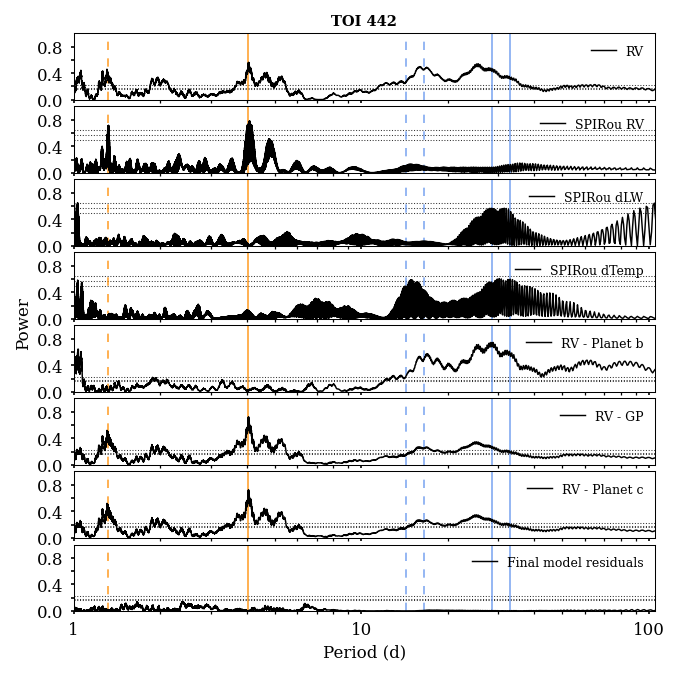

In [113]:
if version == 4:
    series = ['all rvs', 'spirou rvs', 'spirou dlw','spirou dtemp', 'kb+d residuals', 
              'qpgp+d residuals', 'kc+d residuals', 'final model residuals']
    # series = ['all rvs', 'spirou rvs', 'spirou dlw', 'keplerian residuals', '2 keplerian residuals', 'residuals']
    # series = ['all rvs', 'spirou rvs', 'spirou dlw', 'keplerian residuals', 'gp residuals', 'residuals']

    # np.savez(f'./data/vrad_2_.npz', vrad_2_pred=vrad_2_pred_, vrad_2_=vrad_2_)
    # npzfile1 = np.load('./data/vrad_2_.npz',)
    # vrad_2_ = npzfile1['vrad_2_']
    # vrad_2_pred_ = npzfile1['vrad_2_pred']

    np.savez(f'./data/residuals_toi442_v4planetb.npz', residuals=planet_residuals)
    npzfile2 = np.load('./data/residuals_toi442_v4planetb.npz')
    res1 = npzfile2['residuals']

    np.savez(f'./data/residuals_toi442_v4gp.npz', residuals=gp_residuals)
    npzfile3 = np.load('./data/residuals_toi442_v4gp.npz',)
    res2 = npzfile3['residuals']

    # np.savez(f'./data/residuals_drift2planets_plus_planetb.npz', residuals=residuals+vrad_[1])
    # npzfile4 = np.load('./data/residuals_drift2planets_plus_planetb.npz',)
    # res3 = npzfile4['residuals']

    # np.savez(f'./data/residuals_v3_planetc.npz', residuals_vrad_2=residuals_c)
    npzfile5 = np.load('./data/residuals_toi442_v4gp.npz')
    res4 = npzfile5['residuals']
    # res4 = npzfile5['residuals_vrad_2']

    lg = [ls(xrv, yrv, yerrrv),
        ls(spirou.rjd, spirou.vrad, spirou.svrad),
        ls(spirou.rjd, spirou.d2v, spirou.sd2v),
        ls(spirou.rjd, spirou['DTEMP4000'], spirou['sDTEMP4000']),
        ls(xrv, res1, yerrrv),
        ls(xrv, res2, yerrrv),
        ls(xrv, res4, yerrrv),
        ls(xrv, residuals, yerrrv)]

    min_freq = 0.001
    max_freq = 10
    sppk = 5
    probabilities = [0.05, 0.01, 0.001]
    powerlw = 0.7
    vlineslw = 0.7
    vlinesalpha = 0.8
    vlinescolor1 = 'darkorange'
    vlinescolor2 = 'cornflowerblue'

    freq = {}
    power = {}
    fap = {}

    for n, name in enumerate(series):
        freq[name], power[name] = lg[n].autopower(minimum_frequency=min_freq, maximum_frequency=max_freq, samples_per_peak=sppk)
        fap[name] = lg[n].false_alarm_level(probabilities)

    fig, ax = plt.subplots(len(series), 1, sharex=True, figsize=(5,5), dpi=150)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    names_ = ['RV', 'SPIRou RV', 'SPIRou dLW', 'SPIRou dTemp', 'RV - Planet b', 'RV - GP', 'RV - Planet c', 'Final model residuals']
    # names_ = ['RVs', 'SPIRou RV', 'SPIRou dLW', 'RV - Keplerian', 'RV - 2 Keplerian', 'Residuals']
    # names_ = ['RVs', 'SPIRou RV', 'SPIRou dLW', 'RV - Keplerian', 'RV - GP', 'Residuals']
    for i, name in enumerate(series):
        ax[i].axvline(x=period_tess.nominal_value, color=vlinescolor1, linestyle='-', linewidth=vlinesalpha, alpha=vlinesalpha)
        ax[i].axvline(x=28.6, color=vlinescolor2, linestyle='-', linewidth=vlinesalpha, alpha=vlinesalpha)
        ax[i].axvline(x=28.6/2, color=vlinescolor2, linestyle=(0,(5, 5)), linewidth=vlinesalpha, alpha=vlinesalpha)
        ax[i].axvline(x=33, color=vlinescolor2, linestyle='-', linewidth=vlinesalpha, alpha=vlinesalpha)
        ax[i].axvline(x=33/2, color=vlinescolor2, linestyle=(0,(5, 5)), linewidth=vlinesalpha, alpha=vlinesalpha)
        ax[i].axvline(x=1.32, color=vlinescolor1, linestyle=(0,(5, 5)), linewidth=vlinesalpha, alpha=vlinesalpha)
        ax[i].plot(1/freq[series[i]], power[series[i]], color='k', linewidth=powerlw, label=names_[i])
        ax[i].set_ylabel(series[i])
        ax[i].set_ylim(0, 1)
        ax[i].set_xlim(1, 105)
        ax[i].set_xscale('log')
        ax[i].set_xlabel('')
        ax[i].set_ylabel('')
        ax[i].legend(frameon=False, markerscale=0, loc='upper right', fontsize=6, edgecolor='k', fancybox=False)
        ax[i].set_yticks([0.0, 0.2, 0.4, 0.6, 0.8], labels=['0.0', '', '0.4', '', '0.8'], size=8)
        ax[i].set_xticks([1, 10, 100], labels=['1', '10', '100'], size=8)
        ax[i].tick_params(which='both', top=False, right=False, direction='out', length=1.5)
        ax[i].axhline(y=fap[name][0], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[0]*100}%', zorder=0)
        ax[i].axhline(y=fap[name][1], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[1]*100}%', zorder=0)
        ax[i].axhline(y=fap[name][2], color='k', linestyle=':', linewidth=0.5, alpha=0.8
                    , label=f'FAP {probabilities[2]*100}%', zorder=0)
        for axis in ['top','bottom','left','right']:
            ax[i].spines[axis].set_linewidth(0.5)
    bigax = fig.add_subplot(111, frameon=False)
    bigax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    bigax.set_xlabel("Period (d)", labelpad=2, size=8)
    bigax.set_ylabel("Power", labelpad=2, size=8)
    # add title
    bigax.set_title("TOI 442", size=7, pad=4, fontweight='semibold')
    plt.savefig(f'./plots/paper/rvgls_442_paper.pdf', facecolor='w', bbox_inches='tight', format='pdf')

In [ ]:
# peak in the all_rvs residuals
fr_all[pw_all.argmax()], 1/fr_all[pw_all.argmax()]

In [ ]:
# estimated semi-amplitude
K_est2 = xo.estimate_semi_amplitude(1/fr_all[pw_all.argmax()], x_rv, residuals)
print(K_est2, "m/s")

### LC fit

In [ ]:
if version == 5:
        fig, ax = plt.subplots(2, 1, figsize=(3, 3), dpi=150, sharex=True, height_ratios=[1, 0.5])
        fig.subplots_adjust(hspace=0.0)

        folded_lc = (x - t0_ + 0.5 * period) % period - 0.5 * period
        ins = np.argsort(folded_lc)
        ax[0].errorbar(folded_lc[ins]*24, y[ins], yerr=yerr[ins], fmt='o', color='gray', elinewidth=0.1, ecolor='gray', 
                        markersize=1, markeredgewidth=0.1, alpha=0.9)
        ax[0].plot(phase_lc*24, lc_phase[1], color="k", lw=1, zorder=1000)
        art = ax[0].fill_between(phase_lc*24, lc_phase[0], lc_phase[2], color="k", zorder=1001, alpha=0.5) 
        art.set_edgecolor("none")
        ax[0].set_ylabel(u'$\Delta$ Flux (‰)', fontsize=7, labelpad=1)
        ax[1].set_ylabel(u'Residuals (‰)', fontsize=7, labelpad=1)
        ax[1].set_xlabel('Time since mid-transit (h)', fontsize=7, labelpad=0.5)
        ax[0].set_xlim(-2.1,2.1)
        ax[0].set_ylim(-12,8)
        ax[1].set_ylim(-5,5)
        ax[0].set_yticks([-10,-8,-6,-4,-2,0,2,4,6])
        ax[0].set_yticklabels(['','-8','','-4','','0','','4',''])
        ax[1].set_yticks([-4,-2,0,2,4])
        ax[1].set_yticklabels(['-4','','0','','4'])
        ax[0].set_xlabel("Time (h)", fontsize=12, labelpad=0.5)
        ax[0].text(0.02, 0.96, 'TOI-442', fontsize=6, color='k',
                ha='left', va='top', transform=ax[0].transAxes, 
                bbox=dict(boxstyle="square", alpha=0.0, ec=(0., 0., 0.), fc=(1., 1., 1.)))
        for i in range(2):
                ax[i].tick_params(direction='inout', length=1.5, labelsize=7, pad=1.6)
                ax[i].set_xticks([-2.0,-1.5,-1.0,-0.5,0,0.5,1.0,1.5,2.0])
                ax[i].set_xticklabels(['-2','','1','','0','','1','','2'])
        for axis in ['top','bottom','left','right']:
                ax[i].spines[axis].set_linewidth(0.5)
        ax[1].errorbar(folded_lc[ins]*24, y[ins] - lc_model[1][ins], yerr=yerr[ins], fmt='o', color='gray', elinewidth=0.1, ecolor='gray', 
                        markersize=1, markeredgewidth=0.1, alpha=0.9)
        ax[1].axhline(y=0, ls='--', color='k', linewidth=0.8, alpha=1, zorder=2000)
        plt.savefig(f'./plots/toi442/lcfit_442.png', dpi=300, facecolor='w', bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots(1, figsize=(5, 3), dpi=150)
fig.subplots_adjust(hspace=0.)

lc_perc = np.percentile(flat_samps["lc_phase"], [16,50,84], axis=-1)
folded_lc = (x - t0_ + 0.5 * period) % period - 0.5 * period
ins = np.argsort(folded_lc)
ax.scatter(folded_lc[ins]*24, y[ins], s=1, color='k')
ax.plot(phase_lc*24, lc_perc[1], color='red', lw=0.5)
art = ax.fill_between(phase_lc*24, lc_perc[0], lc_perc[2], color="#FF7F00", zorder=2) 
art.set_edgecolor("none")
ax.set_ylabel(u'$\Delta$ Flux (‰)', fontsize=12, labelpad=0.5)
ax.set_title(f"LC model - {version_names[version]}", fontsize=14)
ax.set_ylabel(u'$\Delta$ Flux (‰)', fontsize=12, labelpad=0.5)
ax.set_xlim(-3.5,3.5)
ax.set_xlabel("Time (h)", fontsize=12, labelpad=0.5)
if not circular:
    plt.savefig(f'./plots/toi442/lc_fits_{star_name}_v{version}_{n_planets}planets.png', dpi=200, facecolor='w', bbox_inches='tight')
else:
    plt.savefig(f'./plots/toi442/lc_fits_{star_name}_v{version}_{n_planets}planets_circular.png', dpi=200, facecolor='w', bbox_inches='tight')


## Model comparison

Use LOO-CV-PSIS implemented in Arviz

In [ ]:
from utils import loo_cv

for ver, name in enumerate(version_names):
    if ver == version:
        metrics = {}
        # lets try pointwise=False , da exactamente lo mismo
        if ver < 2:
            trace = az.from_netcdf(f'./saves/toi442/trace.global{star_name}_v{ver}_{name}_{n_planets}planets.save')
            flat_samps = trace.posterior.stack(sample=("chain", "draw"))
            rv_model_ = flat_samps['rv_model'].median(axis=-1).values
            mean_ = flat_samps['mean'].median(axis=-1)
            model_prediction = rv_model_ + mean_
            rms = np.sqrt(np.mean((y_rv - model_prediction)**2))
            loo = az.loo(trace, var_name='obs')
            waic = az.waic(trace, var_name='obs')
            metrics['rms'] = rms
            metrics['elpd_loo'] = loo.elpd_loo
            metrics['p_loo'] = loo.p_loo
            metrics['loo_se'] = loo.se
            metrics['elpd_waic'] = waic.elpd_waic
            metrics['p_waic'] = waic.p_waic
            metrics['waic_se'] = waic.se
            with open(f'./results/toi442/model_metrics_{star_name}_v{ver}_{version_names[ver]}_{n_planets}planets.pkl', 'wb') as f:
                pickle.dump(metrics, f)
            with open(f'./results/toi442/model_metrics_{star_name}_v{ver}_{version_names[ver]}_{n_planets}planets.txt', 'w') as f1:
                f1.write(f'elpd_loo = {metrics["elpd_loo"]:.6f}\n')
                f1.write(f'p_loo = {metrics["p_loo"]:.6f}\n')
                f1.write(f'loo_se = {metrics["loo_se"]:.6f}\n')
                f1.write(f'elpd_waic = {metrics["elpd_waic"]:.6f}\n')
                f1.write(f'p_waic = {metrics["p_waic"]:.6f}\n')
                f1.write(f'waic_se = {metrics["waic_se"]:.6f}\n')
                f1.write(f'rms = {metrics["rms"]:.6f}\n')
            #print(loo)
            #print(waic)
            print(f'{version_names[ver]} {n_planets} planets, LOO: {loo.elpd_loo:.3f} +/- {loo.se:.3f}')
        else:
            trace = az.from_netcdf(f'./saves/toi442/trace.global{star_name}_v{ver}_{name}_{n_planets}planets.save')
            flat_samps = trace.posterior.stack(sample=("chain", "draw"))
            rv_model_ = flat_samps['rv_model'].median(axis=-1).values
            mean_ = flat_samps['mean'].median(axis=-1)
            rv_prediction = rv_model_ + mean_
            gp_rv_pred_opt = np.percentile(flat_samps["gp_rv_pred_opt"].values, [16,50,84], axis=-1)
            gp_rv_pred_nir = np.percentile(flat_samps["gp_rv_pred_nir"].values, [16,50,84], axis=-1)
            gp_prediction = np.empty(rv_model.shape, dtype=gp_rv_pred_opt.dtype)
            gp_prediction[:, rv_band_id == 1] = gp_rv_pred_opt
            gp_prediction[:, rv_band_id == 0] = gp_rv_pred_nir
            rms = np.sqrt(np.mean((y_rv - (rv_prediction+gp_prediction[1]))**2))
            metrics['rms'] = rms
            diag_ = flat_samps.data_vars["diag"].median(axis=-1).values
            sigma_gp_ = flat_samps.data_vars["sigma_gp"].median(axis=-1).values
            gp_period_ = flat_samps.data_vars["gp_period"].median(axis=-1).values
            if "SHO" in version_names[ver]:
                tau_ = flat_samps.data_vars["tau"].median(axis=-1).values
                loo_0 = loo_cv(x=x_rv[rv_band_id == 0], y=y_rv[rv_band_id == 0]-rv_prediction[rv_band_id == 0], diag=diag_[rv_band_id == 0], sigma=sigma_gp_[0], 
                                term="sho", rho=gp_period_, tau=tau_[0],  verbose=False)
                loo_1 = loo_cv(x=x_rv[rv_band_id == 1], y=y_rv[rv_band_id == 1]-rv_prediction[rv_band_id == 1], diag=diag_[rv_band_id == 1], sigma=sigma_gp_[1] , 
                                term="sho", rho=gp_period_, tau=tau_[1], verbose=False)
                metrics['elpd_loo'] = loo_0[0] + loo_1[0]
                metrics['loo_se'] = np.sqrt(loo_0[1]**2 + loo_1[1]**2)
                print(f'{version_names[ver]}, LOO: {metrics["elpd_loo"]:.3f} +/- {metrics["loo_se"]:.3f}')
            elif "QP" in name:
                Q0_ = np.exp(flat_samps.data_vars["log_Q0"].median(axis=-1).values)
                dQ_ = np.exp(flat_samps.data_vars["log_dQ"].median(axis=-1).values)
                f_ = flat_samps.data_vars["f"].median(axis=-1).values
                loo_0 = loo_cv(x=x_rv[rv_band_id == 0], y=y_rv[rv_band_id == 0]-rv_prediction[rv_band_id == 0], diag=diag_[rv_band_id == 0], sigma=sigma_gp_[0], 
                                term="rotation", period=gp_period_, Q0=Q0_[0], dQ=dQ_[0], f=f_[0], verbose=False)
                loo_1 = loo_cv(x=x_rv[rv_band_id == 1], y=y_rv[rv_band_id == 1]-rv_prediction[rv_band_id == 1], diag=diag_[rv_band_id == 1], sigma=sigma_gp_[1] , 
                                term="rotation", period=gp_period_, Q0=Q0_[1], dQ=dQ_[1], f=f_[1], verbose=False)
                print(f'{version_names[ver]}, LOO: {loo_0[0] + loo_1[0]:.3f} +/- {np.sqrt(loo_0[1]**2 + loo_1[1]**2):.3f}')
                metrics['elpd_loo'] = loo_0[0] + loo_1[0]
                metrics['loo_se'] = np.sqrt(loo_0[1]**2 + loo_1[1]**2)
            with open(f'./results/toi442/model_metrics_{star_name}_v{ver}_{version_names[ver]}_{n_planets}planets.pkl', 'wb') as f:
                pickle.dump(metrics, f)
            with open(f'./results/toi442/model_metrics_{star_name}_v{ver}_{version_names[ver]}_{n_planets}planets.txt', 'w') as f1:
                f1.write(f'elpd_loo = {metrics["elpd_loo"]:.6f}\n')
                f1.write(f'loo_se = {metrics["loo_se"]:.6f}\n')
                f1.write(f'rms = {metrics["rms"]:.6f}\n')

        del trace, flat_samps
        f.close()
        f1.close()

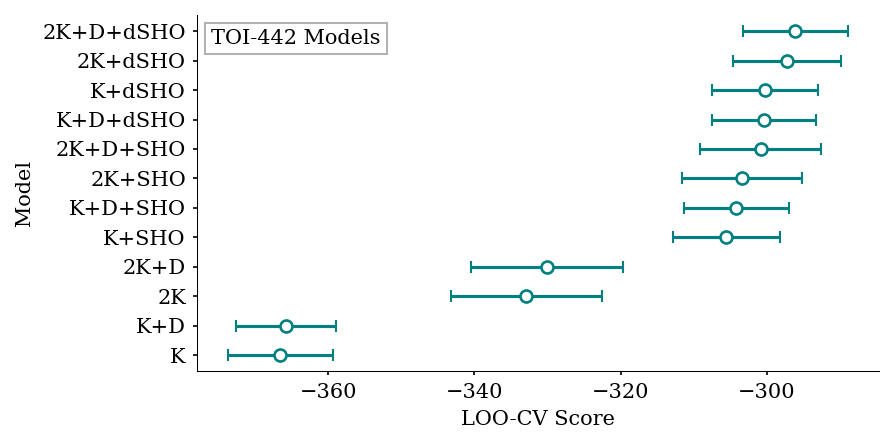

In [104]:
loo_scores = []
loo_se = []
# map_models = {"0_1":"K", "0_2":"2K", "1_1":"K+D", "1_2":"2K+D", "2_1":"K+SHO-GP", "2_2":"2K+SHO-GP",
#               "3_1":"K+D+SHO-GP", "3_2":"2K+D+SHO-GP", "4_1":"K+QP-GP", "5_1":"K+D+QP-GP"}
map_models = {"0_1":"K", "0_2":"2K", "1_1":"K+D", "1_2":"2K+D", "2_1":"K+SHO", "2_2":"2K+SHO", 
              "3_1":"K+D+SHO", "3_2":"2K+D+SHO", "4_1":"K+dSHO", "4_2":"2K+dSHO", "5_1":"K+D+dSHO", "5_2":"2K+D+dSHO"}
for model, name in map_models.items():
    with open(f'./results/toi442/model_metrics_{star_name}_v{int(model[0])}_{version_names[int(model[0])]}_{int(model[2])}planets.pkl', 'rb') as f:
        metrics = pickle.load(f)
        loo_scores.append(metrics['elpd_loo'])
        loo_se.append(metrics['loo_se'])
        f.close()

loo_scores = np.array(loo_scores)
loo_se = np.array(loo_se)
order = np.argsort(loo_scores)

loo_scores = loo_scores[order]
loo_se = loo_se[order]
names = np.array(list(map_models.values()))[order]

y_positions = np.arange(len(names))
max_loo_score = np.max(loo_scores)

fig, ax = plt.subplots(figsize=(6, 3), dpi=150)
color='teal'
ax.errorbar(loo_scores, y_positions, xerr=loo_se, fmt='o', capsize=3, markerfacecolor='teal', 
             markeredgecolor=color, color=color, label="LOO-CV Scores", alpha=1.0)
ax.scatter(loo_scores, y_positions, color='white', s=30, edgecolor=color, zorder=3)
# ax.axvline(max_loo_score, color='gray', linestyle='--', alpha=0.7, label="Highest Score")
ax.set_yticks(y_positions, names)
for label in ax.get_yticklabels():
    if label.get_text() == 'K+D+QP-GP':
        label.set_fontweight('bold')
ax.set_xlabel("LOO-CV Score")
ax.set_ylabel("Model")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
ax.tick_params(axis='x', top=False, labeltop=False, direction='out', size=2, labelsize=10)
ax.tick_params(axis='y', right=False, labelright=False, direction='out', size=2, labelsize=10)
ax.grid(False)
ax.text(0.02, 0.96, 'TOI-442 Models', fontsize=10, color='k',
        ha='left', va='top', transform=ax.transAxes, 
        bbox=dict(boxstyle="square", alpha=0.3, ec=(0., 0., 0.), fc=(1., 1., 1.)))
for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.5)
plt.tight_layout()
# plt.title(f"LOO-CV Model Comparison - {star_name}", fontsize=14)
plt.savefig(f'./plots/toi442/loocv_{star_name}.pdf', bbox_inches='tight', facecolor='w', format='pdf')
plt.show()